# Cognitive Reappraisal Experiment Analysis

This notebook analyzes a task simulating cognitive reappraisal through:
- **Initial Valuation**: Reward learning phase
- **Reappraisal 1**: First revaluation period  
- **Reappraisal 2**: Second revaluation period

**Key Measures:**
- Ratings (1-3): Value estimates at each phase
- Queries (1-2): Decision-making probes
- Response Times: Decision speed

**Hypotheses:**
1. Better reappraisers (high ERQ-Reappraisal) will be more accurate, faster, and rate with precision
2. Worriers (high anxiety) will show opposite pattern
3. ERQ-Reappraisal scores will correlate negatively with worry
4. Worriers will revaluate better in positive-to-negative than negative-to-positive direction

---
# Section 1: Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_ind, ttest_rel, ttest_1samp
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

df = pd.read_csv('experiment_results_v3_export.csv')

print(f"Original N: {len(df)}")
print(f"Total missing values: {df.isnull().sum().sum()}")

df_clean = df.dropna()

print(f"N after removing missing: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} subjects")

df_clean.to_csv('experiment_results_v3_clean.csv', index=False)

Original N: 151
Total missing values: 0
N after removing missing: 151
Removed: 0 subjects


---
# Section 2: Subject Filtering (Quality Control)

ENHANCED SUBJECT FILTERING (WITH R1 LOGIC CHECK)

Original Subject Count: 151

--------------------------------------------------------------------------------
FILTER 1: Zig-Zag Inconsistency
--------------------------------------------------------------------------------

Zig-Zag Threshold: 2.0
Subjects with zig-zag score >= 2.0: 4
Subject IDs: ['576311d7151e5d000889e2e7', '5d542c3a5af5900019bc80c4', '667987c18f34110073ae20b7', '69306d791138d98b65f1ba40']
  576311d7151e5d000889e2e7: Zig-Zag Score = 2.000
  5d542c3a5af5900019bc80c4: Zig-Zag Score = 2.000
  667987c18f34110073ae20b7: Zig-Zag Score = 2.000
  69306d791138d98b65f1ba40: Zig-Zag Score = 2.000

--------------------------------------------------------------------------------
FILTER 2: Always Chose Feather Gamble
--------------------------------------------------------------------------------
  69136dffc23976053d4a4166: ALWAYS chose Feather gamble (8/8 trials)
  59d141f5e241c700013a9bb0: ALWAYS chose Feather gamble (8/8 trials)


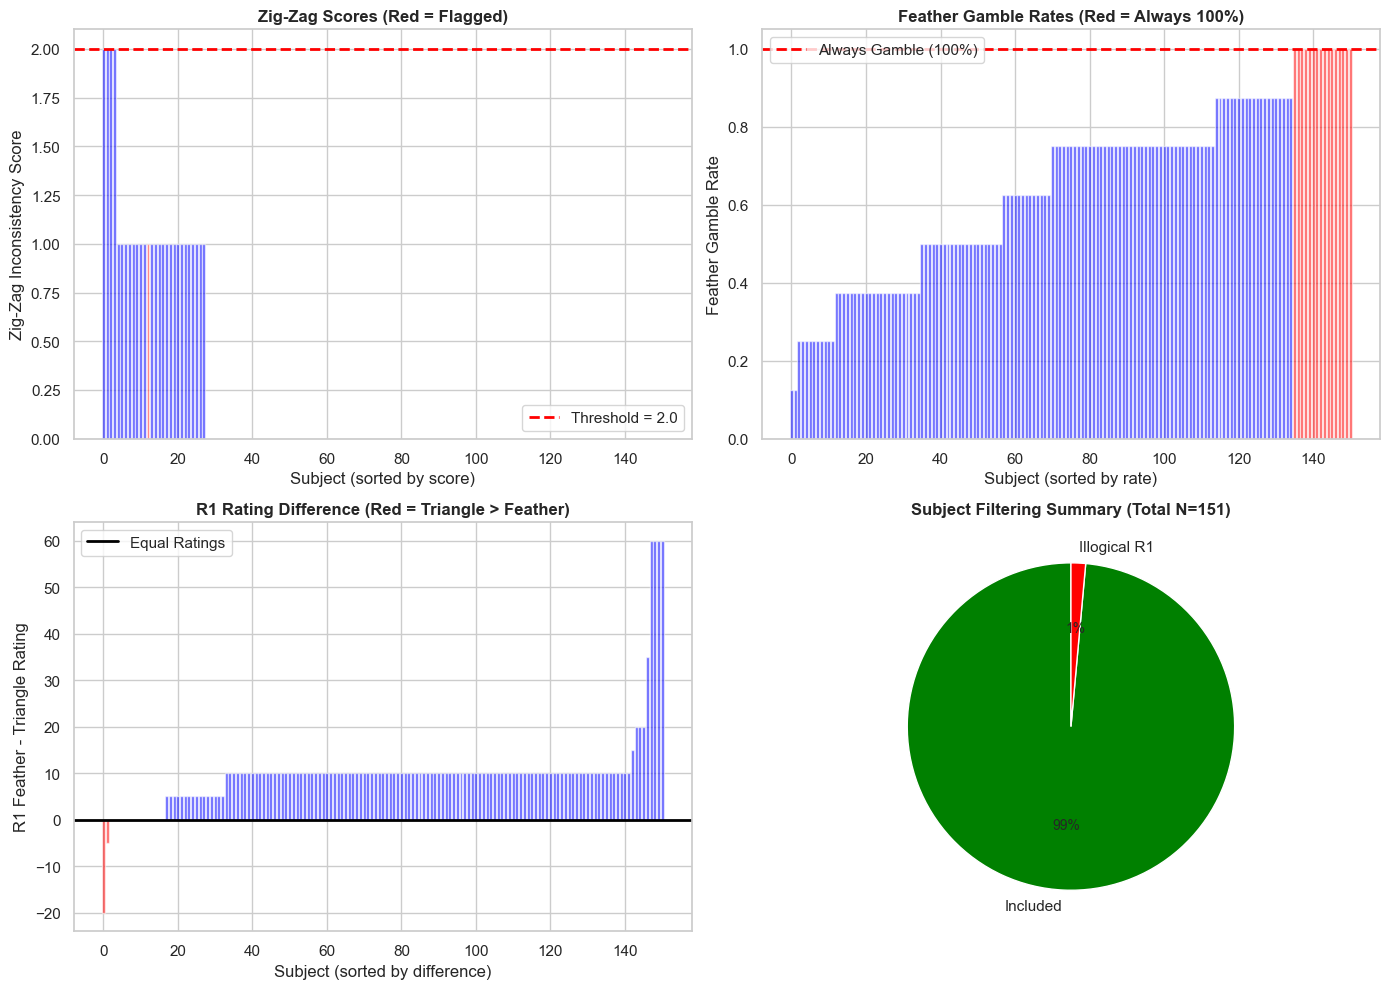


FILTERING COMPLETE!


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("ENHANCED SUBJECT FILTERING (WITH R1 LOGIC CHECK)")
print("="*80)

df = pd.read_csv('experiment_results_v3_clean.csv')
df['subject_id'] = df['prolific_id']

print(f"\nOriginal Subject Count: {len(df)}")

# ============================================================================
# FILTER 1: ZIG-ZAG INCONSISTENCY
# ============================================================================
print("\n" + "-"*80)
print("FILTER 1: Zig-Zag Inconsistency")
print("-"*80)

long_data = []
for idx, row in df.iterrows():
    subj_id = row['subject_id']
    for q_num in [1, 2]:
        for t in range(1, 21):
            prefix = f"Query_{q_num}_T{t}"
            state_col = f"{prefix}_State"
            offer_col = f"{prefix}_FixedOffer"
            choice_col = f"{prefix}_Choice"
            
            if state_col not in row or pd.isna(row[state_col]): 
                continue
            
            chose_fixed = 1 if row[choice_col] == 0 else 0
            
            long_data.append({
                'subject_id': subj_id,
                'Query': f"Query {q_num}",
                'State': row[state_col],
                'FixedOffer': row[offer_col],
                'Choice': row[choice_col],
                'ChoseFixed': chose_fixed
            })

df_long = pd.DataFrame(long_data)

def calculate_inconsistency(subject_df):
    total_violation = 0
    for _, group in subject_df.groupby(['Query', 'State']):
        curve = group.groupby('FixedOffer')['ChoseFixed'].mean().sort_index()
        probs = curve.values
        for i in range(len(probs) - 1):
            if probs[i] > probs[i+1]:
                total_violation += (probs[i] - probs[i+1])
    return total_violation

zigzag_scores = df_long.groupby('subject_id', group_keys=False).apply(calculate_inconsistency)

zigzag_threshold = 2.0
zigzag_bad_subjects = zigzag_scores[zigzag_scores >= zigzag_threshold].index.tolist()

print(f"\nZig-Zag Threshold: {zigzag_threshold}")
print(f"Subjects with zig-zag score >= {zigzag_threshold}: {len(zigzag_bad_subjects)}")
if len(zigzag_bad_subjects) > 0:
    print(f"Subject IDs: {zigzag_bad_subjects}")
    for subj in zigzag_bad_subjects:
        print(f"  {subj}: Zig-Zag Score = {zigzag_scores[subj]:.3f}")

# ============================================================================
# FILTER 2: ALWAYS CHOSE FEATHER (GAMBLE)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 2: Always Chose Feather Gamble")
print("-"*80)

always_feather_subjects = []
for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    feather_trials = subj_data[subj_data['State'] == 'Feather']
    
    if len(feather_trials) > 0:
        all_chose_gamble = (feather_trials['Choice'] == 1).all()
        if all_chose_gamble:
            always_feather_subjects.append(subj_id)
            n_feather = len(feather_trials)
            print(f"  {subj_id}: ALWAYS chose Feather gamble ({n_feather}/{n_feather} trials)")

print(f"\nSubjects who always chose Feather gamble: {len(always_feather_subjects)}")

# ============================================================================
# FILTER 3: ALWAYS AVOIDED TRIANGLE (GAMBLE)
# ============================================================================
always_avoid_triangle_subjects = []
for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    triangle_trials = subj_data[subj_data['State'] == 'Triangle']
    
    if len(triangle_trials) > 0:
        never_chose_gamble = (triangle_trials['Choice'] == 0).all()
        if never_chose_gamble:
            always_avoid_triangle_subjects.append(subj_id)
            n_triangle = len(triangle_trials)
            print(f"  {subj_id}: ALWAYS avoided Triangle gamble ({n_triangle}/{n_triangle} trials took offer)")

# ============================================================================
# FILTER 4: ILLOGICAL R1 RATINGS (TRIANGLE > FEATHER POST-MF)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 4: Illogical R1 Ratings (Triangle > Feather)")
print("-"*80)

print("\nLogic: After MF learning, Feather should be valued HIGHER than Triangle")
print("  - Feather → positive outcomes (should be rated high)")
print("  - Triangle → negative outcomes (should be rated low)")
print("  - Expected: Rating_1_Feather > Rating_1_Triangle")
print("  - Illogical: Rating_1_Triangle > Rating_1_Feather")

illogical_r1_subjects = []
for idx, row in df.iterrows():
    subj_id = row['subject_id']
    r1_feather = row['Rating_1_Feather_Val']
    r1_triangle = row['Rating_1_Triangle_Val']
    
    if r1_triangle > r1_feather:
        illogical_r1_subjects.append(subj_id)
        print(f"  {subj_id}: R1 Triangle ({r1_triangle}) > R1 Feather ({r1_feather}) - ILLOGICAL")

print(f"\nSubjects with illogical R1 ratings: {len(illogical_r1_subjects)}")

# ============================================================================
# COMBINED FILTERING
# ============================================================================
print("\n" + "="*80)
print("COMBINED FILTERING RESULTS")
print("="*80)

all_bad_subjects = list(set(
    zigzag_bad_subjects +  
    illogical_r1_subjects
))

print(f"\nTotal subjects to remove: {len(all_bad_subjects)}")
print("\nBreakdown:")
print(f"  Zig-zag inconsistent: {len(zigzag_bad_subjects)}")
print(f"  Always chose Feather: {len(always_feather_subjects)}")
print(f"  Always avoided Triangle: {len(always_avoid_triangle_subjects)}")
print(f"  Illogical R1 ratings: {len(illogical_r1_subjects)}")

zigzag_set = set(zigzag_bad_subjects)
feather_set = set(always_feather_subjects)
triangle_set = set(always_avoid_triangle_subjects)
illogical_set = set(illogical_r1_subjects)

df_filtered = df[~df['subject_id'].isin(all_bad_subjects)].copy()

# Knowledge check filter
if 'Knowledge_Check_Accuracy' in df_filtered.columns:
    n_before = len(df_filtered)
    df_filtered = df_filtered[df_filtered['Knowledge_Check_Accuracy'] > 0.25]
    print(f"\nKnowledge check filter: removed {n_before - len(df_filtered)} additional subjects")

print(f"\n" + "="*80)
print(f"FINAL RESULTS:")
print(f"  Original N: {len(df)}")
print(f"  Removed: {len(df) - len(df_filtered)}")
print(f"  Final N: {len(df_filtered)}")
print(f"  Retention rate: {len(df_filtered)/len(df)*100:.1f}%")
print("="*80)

# Save
df_filtered.to_csv('filtered_data.csv', index=False)

# ============================================================================
# VISUALIZATION
# ============================================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Zig-zag scores
ax = axes[0, 0]
zigzag_df = pd.DataFrame({
    'subject_id': zigzag_scores.index,
    'zigzag_score': zigzag_scores.values,
    'excluded': [s in zigzag_bad_subjects for s in zigzag_scores.index]
})
colors = ['red' if exc else 'blue' for exc in zigzag_df['excluded']]
ax.bar(range(len(zigzag_df)), zigzag_df['zigzag_score'].sort_values(ascending=False), color=colors, alpha=0.6)
ax.axhline(zigzag_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {zigzag_threshold}')
ax.set_xlabel('Subject (sorted by score)')
ax.set_ylabel('Zig-Zag Inconsistency Score')
ax.set_title('Zig-Zag Scores (Red = Flagged)', fontweight='bold')
ax.legend()

# Panel B: Feather gamble rates
ax = axes[0, 1]
feather_rates = []
for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    feather_data = subj_data[subj_data['State'] == 'Feather']
    if len(feather_data) > 0:
        feather_rates.append({'subject_id': subj_id, 'rate': feather_data['Choice'].mean()})

feather_rates_df = pd.DataFrame(feather_rates).sort_values('rate')
colors = ['red' if s in always_feather_subjects else 'blue' for s in feather_rates_df['subject_id']]
ax.bar(range(len(feather_rates_df)), feather_rates_df['rate'], color=colors, alpha=0.6)
ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Always Gamble (100%)')
ax.set_xlabel('Subject (sorted by rate)')
ax.set_ylabel('Feather Gamble Rate')
ax.set_title('Feather Gamble Rates (Red = Always 100%)', fontweight='bold')
ax.set_ylim([0, 1.05])
ax.legend()

# Panel C: R1 rating difference
ax = axes[1, 0]
r1_diff = df['Rating_1_Feather_Val'] - df['Rating_1_Triangle_Val']
r1_diff_sorted = r1_diff.sort_values()
colors = ['red' if diff < 0 else 'blue' for diff in r1_diff_sorted]
ax.bar(range(len(r1_diff_sorted)), r1_diff_sorted, color=colors, alpha=0.6)
ax.axhline(0.0, color='black', linestyle='-', linewidth=2, label='Equal Ratings')
ax.set_xlabel('Subject (sorted by difference)')
ax.set_ylabel('R1 Feather - Triangle Rating')
ax.set_title('R1 Rating Difference (Red = Triangle > Feather)', fontweight='bold')
ax.legend()

# Panel D: Summary
ax = axes[1, 1]
exclusion_counts = {
    'Included': len(df_filtered),
    'Illogical R1': len(illogical_r1_subjects)
}
colors_pie = ['green', 'red']
ax.pie(exclusion_counts.values(), labels=exclusion_counts.keys(), autopct='%1.0f%%',
       colors=colors_pie, startangle=90)
ax.set_title(f'Subject Filtering Summary (Total N={len(df)})', fontweight='bold')

plt.tight_layout()
plt.savefig('subject_filtering_visualization.png', dpi=150)
print("\nSaved: subject_filtering_visualization.png")
plt.show()

print("\nFILTERING COMPLETE!")

---
# Section 3: Calculate Survey Scores (Anxiety/Worry & ERQ)

In [23]:
df = pd.read_csv('filtered_data.csv')
print(f"Sample size: {len(df)}")

df['subject_id'] = df['prolific_id']
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']

cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)

df['Anxiety_Group'] = df['Anxiety_Total'].apply(lambda x: 'High Worry' if x >= df['Anxiety_Total'].median() else 'Low Worry')
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High ERQ-R' if x >= df['ERQ_Reappraisal'].median() else 'Low ERQ-R')

print("\n" + "="*80)
print("INDIVIDUAL DIFFERENCES SUMMARY")
print("="*80)

print(f"\nAnxiety/Worry:")
print(f"  M = {df['Anxiety_Total'].mean():.2f}, SD = {df['Anxiety_Total'].std():.2f}")
print(f"  Median: {df['Anxiety_Total'].median():.0f}")
print(f"  Low Worry: n = {sum(df['Anxiety_Group']=='Low Worry')}")
print(f"  High Worry: n = {sum(df['Anxiety_Group']=='High Worry')}")

print(f"\nERQ Cognitive Reappraisal:")
print(f"  M = {df['ERQ_Reappraisal'].mean():.2f}, SD = {df['ERQ_Reappraisal'].std():.2f}")
print(f"  Median: {df['ERQ_Reappraisal'].median():.0f}")
print(f"  Low ERQ-R: n = {sum(df['ERQ_Reappraisal_Group']=='Low ERQ-R')}")
print(f"  High ERQ-R: n = {sum(df['ERQ_Reappraisal_Group']=='High ERQ-R')}")

print("\n" + "="*80)
print("HYPOTHESIS: ERQ-Reappraisal ~ Worry Correlation")
print("="*80)
r_erq_worry, p_erq_worry = pearsonr(df['ERQ_Reappraisal'], df['Anxiety_Total'])
sig = '***' if p_erq_worry < 0.001 else '**' if p_erq_worry < 0.01 else '*' if p_erq_worry < 0.05 else ''
print(f"\nERQ-Reappraisal × Worry: r = {r_erq_worry:.3f}, p = {p_erq_worry:.4f} {sig}")

df.to_csv('filtered_data.csv', index=False)

Sample size: 137

INDIVIDUAL DIFFERENCES SUMMARY

Anxiety/Worry:
  M = 16.71, SD = 7.62
  Median: 14
  Low Worry: n = 62
  High Worry: n = 75

ERQ Cognitive Reappraisal:
  M = 30.53, SD = 6.30
  Median: 31
  Low ERQ-R: n = 67
  High ERQ-R: n = 70

HYPOTHESIS: ERQ-Reappraisal ~ Worry Correlation

ERQ-Reappraisal × Worry: r = -0.172, p = 0.0449 *


---
# Section 4: General Accuracy Analysis

GENERAL ACCURACY ANALYSIS

Expected Values:
  Query 1: Feather EV = -15, Triangle EV = 15
  Query 2: Feather EV = 0, Triangle EV = 10

--------------------------------------------------------------------------------
One-Sample T-Tests (Test Value = 50%)
--------------------------------------------------------------------------------
Q1 Feather (pos→neg): M=62.41% ± 2.47 (SEM), t(136)=5.02, p=0.0000 ***
Q1 Triangle (neg→pos): M=68.61% ± 2.20 (SEM), t(136)=8.47, p=0.0000 ***
Q2 Feather: M=84.85% ± 1.60 (SEM), t(136)=21.73, p=0.0000 ***
Q2 Triangle: M=71.72% ± 1.09 (SEM), t(136)=19.86, p=0.0000 ***

Saved: accuracy_analysis.png


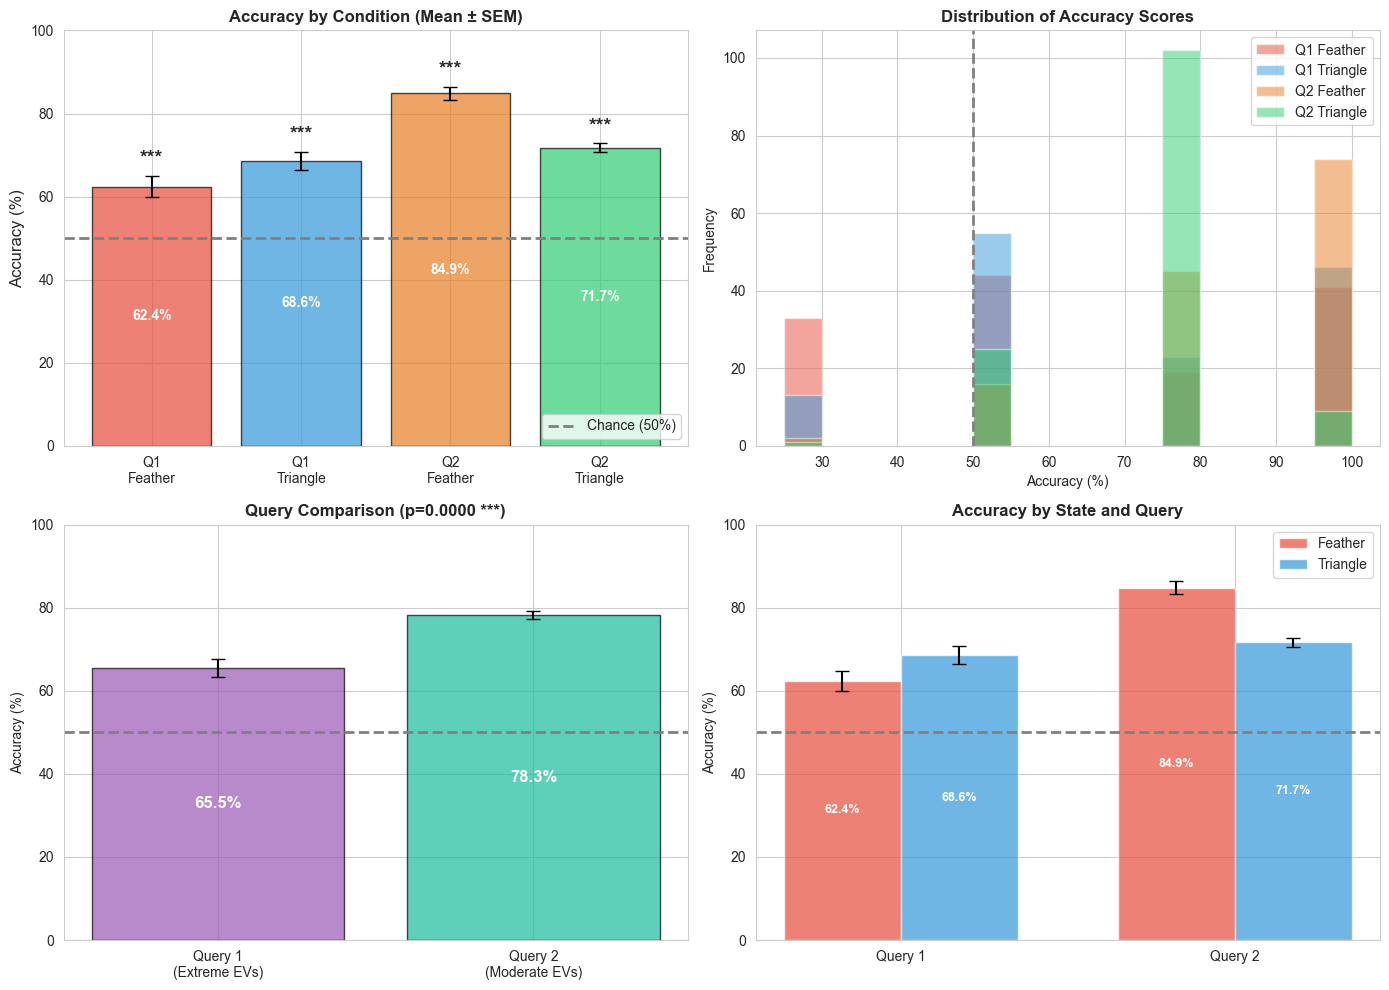

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp
from scipy import stats

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

print("="*80)
print("GENERAL ACCURACY ANALYSIS")
print("="*80)

q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

print("\nExpected Values:")
print(f"  Query 1: Feather EV = {q1_ev_map['Feather']}, Triangle EV = {q1_ev_map['Triangle']}")
print(f"  Query 2: Feather EV = {q2_ev_map['Feather']}, Triangle EV = {q2_ev_map['Triangle']}")

def calculate_state_accuracy(row, query_num, state_name, ev_map):
    optimal_choices = 0
    total_trials = 0
    for trial in range(1, 21):
        state_col = f'Query_{query_num}_T{trial}_State'
        offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
        choice_col = f'Query_{query_num}_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        if row[state_col] != state_name:
            continue
        offer = row[offer_col]
        choice = row[choice_col]
        if pd.isna(choice):
            continue
        state_ev = ev_map.get(state_name, 0)
        optimal_choice = 1 if state_ev > offer else 0
        if choice == optimal_choice:
            optimal_choices += 1
        total_trials += 1
    return (optimal_choices / total_trials * 100) if total_trials > 0 else np.nan

for idx, row in df.iterrows():
    df.loc[idx, 'Q1_Feather_Acc'] = calculate_state_accuracy(row, 1, 'Feather', q1_ev_map)
    df.loc[idx, 'Q1_Triangle_Acc'] = calculate_state_accuracy(row, 1, 'Triangle', q1_ev_map)
    df.loc[idx, 'Q2_Feather_Acc'] = calculate_state_accuracy(row, 2, 'Feather', q2_ev_map)
    df.loc[idx, 'Q2_Triangle_Acc'] = calculate_state_accuracy(row, 2, 'Triangle', q2_ev_map)
    df.loc[idx, 'Q1_Accuracy'] = (df.loc[idx, 'Q1_Feather_Acc'] + df.loc[idx, 'Q1_Triangle_Acc']) / 2
    df.loc[idx, 'Q2_Accuracy'] = (df.loc[idx, 'Q2_Feather_Acc'] + df.loc[idx, 'Q2_Triangle_Acc']) / 2

# Statistical tests
print("\n" + "-"*80)
print("One-Sample T-Tests (Test Value = 50%)")
print("-"*80)

accuracy_vars = [
    ('Q1_Feather_Acc', 'Q1 Feather (pos→neg)'),
    ('Q1_Triangle_Acc', 'Q1 Triangle (neg→pos)'),
    ('Q2_Feather_Acc', 'Q2 Feather'),
    ('Q2_Triangle_Acc', 'Q2 Triangle')
]

test_results = {}
for var, label in accuracy_vars:
    data = df[var].dropna()
    t, p = ttest_1samp(data, 50)
    sem = stats.sem(data)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    test_results[var] = {'mean': data.mean(), 'sem': sem, 't': t, 'p': p, 'sig': sig, 'label': label}
    print(f"{label}: M={data.mean():.2f}% ± {sem:.2f} (SEM), t({len(data)-1})={t:.2f}, p={p:.4f} {sig}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Accuracy by state and query
ax = axes[0, 0]
conditions = ['Q1_Feather_Acc', 'Q1_Triangle_Acc', 'Q2_Feather_Acc', 'Q2_Triangle_Acc']
labels = ['Q1\nFeather', 'Q1\nTriangle', 'Q2\nFeather', 'Q2\nTriangle']
means = [df[c].mean() for c in conditions]
sems = [stats.sem(df[c].dropna()) for c in conditions]
colors = ['#e74c3c', '#3498db', '#e67e22', '#2ecc71']

bars = ax.bar(labels, means, yerr=sems, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(50, color='gray', linestyle='--', linewidth=2, label='Chance (50%)')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy by Condition (Mean ± SEM)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 100])

# Add significance markers
for i, (bar, var) in enumerate(zip(bars, conditions)):
    sig = test_results[var]['sig']
    if sig:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sems[i] + 2, 
                sig, ha='center', va='bottom', fontsize=14, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{means[i]:.1f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.legend(loc='lower right')

# Panel B: Distribution of accuracies
ax = axes[0, 1]
for i, (var, color) in enumerate(zip(conditions, colors)):
    ax.hist(df[var].dropna(), bins=15, alpha=0.5, label=labels[i].replace('\n', ' '), color=color)
ax.axvline(50, color='gray', linestyle='--', linewidth=2)
ax.set_xlabel('Accuracy (%)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Accuracy Scores', fontweight='bold')
ax.legend()

# Panel C: Query comparison
ax = axes[1, 0]
q1_mean, q1_sem = df['Q1_Accuracy'].mean(), stats.sem(df['Q1_Accuracy'].dropna())
q2_mean, q2_sem = df['Q2_Accuracy'].mean(), stats.sem(df['Q2_Accuracy'].dropna())

t_q, p_q = stats.ttest_rel(df['Q1_Accuracy'].dropna(), df['Q2_Accuracy'].dropna())
sig_q = '***' if p_q < 0.001 else '**' if p_q < 0.01 else '*' if p_q < 0.05 else 'n.s.'

bars = ax.bar(['Query 1\n(Extreme EVs)', 'Query 2\n(Moderate EVs)'], [q1_mean, q2_mean], 
              yerr=[q1_sem, q2_sem], capsize=5, color=['#9b59b6', '#1abc9c'], alpha=0.7, edgecolor='black')
ax.axhline(50, color='gray', linestyle='--', linewidth=2)
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Query Comparison (p={p_q:.4f} {sig_q})', fontweight='bold')
ax.set_ylim([0, 100])

for bar, mean in zip(bars, [q1_mean, q2_mean]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{mean:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Panel D: State comparison within each query
ax = axes[1, 1]
x = np.arange(2)
width = 0.35

feather_means = [df['Q1_Feather_Acc'].mean(), df['Q2_Feather_Acc'].mean()]
feather_sems = [stats.sem(df['Q1_Feather_Acc'].dropna()), stats.sem(df['Q2_Feather_Acc'].dropna())]
triangle_means = [df['Q1_Triangle_Acc'].mean(), df['Q2_Triangle_Acc'].mean()]
triangle_sems = [stats.sem(df['Q1_Triangle_Acc'].dropna()), stats.sem(df['Q2_Triangle_Acc'].dropna())]

bars1 = ax.bar(x - width/2, feather_means, width, yerr=feather_sems, capsize=5, 
               label='Feather', color='#e74c3c', alpha=0.7)
bars2 = ax.bar(x + width/2, triangle_means, width, yerr=triangle_sems, capsize=5,
               label='Triangle', color='#3498db', alpha=0.7)

ax.axhline(50, color='gray', linestyle='--', linewidth=2)
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_xticklabels(['Query 1', 'Query 2'])
ax.set_title('Accuracy by State and Query', fontweight='bold')
ax.set_ylim([0, 100])
ax.legend()

for bars, means in [(bars1, feather_means), (bars2, triangle_means)]:
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'{mean:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('accuracy_analysis.png', dpi=150)
print("\nSaved: accuracy_analysis.png")
plt.show()

df.to_csv('filtered_data.csv', index=False)

---
# Section 5: Linear Mixed Models (Query 1 & Query 2)

LINEAR MIXED MODELS: ACCURACY BY STATE TYPE

QUERY 1 ANALYSIS
Expected Values: Feather = -15, Triangle = 15

Total observations: 1096, Subjects: 137

Descriptives (Mean ± SEM):
  Feather:  M = 62.41% ± 2.47%
  Triangle: M = 68.61% ± 2.20%

Paired t-test: t(136) = -2.953, p = 0.003704 **
Mean Difference: -6.20%, Cohen's d = -0.252

QUERY 2 ANALYSIS
Expected Values: Feather = 0, Triangle = 10

Total observations: 1096, Subjects: 137

Descriptives (Mean ± SEM):
  Feather:  M = 84.85% ± 1.60%
  Triangle: M = 57.48% ± 1.43%

Paired t-test: t(136) = 11.679, p = 0.000000 ***
Mean Difference: 27.37%, Cohen's d = 0.998

Saved: lmm_accuracy_by_state.png


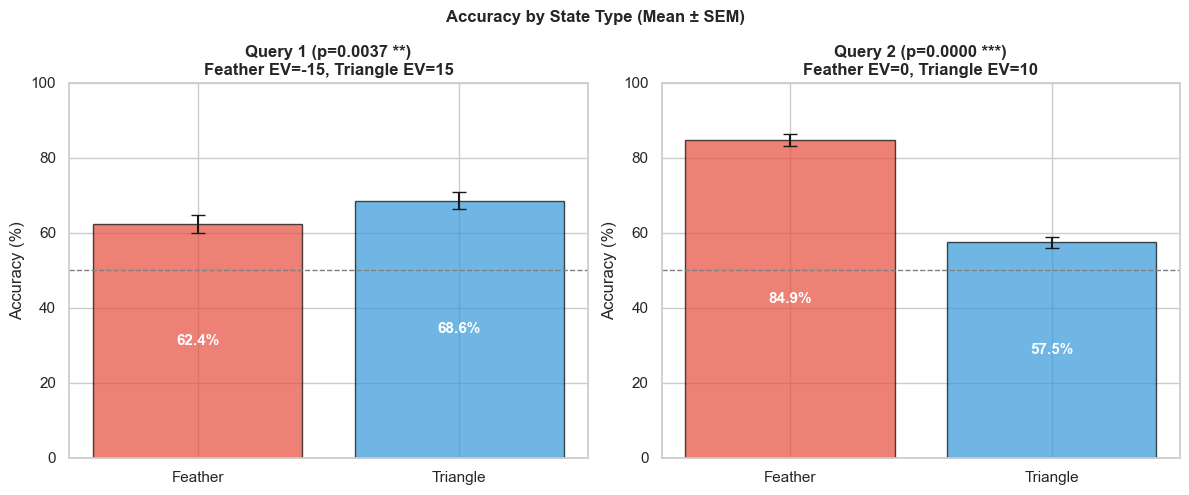

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

print("="*80)
print("LINEAR MIXED MODELS: ACCURACY BY STATE TYPE")
print("="*80)

Q1_EV = {'Feather': -15, 'Triangle': 15}
Q2_EV = {'Feather': 0, 'Triangle': 10}

def run_lmm_analysis(df, query_num, ev_map):
    print(f"\n{'='*80}")
    print(f"QUERY {query_num} ANALYSIS")
    print(f"{'='*80}")
    print(f"Expected Values: Feather = {ev_map['Feather']}, Triangle = {ev_map['Triangle']}")
    
    records = []
    for idx, row in df.iterrows():
        subject_id = row['subject_id']
        for trial in range(1, 9):
            state = row.get(f'Query_{query_num}_T{trial}_State')
            choice = row.get(f'Query_{query_num}_T{trial}_Choice')
            offer = row.get(f'Query_{query_num}_T{trial}_FixedOffer')
            
            if pd.isna(state) or pd.isna(choice) or pd.isna(offer):
                continue
            
            true_ev = ev_map[state]
            optimal_choice = 1 if true_ev > offer else (0 if true_ev < offer else None)
            accuracy = 1 if choice == optimal_choice else 0
            
            records.append({'subject_id': subject_id, 'trial': trial, 'state_type': state, 'accuracy': accuracy})
    
    df_long = pd.DataFrame(records)
    print(f"\nTotal observations: {len(df_long)}, Subjects: {df_long['subject_id'].nunique()}")
    
    subject_acc = df_long.groupby(['subject_id', 'state_type'])['accuracy'].mean().reset_index()
    subject_acc_wide = subject_acc.pivot(index='subject_id', columns='state_type', values='accuracy')
    
    n_subjects = len(subject_acc_wide)
    feather_means = subject_acc_wide['Feather'].values
    triangle_means = subject_acc_wide['Triangle'].values
    
    print(f"\nDescriptives (Mean ± SEM):")
    print(f"  Feather:  M = {feather_means.mean()*100:.2f}% ± {stats.sem(feather_means)*100:.2f}%")
    print(f"  Triangle: M = {triangle_means.mean()*100:.2f}% ± {stats.sem(triangle_means)*100:.2f}%")
    
    t_stat, p_val = stats.ttest_rel(feather_means, triangle_means)
    mean_diff = feather_means.mean() - triangle_means.mean()
    cohens_d = mean_diff / np.std(feather_means - triangle_means, ddof=1)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    
    print(f"\nPaired t-test: t({n_subjects-1}) = {t_stat:.3f}, p = {p_val:.6f} {sig}")
    print(f"Mean Difference: {mean_diff*100:.2f}%, Cohen's d = {cohens_d:.3f}")
    
    return subject_acc_wide, {'t': t_stat, 'p': p_val, 'sig': sig, 'd': cohens_d}

q1_results, q1_stats = run_lmm_analysis(df, 1, Q1_EV)
q2_results, q2_stats = run_lmm_analysis(df, 2, Q2_EV)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (results, query_num, ev_map, test_stats) in enumerate([
    (q1_results, 1, Q1_EV, q1_stats), (q2_results, 2, Q2_EV, q2_stats)]):
    ax = axes[i]
    means = [results['Feather'].mean()*100, results['Triangle'].mean()*100]
    sems = [stats.sem(results['Feather'])*100, stats.sem(results['Triangle'])*100]
    
    bars = ax.bar(['Feather', 'Triangle'], means, yerr=sems, capsize=5,
                  color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Query {query_num} (p={test_stats["p"]:.4f} {test_stats["sig"]})\n' + 
                 f'Feather EV={ev_map["Feather"]}, Triangle EV={ev_map["Triangle"]}', fontweight='bold')
    ax.set_ylim([0, 100])
    
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'{mean:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.suptitle('Accuracy by State Type (Mean ± SEM)', fontweight='bold')
plt.tight_layout()
plt.savefig('lmm_accuracy_by_state.png', dpi=150)
print("\nSaved: lmm_accuracy_by_state.png")
plt.show()

---
# Section 6: Individual Differences Analysis (Worry & ERQ-Reappraisal)

INDIVIDUAL DIFFERENCES ANALYSIS

Revaluation Magnitude:
  Feather (pos→neg): M=-5.73, SD=12.77
  Triangle (neg→pos): M=4.78, SD=14.18

CONTINUOUS CORRELATIONS

--- WORRY Correlations ---
  Q1_Accuracy: r=-0.041, p=0.6335 
  Q2_Accuracy: r=-0.022, p=0.7997 
  Q1_Feather_Acc: r=-0.115, p=0.1802 
  Q1_Triangle_Acc: r=0.051, p=0.5511 
  Q2_Feather_Acc: r=-0.071, p=0.4099 
  Q2_Triangle_Acc: r=0.067, p=0.4340 
  Feather_Revaluation: r=0.105, p=0.2233 
  Triangle_Revaluation: r=0.039, p=0.6548 

--- ERQ-REAPPRAISAL Correlations ---
  Q1_Accuracy: r=-0.012, p=0.8881 
  Q2_Accuracy: r=-0.011, p=0.9007 
  Q1_Feather_Acc: r=-0.063, p=0.4625 
  Q1_Triangle_Acc: r=0.048, p=0.5767 
  Q2_Feather_Acc: r=-0.133, p=0.1220 
  Q2_Triangle_Acc: r=0.177, p=0.0389 *
  Feather_Revaluation: r=-0.084, p=0.3297 
  Triangle_Revaluation: r=-0.124, p=0.1479 

MEDIAN SPLIT COMPARISONS

--- WORRY GROUPS ---
  Q1_Accuracy: Low=65.52±3.25, High=65.50±2.73, t=0.006, p=0.9954, d=-0.001 
  Q2_Accuracy: Low=78.23±1.41, Hi

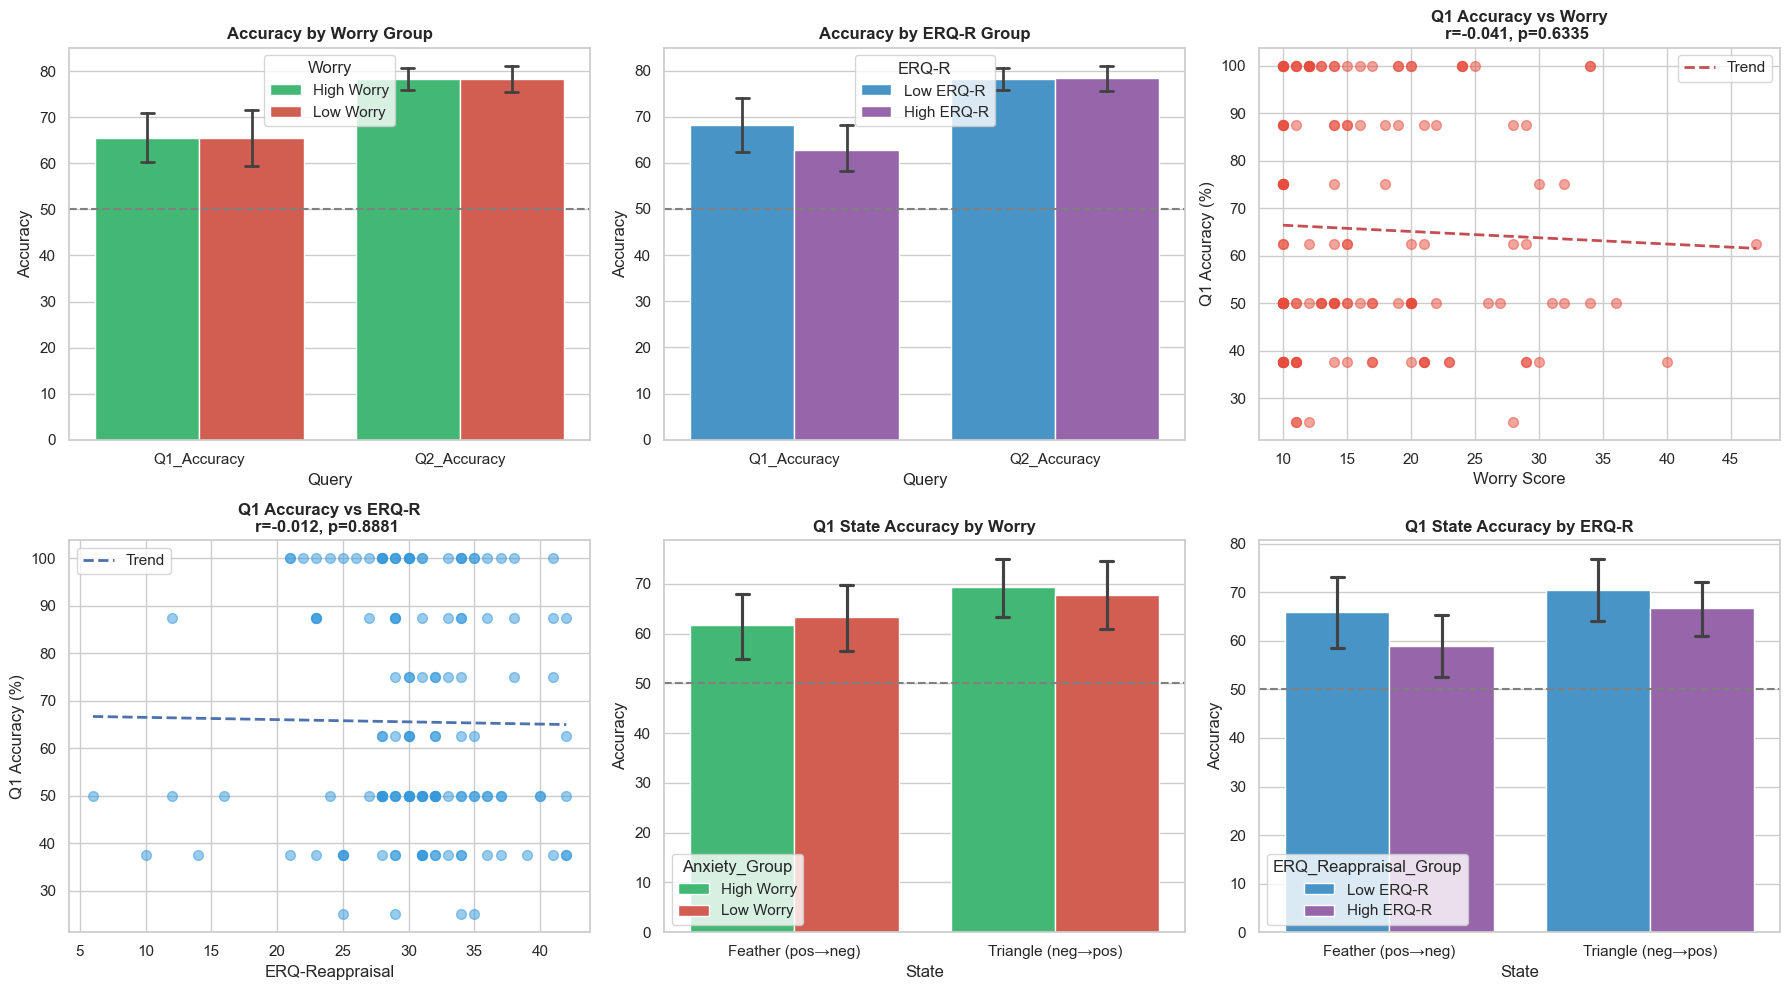

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, ttest_rel

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['Anxiety_Group'] = df['Anxiety_Total'].apply(lambda x: 'High Worry' if x >= df['Anxiety_Total'].median() else 'Low Worry')
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High ERQ-R' if x >= df['ERQ_Reappraisal'].median() else 'Low ERQ-R')

print("="*80)
print("INDIVIDUAL DIFFERENCES ANALYSIS")
print("="*80)

# Revaluation
df['Feather_Rating_1'] = df['Rating_1_Feather_Val']
df['Triangle_Rating_1'] = df['Rating_1_Triangle_Val']
df['Feather_Rating_2'] = df['Rating_2_Feather_Val']
df['Triangle_Rating_2'] = df['Rating_2_Triangle_Val']
df['Feather_Revaluation'] = df['Feather_Rating_2'] - df['Feather_Rating_1']
df['Triangle_Revaluation'] = df['Triangle_Rating_2'] - df['Triangle_Rating_1']

print("\nRevaluation Magnitude:")
print(f"  Feather (pos→neg): M={df['Feather_Revaluation'].mean():.2f}, SD={df['Feather_Revaluation'].std():.2f}")
print(f"  Triangle (neg→pos): M={df['Triangle_Revaluation'].mean():.2f}, SD={df['Triangle_Revaluation'].std():.2f}")

# Correlations
measures = ['Q1_Accuracy', 'Q2_Accuracy', 'Q1_Feather_Acc', 'Q1_Triangle_Acc', 
            'Q2_Feather_Acc', 'Q2_Triangle_Acc', 'Feather_Revaluation', 'Triangle_Revaluation']

print("\n" + "="*80)
print("CONTINUOUS CORRELATIONS")
print("="*80)

corr_results = {'worry': {}, 'erq': {}}

print("\n--- WORRY Correlations ---")
for measure in measures:
    if measure in df.columns:
        valid = df[[measure, 'Anxiety_Total']].dropna()
        r, p = pearsonr(valid[measure], valid['Anxiety_Total'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        corr_results['worry'][measure] = {'r': r, 'p': p, 'sig': sig}
        print(f"  {measure}: r={r:.3f}, p={p:.4f} {sig}")

print("\n--- ERQ-REAPPRAISAL Correlations ---")
for measure in measures:
    if measure in df.columns:
        valid = df[[measure, 'ERQ_Reappraisal']].dropna()
        r, p = pearsonr(valid[measure], valid['ERQ_Reappraisal'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        corr_results['erq'][measure] = {'r': r, 'p': p, 'sig': sig}
        print(f"  {measure}: r={r:.3f}, p={p:.4f} {sig}")

# Median split comparisons
print("\n" + "="*80)
print("MEDIAN SPLIT COMPARISONS")
print("="*80)

accuracy_measures = ['Q1_Accuracy', 'Q2_Accuracy', 'Q1_Feather_Acc', 'Q1_Triangle_Acc', 'Q2_Feather_Acc', 'Q2_Triangle_Acc']

print("\n--- WORRY GROUPS ---")
for measure in accuracy_measures:
    low = df[df['Anxiety_Group']=='Low Worry'][measure].dropna()
    high = df[df['Anxiety_Group']=='High Worry'][measure].dropna()
    t, p = ttest_ind(low, high)
    d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
    sig = '*' if p < 0.05 else ''
    print(f"  {measure}: Low={low.mean():.2f}±{stats.sem(low):.2f}, High={high.mean():.2f}±{stats.sem(high):.2f}, t={t:.3f}, p={p:.4f}, d={d:.3f} {sig}")

print("\n--- ERQ-REAPPRAISAL GROUPS ---")
for measure in accuracy_measures:
    low = df[df['ERQ_Reappraisal_Group']=='Low ERQ-R'][measure].dropna()
    high = df[df['ERQ_Reappraisal_Group']=='High ERQ-R'][measure].dropna()
    t, p = ttest_ind(low, high)
    d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
    sig = '*' if p < 0.05 else ''
    print(f"  {measure}: Low={low.mean():.2f}±{stats.sem(low):.2f}, High={high.mean():.2f}±{stats.sem(high):.2f}, t={t:.3f}, p={p:.4f}, d={d:.3f} {sig}")

# Hypothesis: Revaluation asymmetry
print("\n" + "="*80)
print("HYPOTHESIS: Revaluation Asymmetry in Worriers")
print("="*80)

for group_label in ['Low Worry', 'High Worry']:
    group_df = df[df['Anxiety_Group'] == group_label]
    feather_rev = abs(group_df['Feather_Revaluation']).dropna()
    triangle_rev = abs(group_df['Triangle_Revaluation']).dropna()
    t, p = ttest_rel(feather_rev, triangle_rev)
    sig = '*' if p < 0.05 else ''
    print(f"\n{group_label} (n={len(group_df)}):")
    print(f"  |Feather Change| (pos→neg): M={feather_rev.mean():.2f}")
    print(f"  |Triangle Change| (neg→pos): M={triangle_rev.mean():.2f}")
    print(f"  Paired t-test: t={t:.3f}, p={p:.4f} {sig}")

# Visualizations with significance and trendlines
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel 1: Accuracy by Worry Group
ax = axes[0, 0]
plot_data = pd.melt(df, id_vars=['Anxiety_Group'], value_vars=['Q1_Accuracy', 'Q2_Accuracy'], var_name='Query', value_name='Accuracy')
sns.barplot(data=plot_data, x='Query', y='Accuracy', hue='Anxiety_Group', ax=ax, palette=['#2ecc71', '#e74c3c'], capsize=0.1, errwidth=2)
ax.axhline(50, color='gray', linestyle='--')
ax.set_title('Accuracy by Worry Group', fontweight='bold')
ax.legend(title='Worry')

# Panel 2: Accuracy by ERQ Group
ax = axes[0, 1]
plot_data = pd.melt(df, id_vars=['ERQ_Reappraisal_Group'], value_vars=['Q1_Accuracy', 'Q2_Accuracy'], var_name='Query', value_name='Accuracy')
sns.barplot(data=plot_data, x='Query', y='Accuracy', hue='ERQ_Reappraisal_Group', ax=ax, palette=['#3498db', '#9b59b6'], capsize=0.1, errwidth=2)
ax.axhline(50, color='gray', linestyle='--')
ax.set_title('Accuracy by ERQ-R Group', fontweight='bold')
ax.legend(title='ERQ-R')

# Panel 3: Scatter with trendline - Q1 Accuracy vs Worry
ax = axes[0, 2]
x, y = df['Anxiety_Total'].dropna(), df['Q1_Accuracy'].dropna()
ax.scatter(x, y, alpha=0.5, c='#e74c3c', s=50)
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_line(x_line), 'r--', linewidth=2, label='Trend')
r, pval = corr_results['worry']['Q1_Accuracy']['r'], corr_results['worry']['Q1_Accuracy']['p']
sig = corr_results['worry']['Q1_Accuracy']['sig']
ax.set_xlabel('Worry Score')
ax.set_ylabel('Q1 Accuracy (%)')
ax.set_title(f'Q1 Accuracy vs Worry\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold')
ax.legend()

# Panel 4: Scatter with trendline - Q1 Accuracy vs ERQ-R
ax = axes[1, 0]
x, y = df['ERQ_Reappraisal'].dropna(), df['Q1_Accuracy'].dropna()
ax.scatter(x, y, alpha=0.5, c='#3498db', s=50)
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_line(x_line), 'b--', linewidth=2, label='Trend')
r, pval = corr_results['erq']['Q1_Accuracy']['r'], corr_results['erq']['Q1_Accuracy']['p']
sig = corr_results['erq']['Q1_Accuracy']['sig']
ax.set_xlabel('ERQ-Reappraisal')
ax.set_ylabel('Q1 Accuracy (%)')
ax.set_title(f'Q1 Accuracy vs ERQ-R\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold')
ax.legend()

# Panel 5: State accuracy by Worry
ax = axes[1, 1]
state_data = pd.melt(df, id_vars=['Anxiety_Group'], value_vars=['Q1_Feather_Acc', 'Q1_Triangle_Acc'], var_name='State', value_name='Accuracy')
state_data['State'] = state_data['State'].map({'Q1_Feather_Acc': 'Feather (pos→neg)', 'Q1_Triangle_Acc': 'Triangle (neg→pos)'})
sns.barplot(data=state_data, x='State', y='Accuracy', hue='Anxiety_Group', ax=ax, palette=['#2ecc71', '#e74c3c'], capsize=0.1)
ax.axhline(50, color='gray', linestyle='--')
ax.set_title('Q1 State Accuracy by Worry', fontweight='bold')

# Panel 6: State accuracy by ERQ-R
ax = axes[1, 2]
state_data = pd.melt(df, id_vars=['ERQ_Reappraisal_Group'], value_vars=['Q1_Feather_Acc', 'Q1_Triangle_Acc'], var_name='State', value_name='Accuracy')
state_data['State'] = state_data['State'].map({'Q1_Feather_Acc': 'Feather (pos→neg)', 'Q1_Triangle_Acc': 'Triangle (neg→pos)'})
sns.barplot(data=state_data, x='State', y='Accuracy', hue='ERQ_Reappraisal_Group', ax=ax, palette=['#3498db', '#9b59b6'], capsize=0.1)
ax.axhline(50, color='gray', linestyle='--')
ax.set_title('Q1 State Accuracy by ERQ-R', fontweight='bold')

plt.tight_layout()
plt.savefig('individual_differences_analysis.png', dpi=150)
print("\nSaved: individual_differences_analysis.png")
plt.show()

df.to_csv('filtered_data.csv', index=False)

Loaded 137 subjects
Median Anxiety: 14.0
Median ERQ: 31.0
Total trials: 2192
✓ Saved: p_gamble_evdiff_detailed.png
✓ Saved: p_gamble_evdiff_combined.png
✓ Saved: p_gamble_offer_detailed.png
✓ Saved: p_gamble_offer_combined.png

STATISTICAL ANALYSIS: FIXED OFFER vs P(GAMBLE)
Pearson Correlation between Fixed Offer Value and Gambling Probability
Query Type      | EV    | Pearson r  | p-value    | N Offers
-----------------------------------------------------------------
Q1_Feather      | -15   | -0.985     | 0.0155     | 4       
Q1_Triangle     | 15    | -0.997     | 0.0029     | 4       
Q2_Feather      | 0     | -0.932     | 0.0679     | 4       
Q2_Triangle     | 10    | -0.990     | 0.0096     | 4       

STATISTICAL ANALYSIS: TRAIT INTERACTIONS
Model: Logit(P_Gamble) ~ EV_Diff * Trait

>>> Q1_Feather : Anxiety <<<
                          Coef.  Std.Err.          z         P>|z|    [0.025  \
Intercept              1.467705  0.154405   9.505557  1.989805e-21  1.165077   
ev_differe

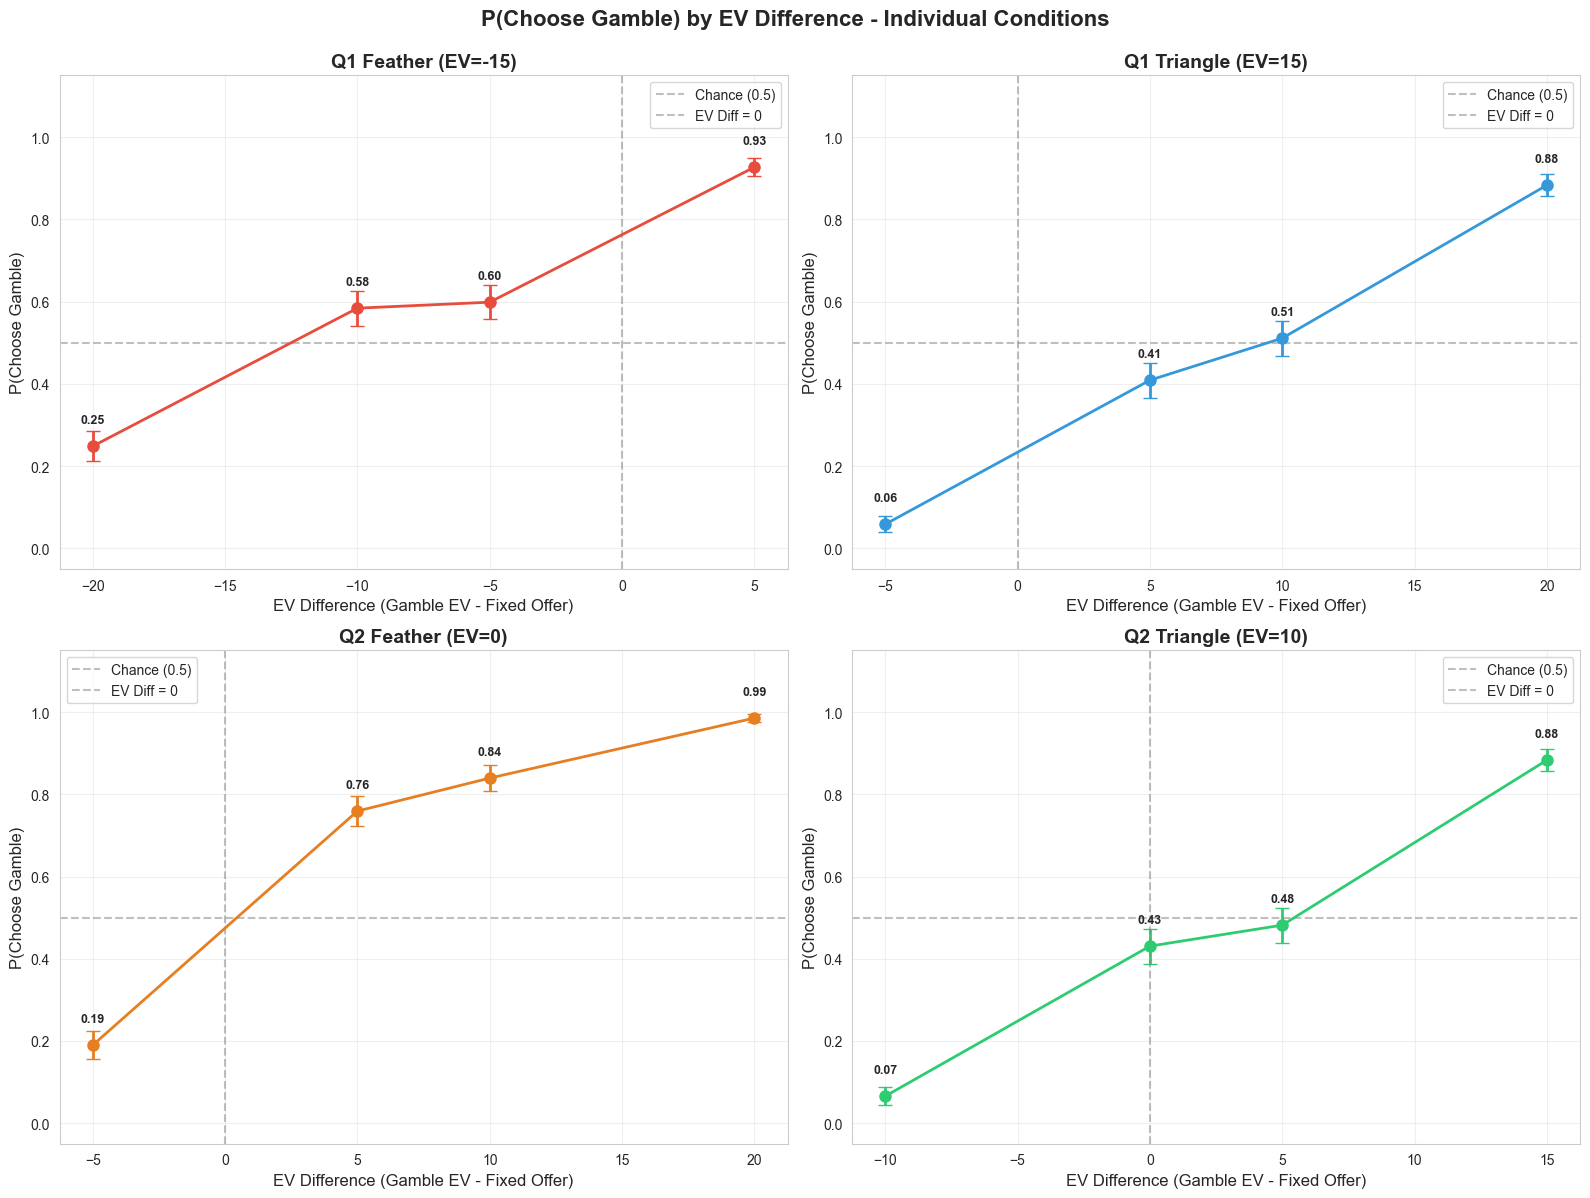

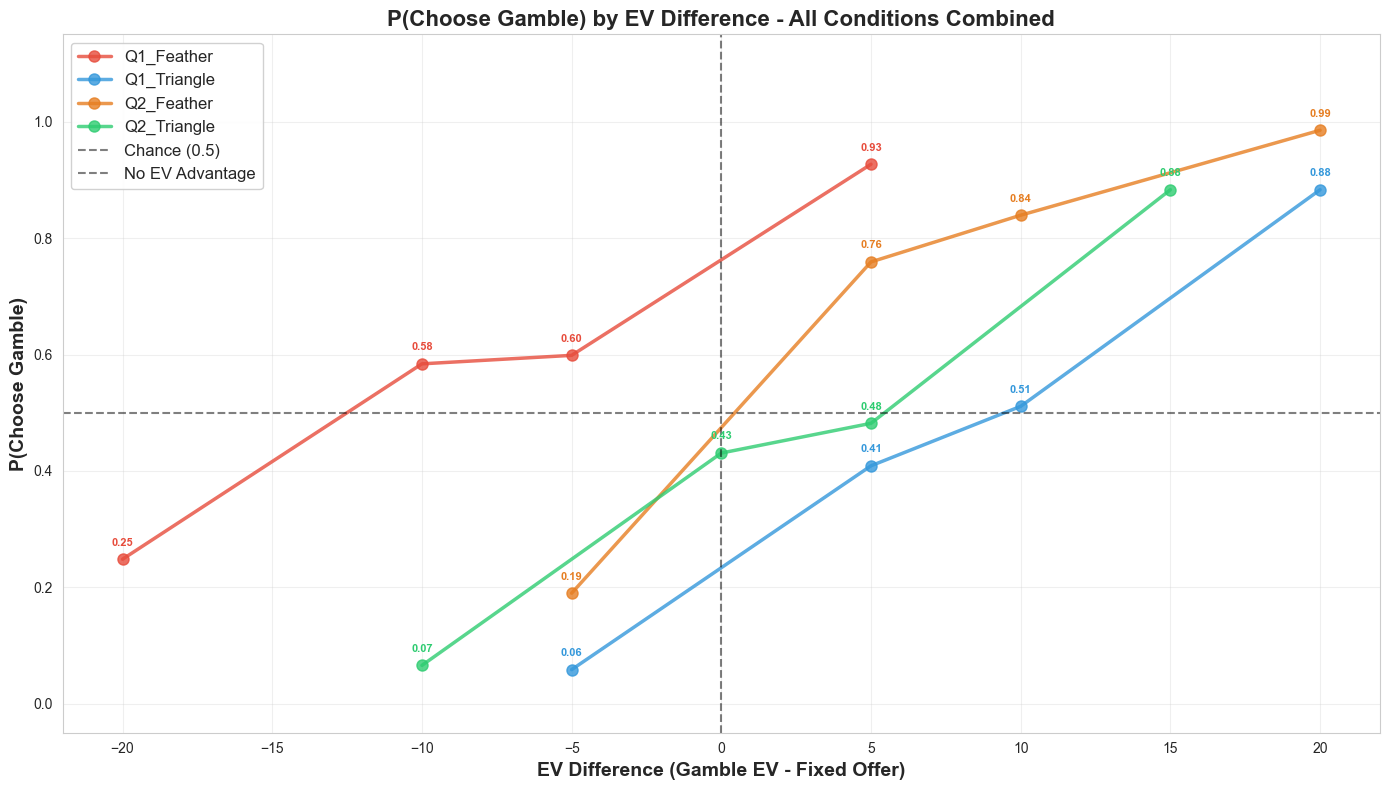

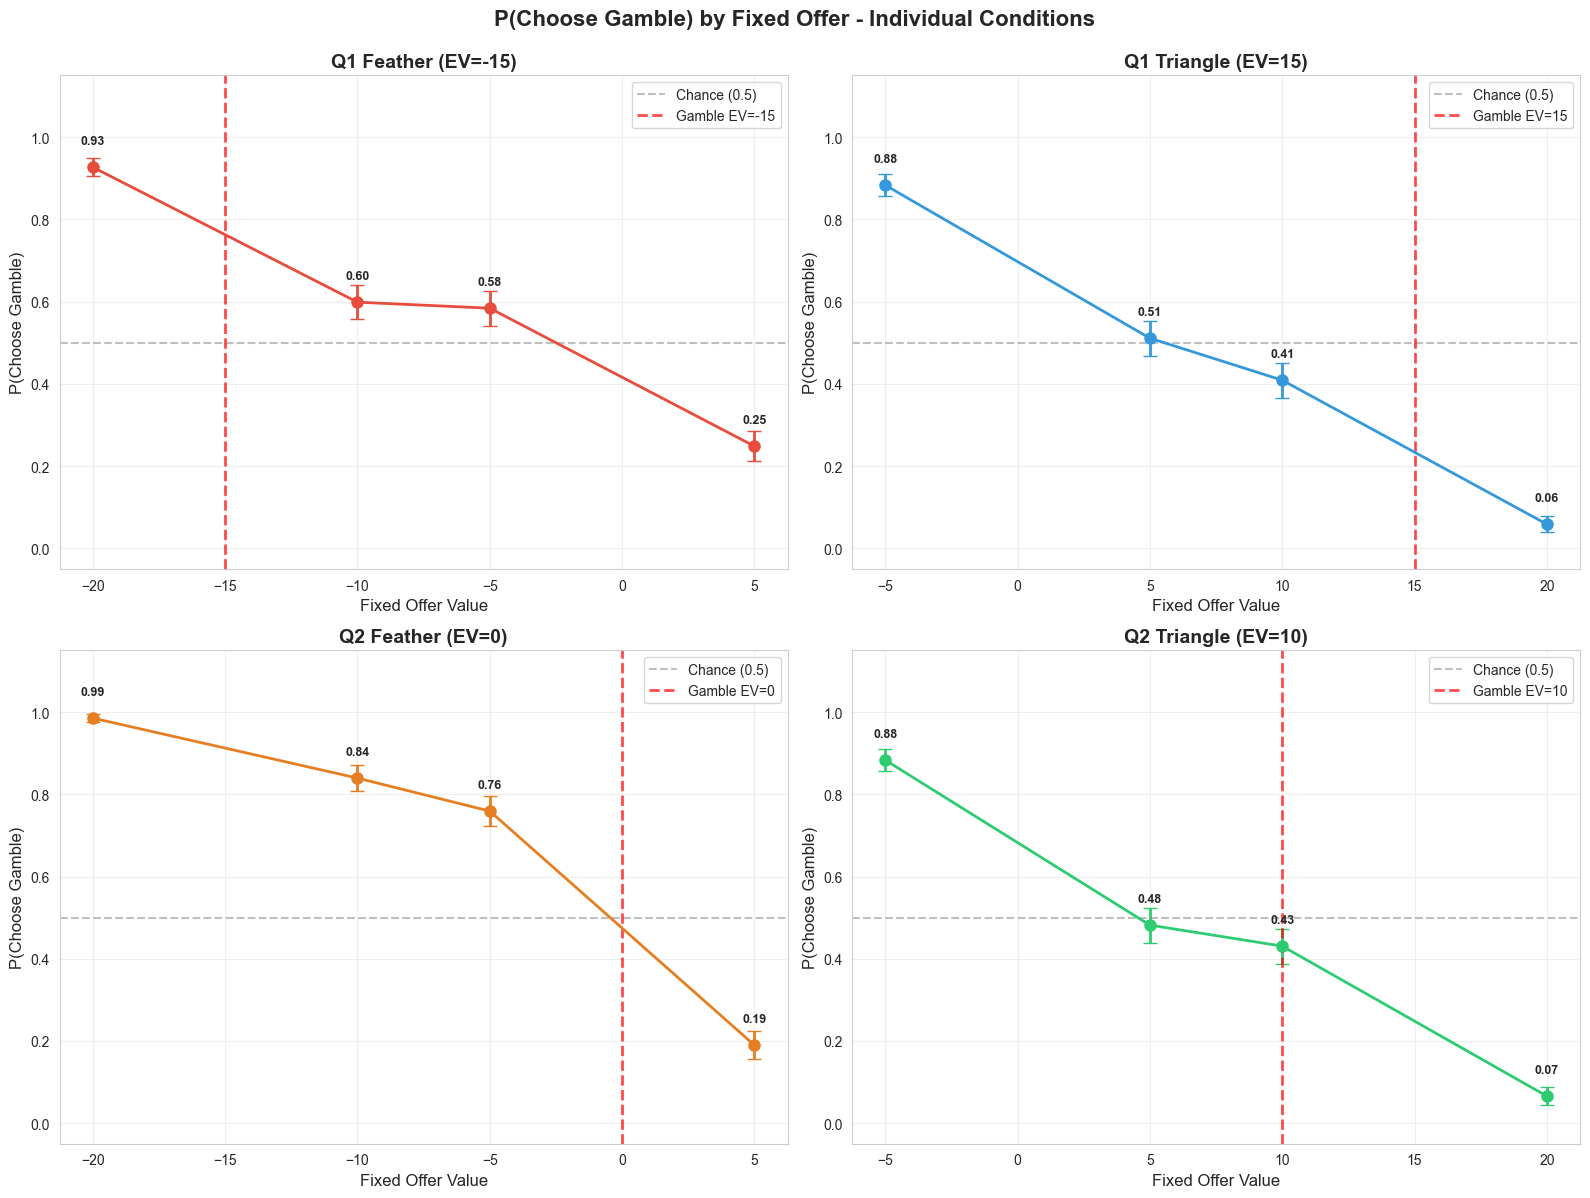

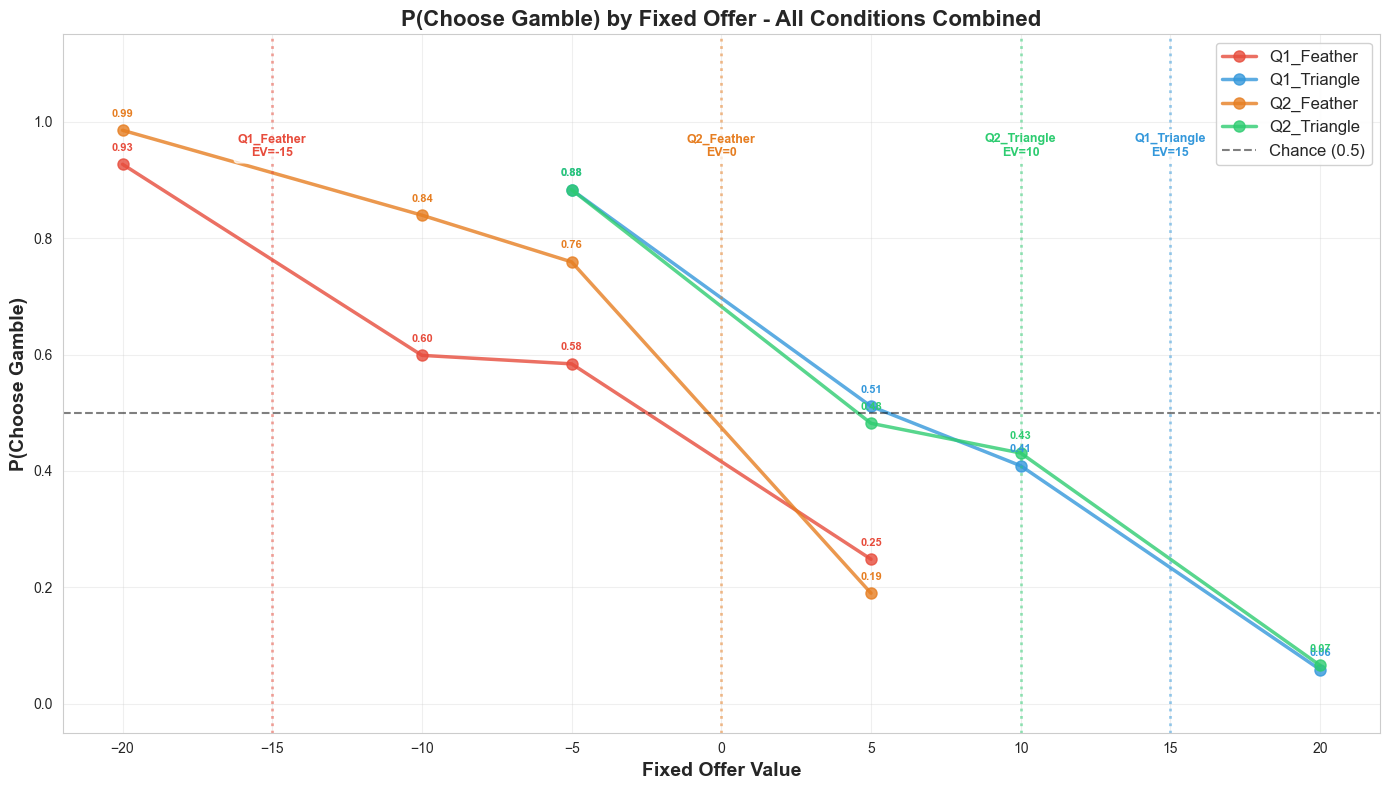

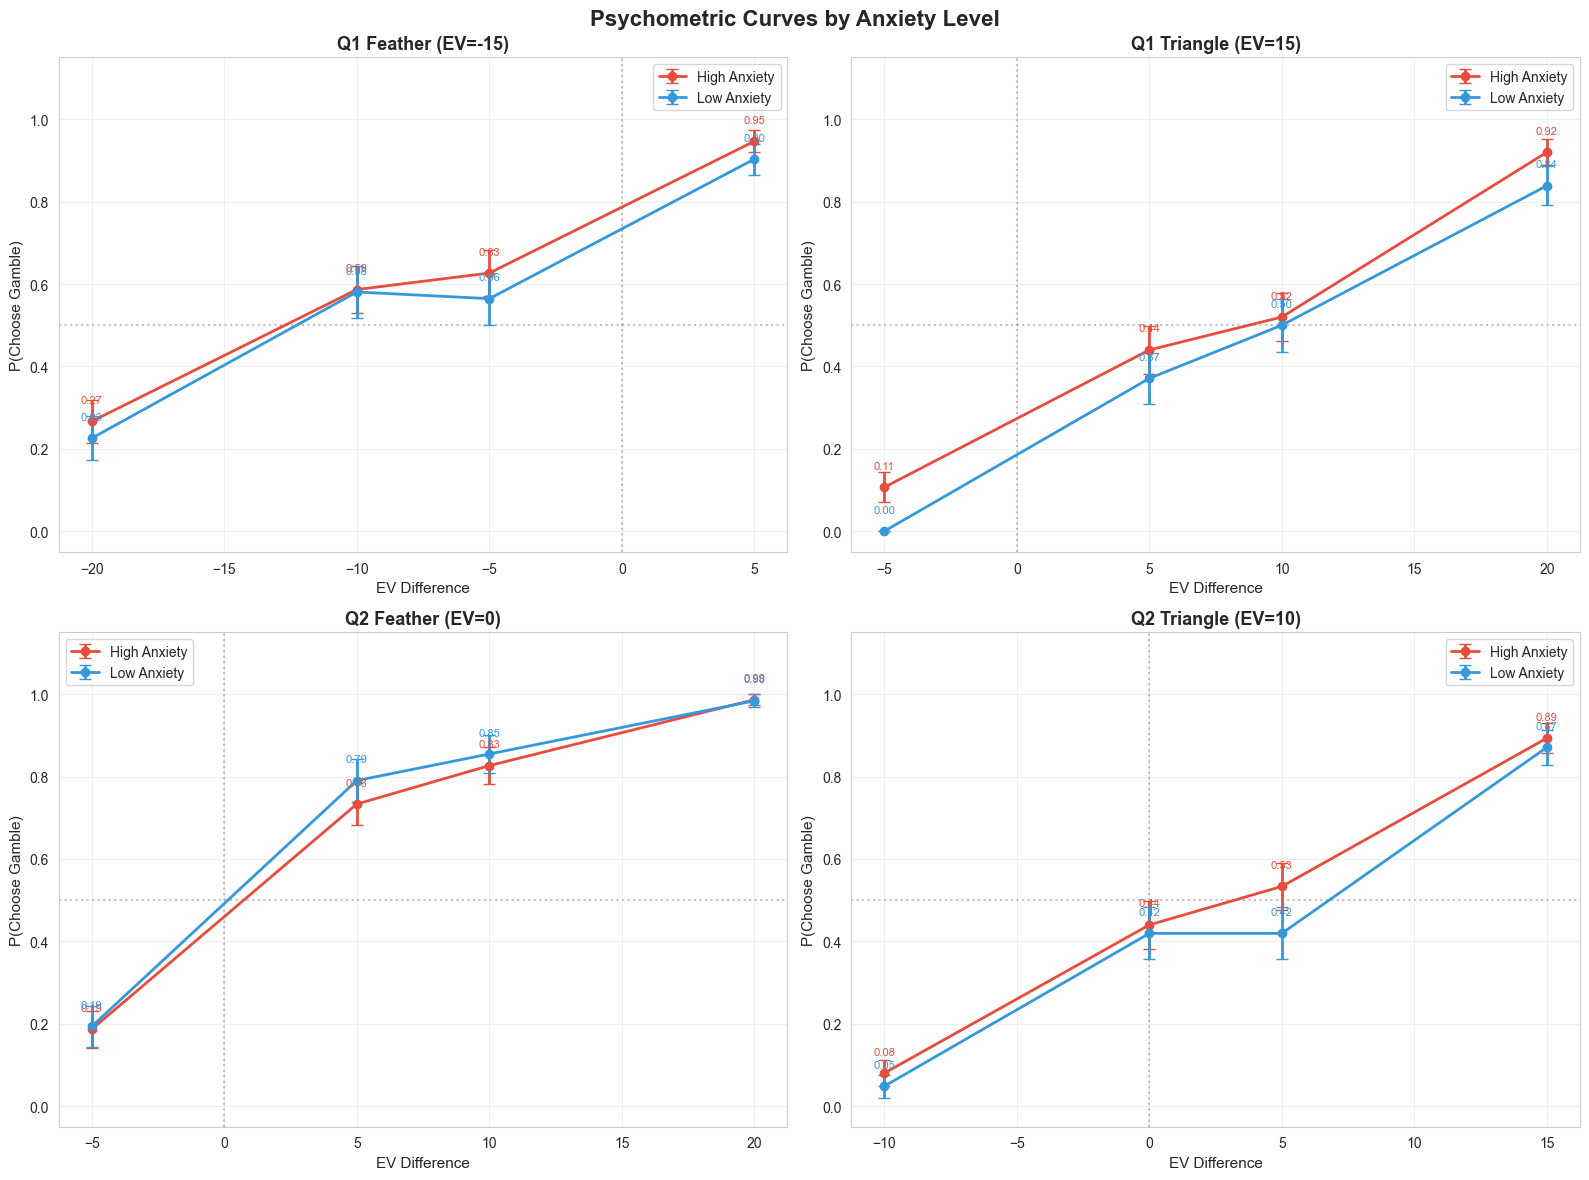

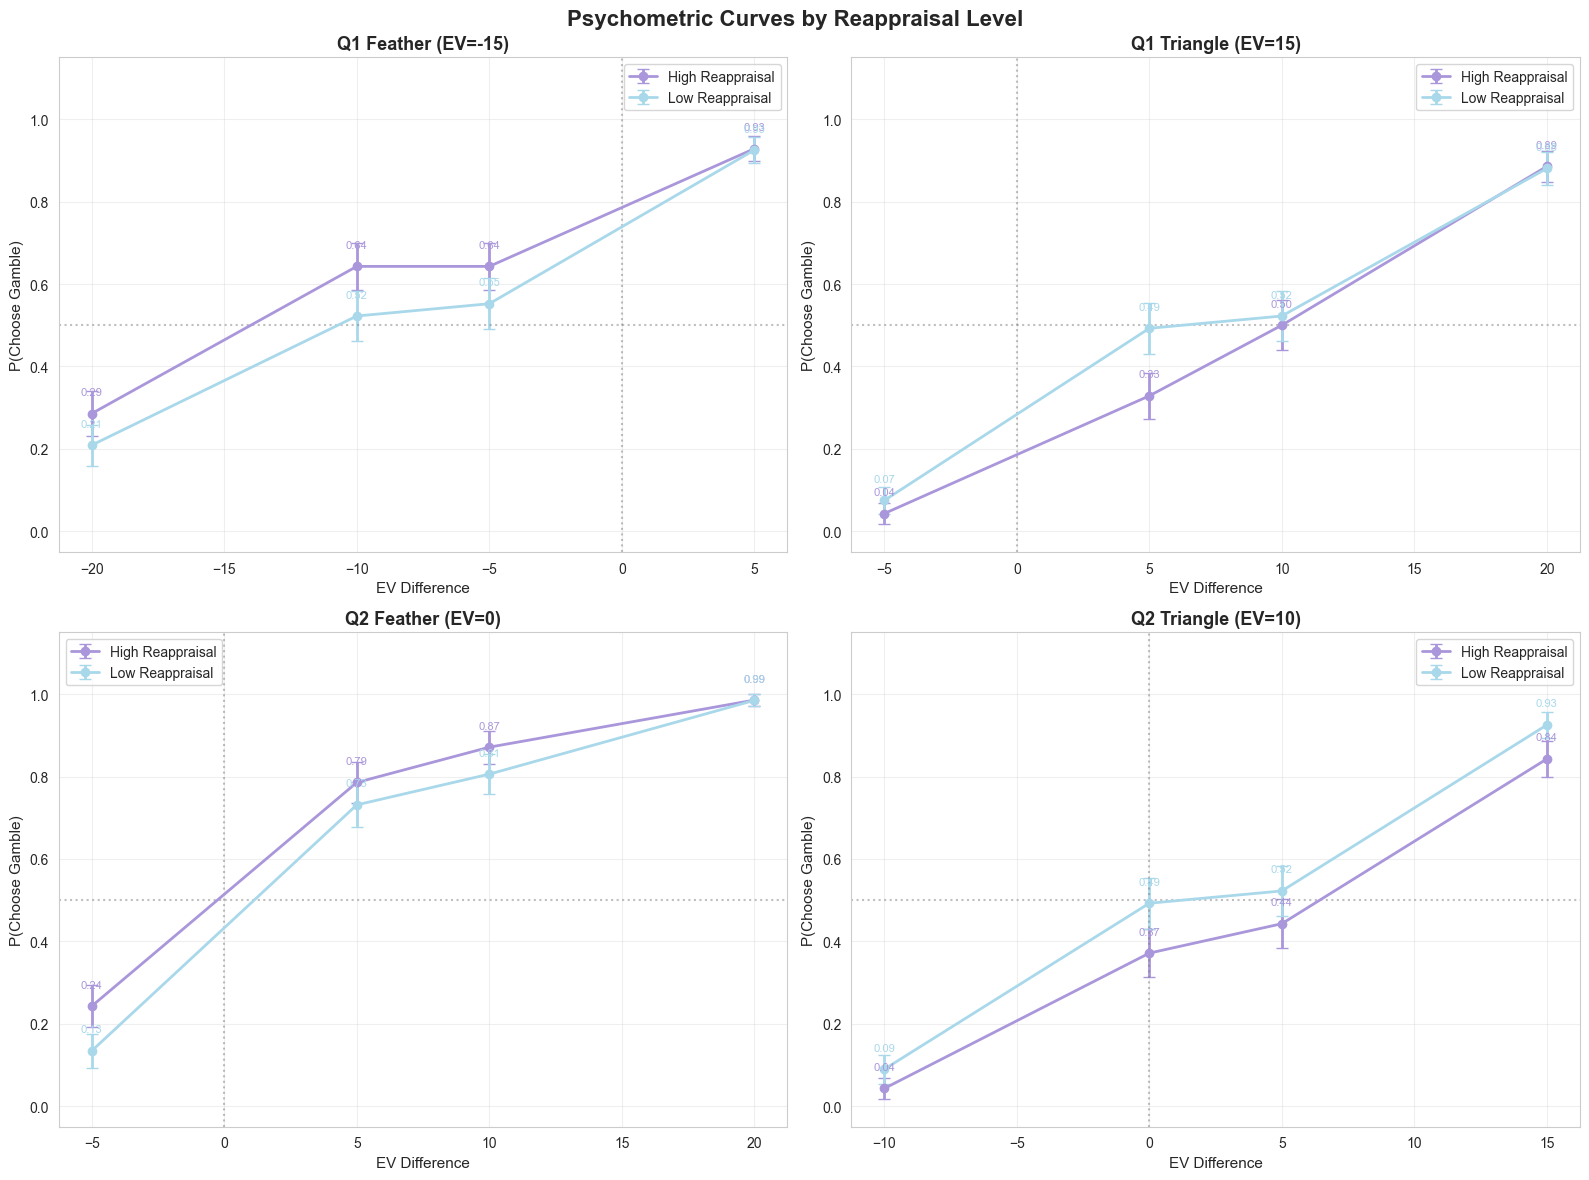

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_csv('filtered_data.csv')
print(f"Loaded {len(df)} subjects")

# ----------------------------------------------------------------------------
# 1. CALCULATE SCORES (Anxiety & ERQ)
# ----------------------------------------------------------------------------
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
median_anx = df['Anxiety_Total'].median()
df['Anxiety_Group'] = df['Anxiety_Total'].apply(lambda x: 'High Anxiety' if x >= median_anx else 'Low Anxiety')

erq_cols = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
            'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

if all(col in df.columns for col in erq_cols):
    df['ERQ_Reappraisal'] = df[erq_cols].sum(axis=1)
else:
    df['ERQ_Reappraisal'] = df.get('Survey_ERQ_Reappraisal_Score', np.nan)

median_erq = df['ERQ_Reappraisal'].median()
df['ERQ_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High Reappraisal' if x >= median_erq else 'Low Reappraisal')

print(f"Median Anxiety: {median_anx}")
print(f"Median ERQ: {median_erq}")

# ----------------------------------------------------------------------------
# 2. PREPARE LONG FORMAT DATA
# ----------------------------------------------------------------------------
long_data = []

for idx, row in df.iterrows():
    subj_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anx_group = row['Anxiety_Group']
    erq = row['ERQ_Reappraisal']
    erq_group = row['ERQ_Group']

    for query_num in [1, 2]:
        for trial_num in range(1, 9):
            trial_col_prefix = f'Query_{query_num}_T{trial_num}'
            choice = row.get(f'{trial_col_prefix}_Choice', np.nan)
            state = row.get(f'{trial_col_prefix}_State', np.nan)
            fixed_offer = row.get(f'{trial_col_prefix}_FixedOffer', np.nan)

            if pd.isna(choice) or pd.isna(state) or pd.isna(fixed_offer):
                continue

            query_type = f"Q{query_num}_{state}"

            ev_dict = {
                (1, 'Feather'): -15, (2, 'Feather'): 0,
                (1, 'Triangle'): 15, (2, 'Triangle'): 10
            }
            ev = ev_dict.get((query_num, state), np.nan)

            ev_difference = ev - fixed_offer
            chose_gamble = int(choice)

            long_data.append({
                'subject_id': subj_id,
                'Anxiety_Total': anxiety,
                'Anxiety_Group': anx_group,
                'ERQ_Reappraisal': erq,
                'ERQ_Group': erq_group,
                'query_num': query_num,
                'state': state,
                'ev': ev,
                'query_type': query_type,
                'ev_difference': ev_difference,
                'chose_gamble': chose_gamble,
                'fixed_offer': fixed_offer
            })

long_df = pd.DataFrame(long_data)
print(f"Total trials: {len(long_df)}")

# ----------------------------------------------------------------------------
# 3. AGGREGATE DATA FOR PLOTTING
# ----------------------------------------------------------------------------
# By EV Difference
choice_by_evdiff = long_df.groupby(['query_type', 'ev_difference']).agg(
    p_gamble=('chose_gamble', 'mean'),
    n_trials=('chose_gamble', 'count'),
    se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

# By Fixed Offer
choice_by_offer = long_df.groupby(['query_type', 'fixed_offer']).agg(
    p_gamble=('chose_gamble', 'mean'),
    n_trials=('chose_gamble', 'count'),
    se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

query_types = ['Q1_Feather', 'Q1_Triangle', 'Q2_Feather', 'Q2_Triangle']
colors = {
    'Q1_Feather': '#e74c3c',    # Red
    'Q1_Triangle': '#3498db',   # Blue
    'Q2_Feather': '#e67e22',    # Orange
    'Q2_Triangle': '#2ecc71'    # Green
}

# ----------------------------------------------------------------------------
# 4. FIGURE 1: INDIVIDUAL PLOTS WITH EXACT VALUES (BY EV DIFFERENCE)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, qt in enumerate(query_types):
    ax = axes[i]
    subset = choice_by_evdiff[choice_by_evdiff['query_type'] == qt].sort_values('ev_difference')

    if len(subset) > 0:
        # Plot line with error bars
        ax.errorbar(subset['ev_difference'], subset['p_gamble'], yerr=subset['se'], 
                   fmt='o-', color=colors[qt], linewidth=2, markersize=8, capsize=5)

        # Add exact values as text labels
        for _, row in subset.iterrows():
            ax.text(row['ev_difference'], row['p_gamble'] + 0.05, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Extract query details
    query_num = qt.split('_')[0]
    state = qt.split('_')[1]
    ev_val = long_df[long_df['query_type'] == qt]['ev'].iloc[0]

    # Add reference lines
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='EV Diff = 0')

    # Styling
    ax.set_title(f'{query_num} {state} (EV={ev_val})', fontsize=14, fontweight='bold')
    ax.set_xlabel('EV Difference (Gamble EV - Fixed Offer)', fontsize=12)
    ax.set_ylabel('P(Choose Gamble)', fontsize=12)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.suptitle('P(Choose Gamble) by EV Difference - Individual Conditions', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('p_gamble_evdiff_detailed.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_evdiff_detailed.png")

# ----------------------------------------------------------------------------
# 5. FIGURE 2: COMBINED PLOT - ALL CONDITIONS (BY EV DIFFERENCE)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for qt in query_types:
    subset = choice_by_evdiff[choice_by_evdiff['query_type'] == qt].sort_values('ev_difference')

    if len(subset) > 0:
        # Plot line
        ax.plot(subset['ev_difference'], subset['p_gamble'], 
               'o-', color=colors[qt], linewidth=2.5, markersize=8, 
               label=qt, alpha=0.8)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['ev_difference'], row['p_gamble'] + 0.02, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=8, 
                   color=colors[qt], fontweight='bold')

# Reference lines
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (0.5)')
ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='No EV Advantage')

# Styling
ax.set_xlabel('EV Difference (Gamble EV - Fixed Offer)', fontsize=14, fontweight='bold')
ax.set_ylabel('P(Choose Gamble)', fontsize=14, fontweight='bold')
ax.set_title('P(Choose Gamble) by EV Difference - All Conditions Combined', 
            fontsize=16, fontweight='bold')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.savefig('p_gamble_evdiff_combined.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_evdiff_combined.png")

# ----------------------------------------------------------------------------
# 6. FIGURE 3: INDIVIDUAL PLOTS WITH EXACT VALUES (BY FIXED OFFER)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, qt in enumerate(query_types):
    ax = axes[i]
    subset = choice_by_offer[choice_by_offer['query_type'] == qt].sort_values('fixed_offer')

    if len(subset) > 0:
        # Plot line with error bars
        ax.errorbar(subset['fixed_offer'], subset['p_gamble'], yerr=subset['se'], 
                   fmt='o-', color=colors[qt], linewidth=2, markersize=8, capsize=5)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['fixed_offer'], row['p_gamble'] + 0.05, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Extract query details
    query_num = qt.split('_')[0]
    state = qt.split('_')[1]
    ev_val = long_df[long_df['query_type'] == qt]['ev'].iloc[0]

    # Add reference lines
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')
    ax.axvline(ev_val, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Gamble EV={ev_val}')

    # Styling
    ax.set_title(f'{query_num} {state} (EV={ev_val})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Fixed Offer Value', fontsize=12)
    ax.set_ylabel('P(Choose Gamble)', fontsize=12)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.suptitle('P(Choose Gamble) by Fixed Offer - Individual Conditions', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('p_gamble_offer_detailed.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_offer_detailed.png")

# ----------------------------------------------------------------------------
# 7. FIGURE 4: COMBINED PLOT - ALL CONDITIONS (BY FIXED OFFER)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for qt in query_types:
    subset = choice_by_offer[choice_by_offer['query_type'] == qt].sort_values('fixed_offer')

    if len(subset) > 0:
        # Plot line
        ax.plot(subset['fixed_offer'], subset['p_gamble'], 
               'o-', color=colors[qt], linewidth=2.5, markersize=8, 
               label=qt, alpha=0.8)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['fixed_offer'], row['p_gamble'] + 0.02, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=8, 
                   color=colors[qt], fontweight='bold')

# Add vertical lines for each EV
ev_lines = {
    'Q1_Feather': -15,
    'Q1_Triangle': 15,
    'Q2_Feather': 0,
    'Q2_Triangle': 10
}
for qt, ev in ev_lines.items():
    ax.axvline(ev, color=colors[qt], linestyle=':', alpha=0.5, linewidth=2)
    ax.text(ev, 0.98, f'{qt}\nEV={ev}', ha='center', va='top', 
           fontsize=9, color=colors[qt], fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Reference line
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (0.5)')

# Styling
ax.set_xlabel('Fixed Offer Value', fontsize=14, fontweight='bold')
ax.set_ylabel('P(Choose Gamble)', fontsize=14, fontweight='bold')
ax.set_title('P(Choose Gamble) by Fixed Offer - All Conditions Combined', 
            fontsize=16, fontweight='bold')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.savefig('p_gamble_offer_combined.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_offer_combined.png")

# ----------------------------------------------------------------------------
# 8. STATISTICAL ANALYSIS: CORRELATIONS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL ANALYSIS: FIXED OFFER vs P(GAMBLE)")
print("Pearson Correlation between Fixed Offer Value and Gambling Probability")
print("="*80)

conditions = long_df[['query_num', 'state', 'ev', 'query_type']].drop_duplicates().sort_values('query_type')
print(f"{'Query Type':<15} | {'EV':<5} | {'Pearson r':<10} | {'p-value':<10} | {'N Offers':<8}")
print("-" * 65)

for _, cond in conditions.iterrows():
    qt = cond['query_type']
    ev_val = cond['ev']

    subset = long_df[long_df['query_type'] == qt]
    offer_stats = subset.groupby('fixed_offer')['chose_gamble'].agg(['mean', 'count']).reset_index()
    offer_stats.rename(columns={'mean': 'p_gamble'}, inplace=True)

    if len(offer_stats) > 1:
        r, p = stats.pearsonr(offer_stats['fixed_offer'], offer_stats['p_gamble'])
        print(f"{qt:<15} | {ev_val:<5} | {r:<10.3f} | {p:<10.4f} | {len(offer_stats):<8}")
    else:
        print(f"{qt:<15} | {ev_val:<5} | {'NaN':<10} | {'NaN':<10} | {len(offer_stats):<8}")

# ----------------------------------------------------------------------------
# 9. LOGISTIC REGRESSION WITH INTERACTIONS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL ANALYSIS: TRAIT INTERACTIONS")
print("Model: Logit(P_Gamble) ~ EV_Diff * Trait")
print("="*80)

def analyze_interaction(data, trait_col, trait_name, label):
    print(f"\n>>> {label} : {trait_name} <<<")

    if trait_col not in data.columns:
        print(f"  Error: Column '{trait_col}' not found.")
        return

    data['trait_z'] = (data[trait_col] - data[trait_col].mean()) / data[trait_col].std()
    formula = "chose_gamble ~ ev_difference * trait_z"

    try:
        model = smf.logit(formula, data=data).fit(disp=0)
        print(model.summary2().tables[1])

        params = model.params
        pvals = model.pvalues
        sig_threshold = 0.05

        if pvals['trait_z'] < sig_threshold:
            direction = "INCREASES" if params['trait_z'] > 0 else "DECREASES"
            print(f"  * SIGNIFICANT MAIN EFFECT: Higher {trait_name} {direction} overall gambling rate.")

        if pvals['ev_difference:trait_z'] < sig_threshold:
            direction = "STEEPER" if params['ev_difference:trait_z'] > 0 else "FLATTER"
            print(f"  * SIGNIFICANT INTERACTION: Higher {trait_name} makes curve {direction}.")

    except Exception as e:
        print(f"  Error: {e}")

for qt in query_types:
    subset = long_df[long_df['query_type'] == qt].copy()
    analyze_interaction(subset, 'Anxiety_Total', 'Anxiety', f"{qt}")
    analyze_interaction(subset, 'ERQ_Reappraisal', 'ERQ', f"{qt}")

# ----------------------------------------------------------------------------
# 10. PSYCHOMETRIC CURVES BY GROUP
# ----------------------------------------------------------------------------
def plot_psychometric_group(data, group_col, title_suffix, filename):
    if group_col not in data.columns:
        print(f"Error: Column '{group_col}' not found.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    groups = sorted(data[group_col].unique())
    if 'Anxiety' in group_col:
        palette = {'Low Anxiety': '#3498DB', 'High Anxiety': '#E74C3C'}
    else:
        palette = {'Low Reappraisal': '#A8D8EA', 'High Reappraisal': '#AA96DA'}

    for i, qt in enumerate(query_types):
        ax = axes[i]
        qt_data = data[data['query_type'] == qt]

        # Group stats
        group_stats = qt_data.groupby([group_col, 'ev_difference']).agg(
            p_gamble=('chose_gamble', 'mean'),
            se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)))
        ).reset_index()

        # Plot for each group
        for grp in groups:
            grp_stats = group_stats[group_stats[group_col] == grp].sort_values('ev_difference')
            if len(grp_stats) > 0:
                ax.errorbar(grp_stats['ev_difference'], grp_stats['p_gamble'], 
                           yerr=grp_stats['se'], fmt='o-', color=palette[grp],
                           label=grp, linewidth=2, markersize=6, capsize=4)

                # Add values
                for _, row in grp_stats.iterrows():
                    ax.text(row['ev_difference'], row['p_gamble'] + 0.04, 
                           f"{row['p_gamble']:.2f}", 
                           ha='center', va='bottom', fontsize=8, color=palette[grp])

        # Extract details
        query_num = qt.split('_')[0]
        state = qt.split('_')[1]
        ev_val = qt_data['ev'].iloc[0]

        ax.set_title(f'{query_num} {state} (EV={ev_val})', fontsize=13, fontweight='bold')
        ax.set_xlabel('EV Difference', fontsize=11)
        ax.set_ylabel('P(Choose Gamble)', fontsize=11)
        ax.set_ylim(-0.05, 1.15)
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
        ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=10)

    plt.suptitle(f'Psychometric Curves by {title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {filename}")

plot_psychometric_group(long_df, 'Anxiety_Group', 'Anxiety Level', 'curves_anxiety.png')
plot_psychometric_group(long_df, 'ERQ_Group', 'Reappraisal Level', 'curves_erq.png')

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!")
print("="*80)

---
# Section 7: P(Gamble) by EV Difference - Full Sample & Groups

Loaded 137 subjects
Median Anxiety: 14.0
Median ERQ: 31.0
Total trials: 2192
✓ Saved: p_gamble_evdiff_detailed.png
✓ Saved: p_gamble_evdiff_combined.png
✓ Saved: p_gamble_offer_detailed.png
✓ Saved: p_gamble_offer_combined.png

STATISTICAL ANALYSIS: FIXED OFFER vs P(GAMBLE)
Pearson Correlation between Fixed Offer Value and Gambling Probability
Query Type      | EV    | Pearson r  | p-value    | N Offers
-----------------------------------------------------------------
Q1_Feather      | -15   | -0.985     | 0.0155     | 4       
Q1_Triangle     | 15    | -0.997     | 0.0029     | 4       
Q2_Feather      | 0     | -0.932     | 0.0679     | 4       
Q2_Triangle     | 10    | -0.990     | 0.0096     | 4       

STATISTICAL ANALYSIS: TRAIT INTERACTIONS
Model: Logit(P_Gamble) ~ EV_Diff * Trait

>>> Q1_Feather : Anxiety <<<
                          Coef.  Std.Err.          z         P>|z|    [0.025  \
Intercept              1.467705  0.154405   9.505557  1.989805e-21  1.165077   
ev_differe

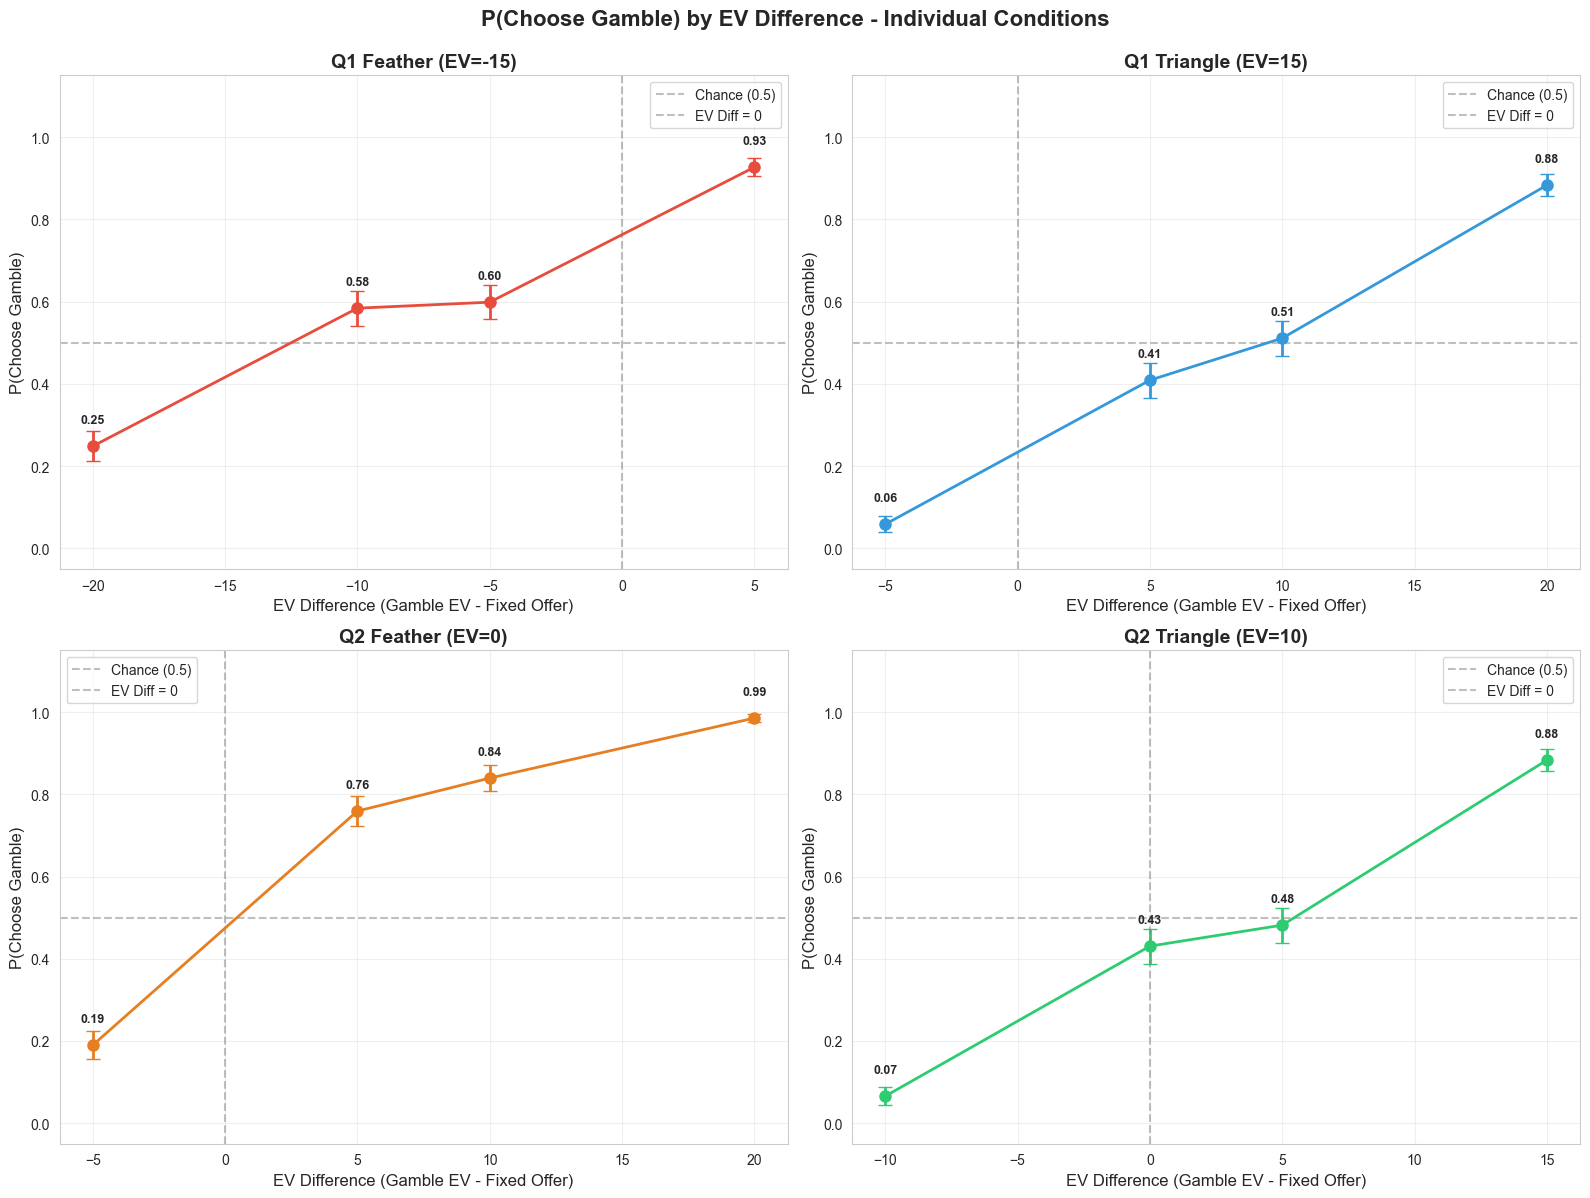

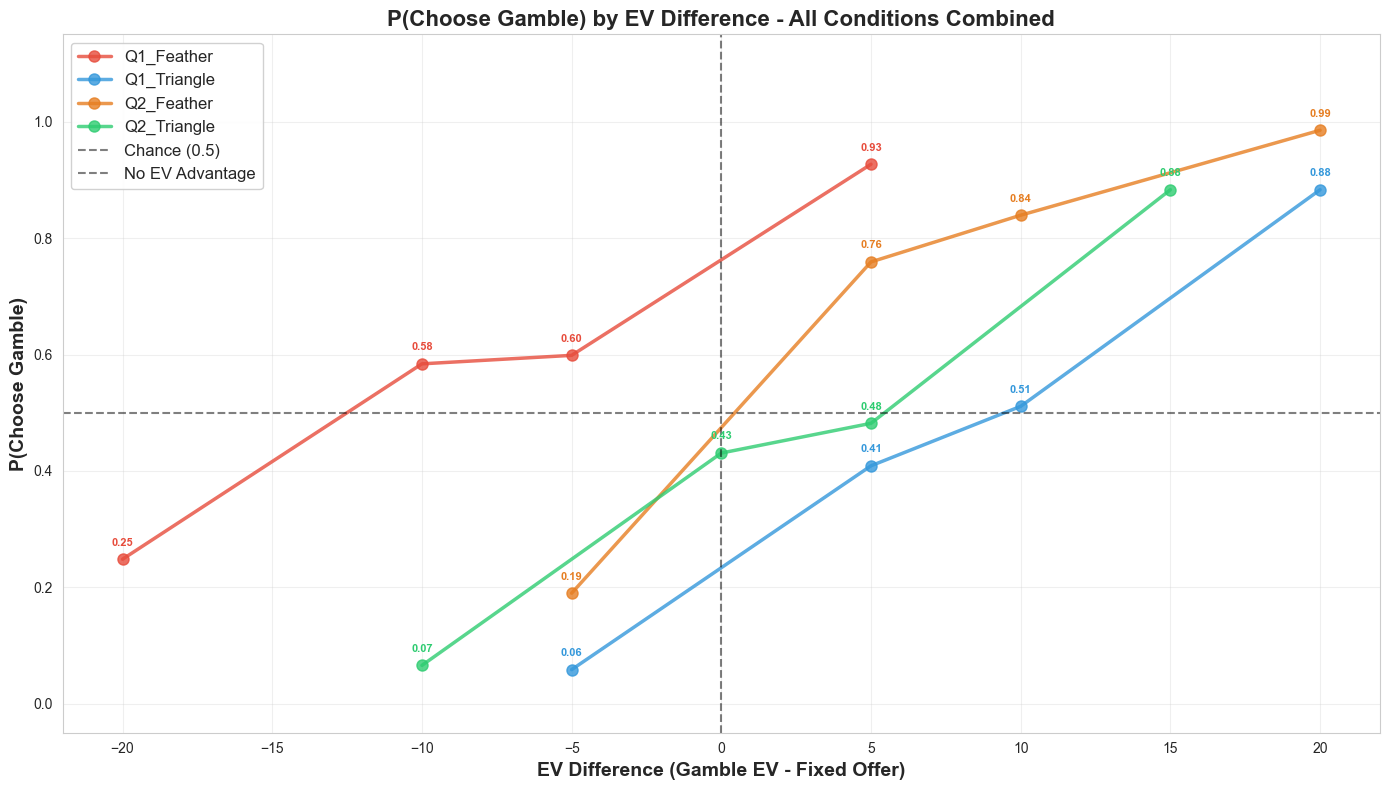

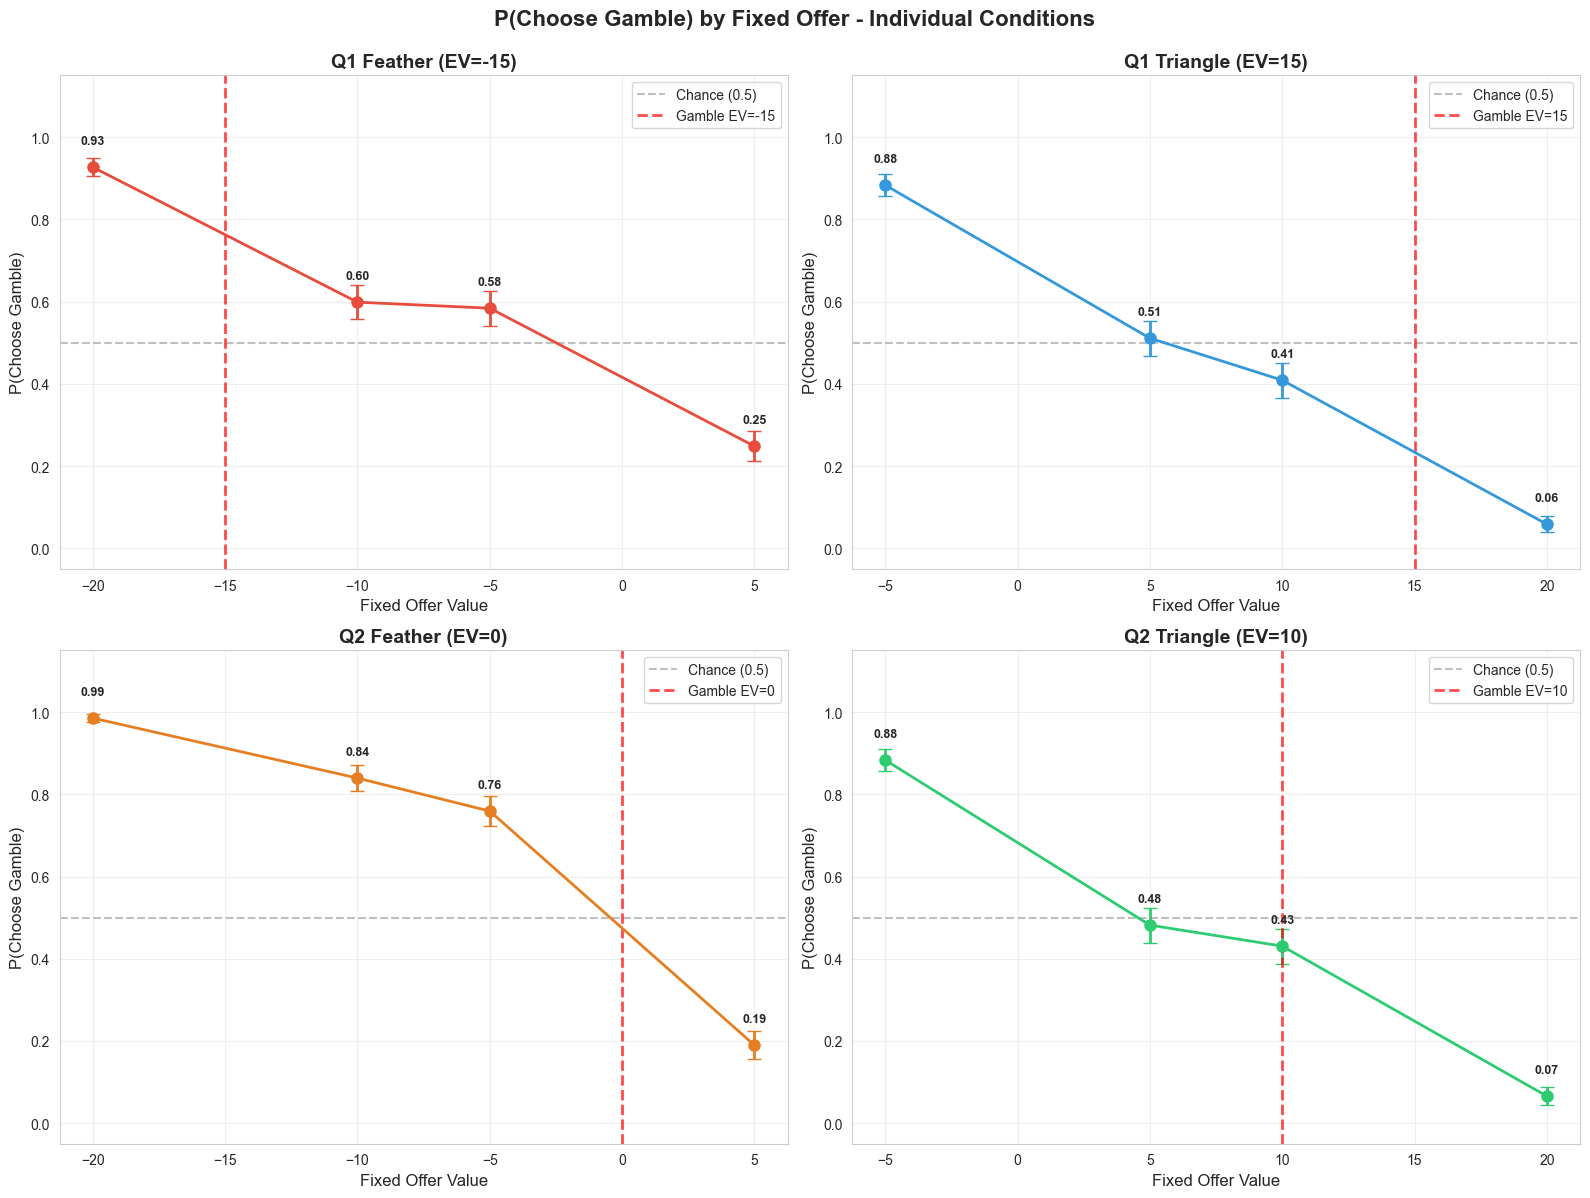

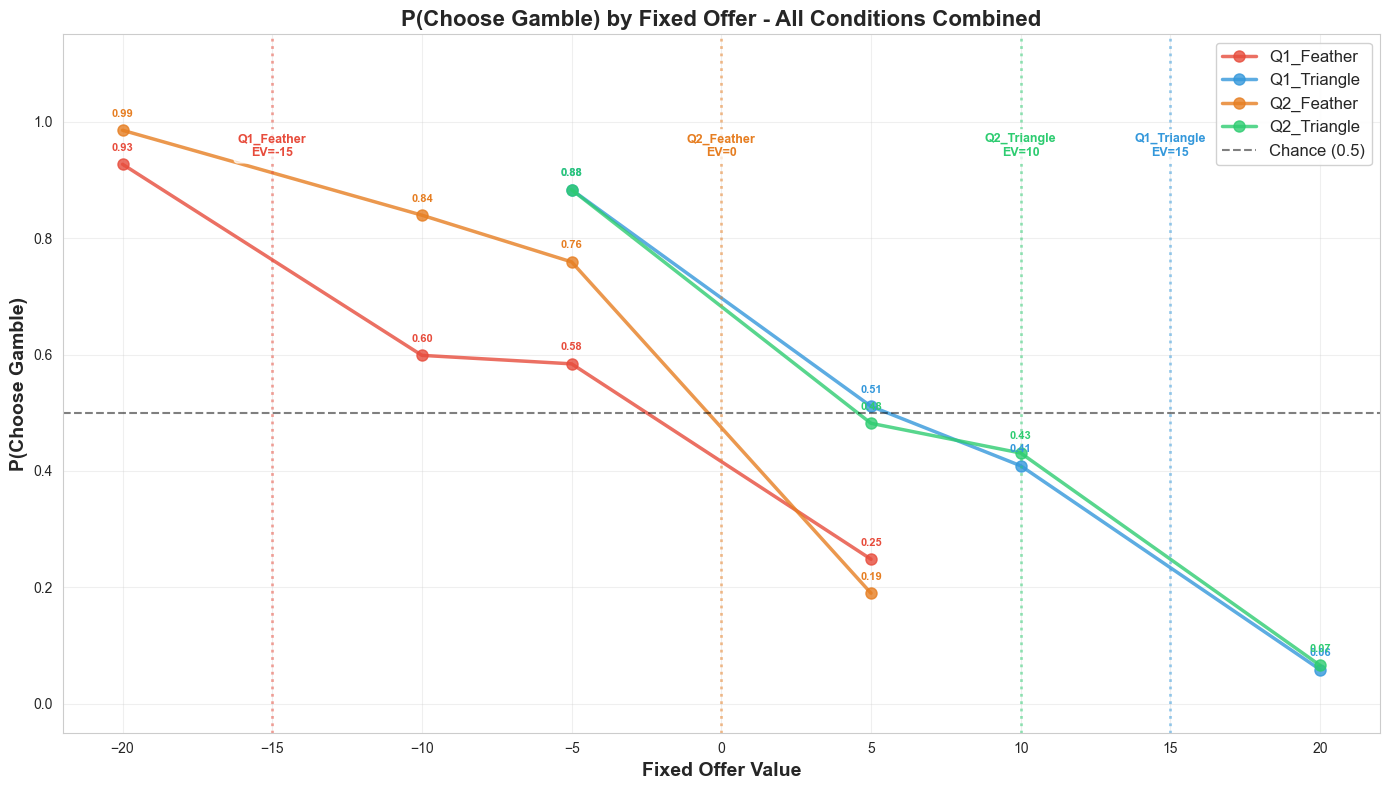

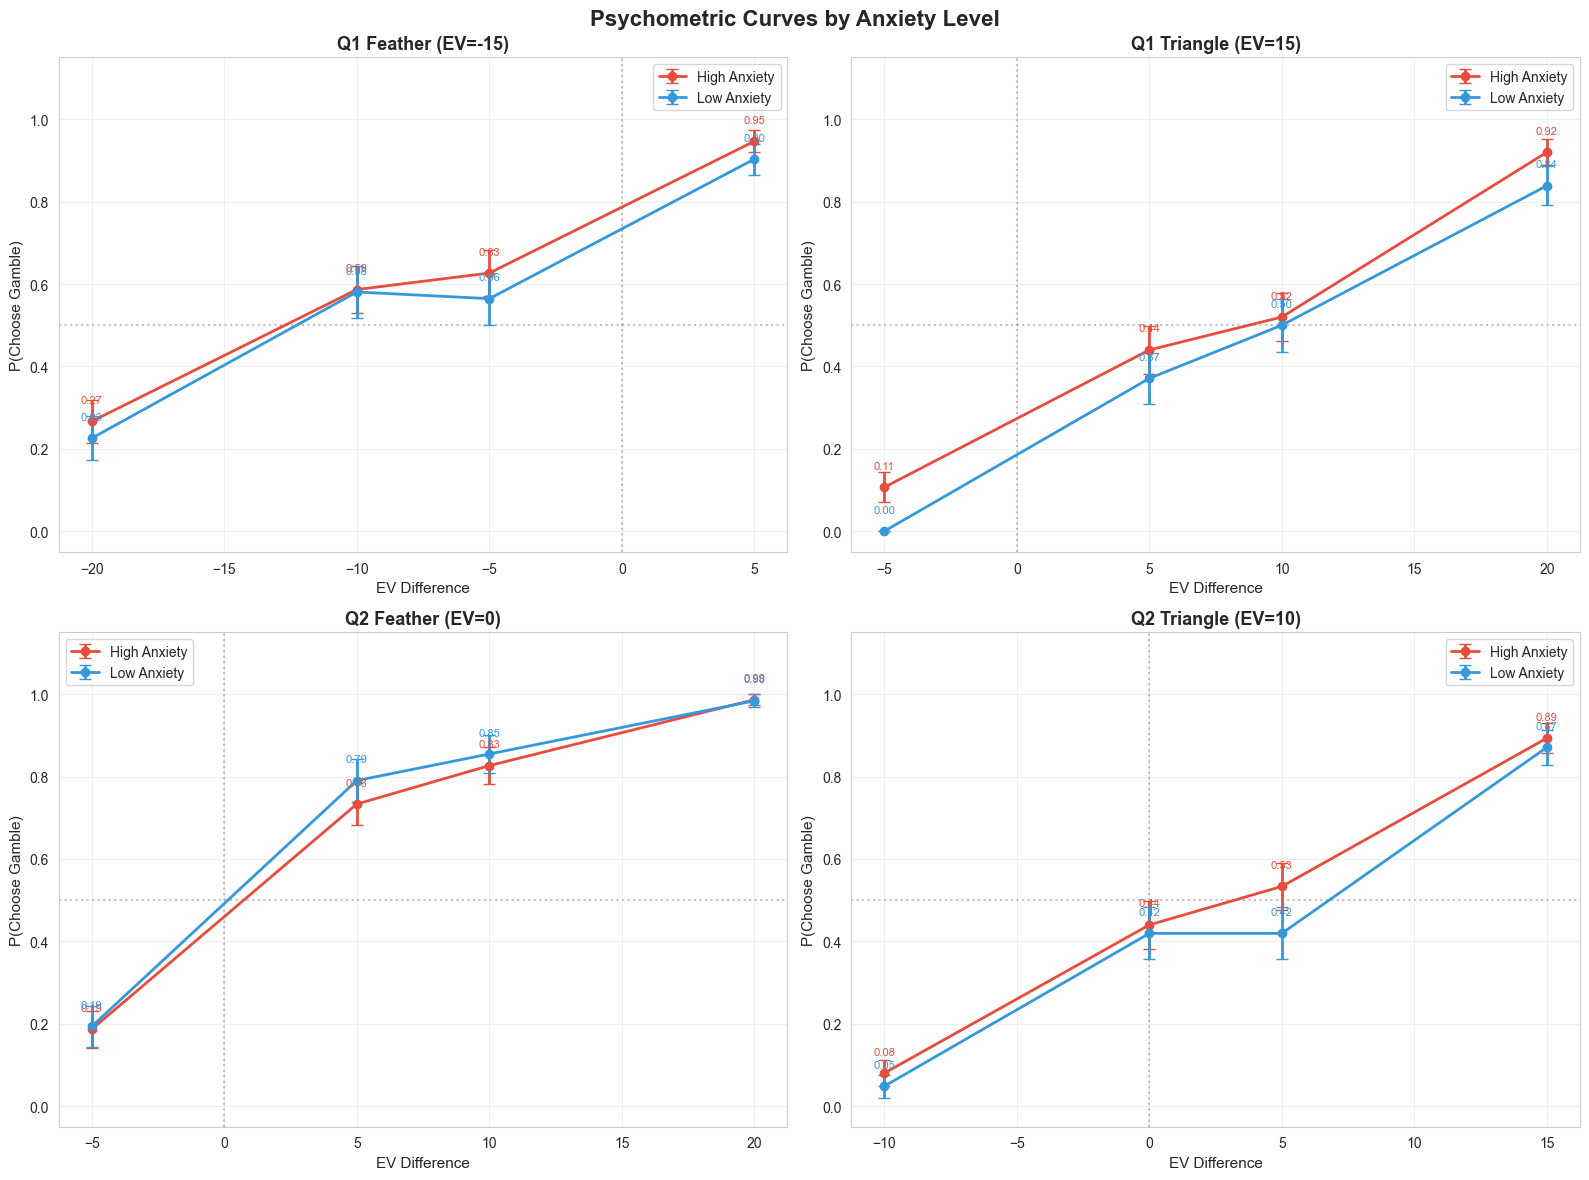

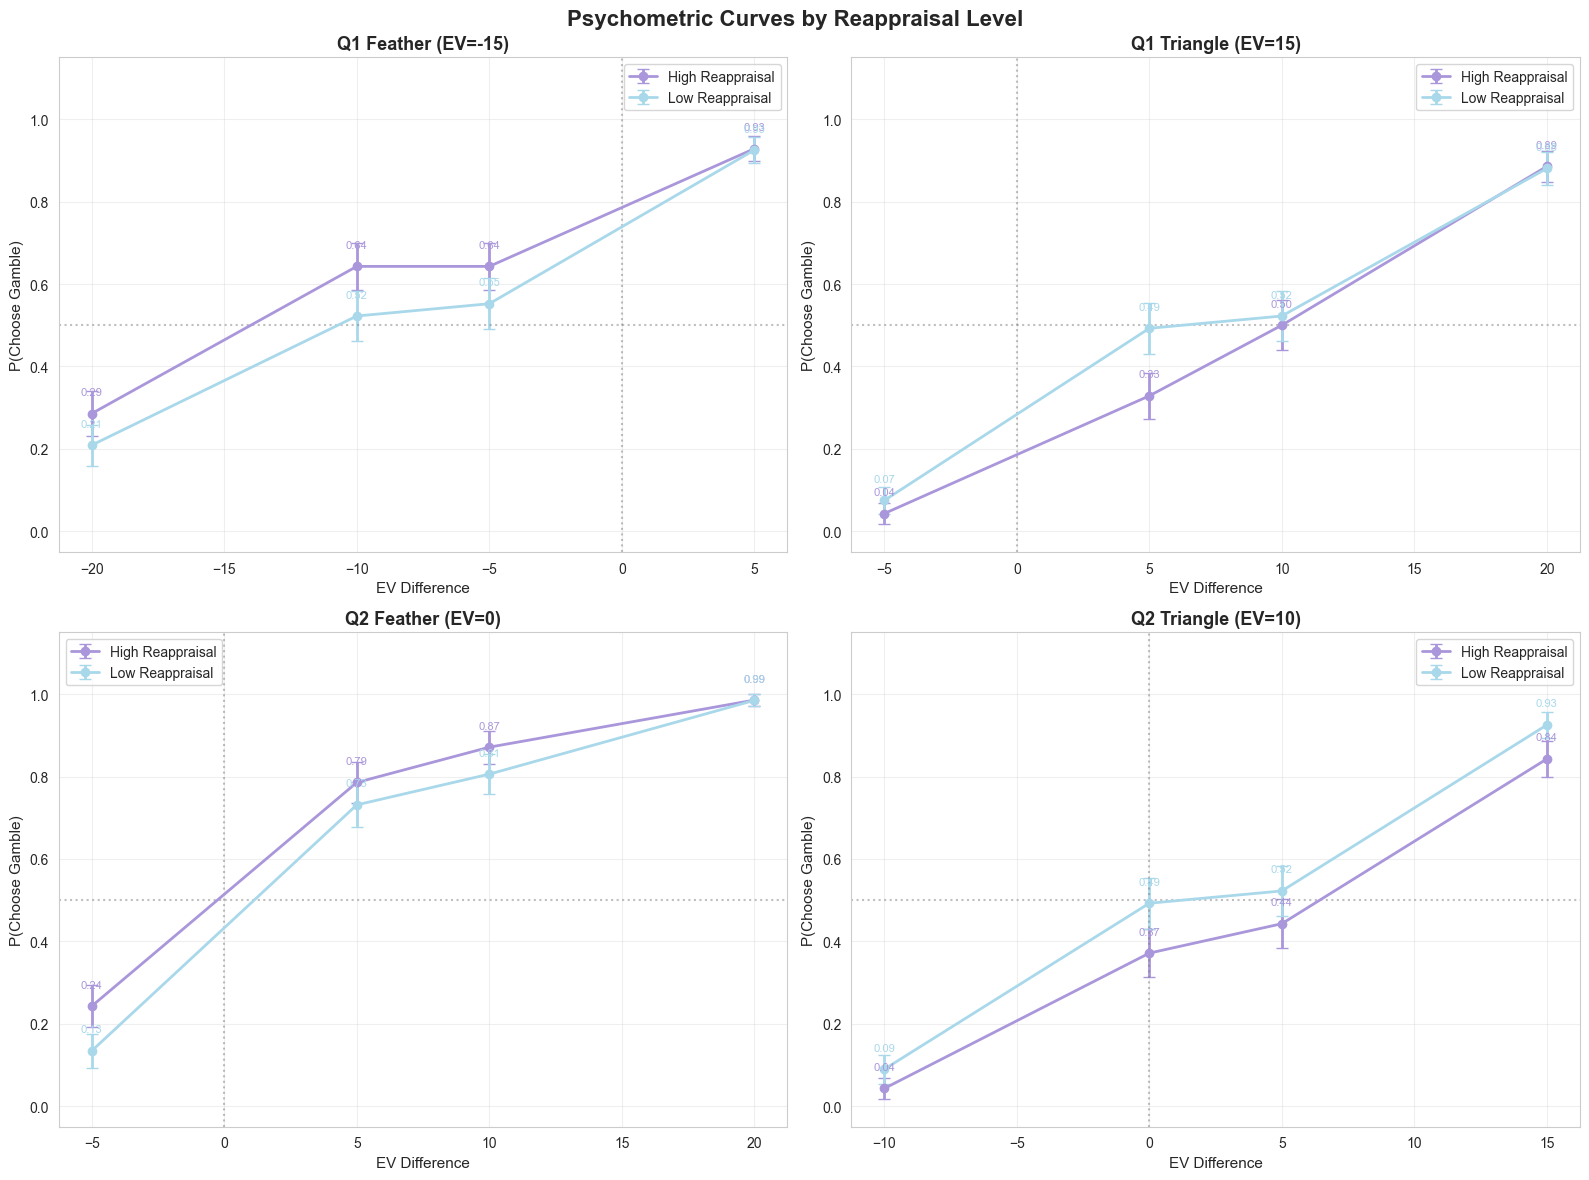

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_csv('filtered_data.csv')
print(f"Loaded {len(df)} subjects")

# ----------------------------------------------------------------------------
# 1. CALCULATE SCORES (Anxiety & ERQ)
# ----------------------------------------------------------------------------
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
median_anx = df['Anxiety_Total'].median()
df['Anxiety_Group'] = df['Anxiety_Total'].apply(lambda x: 'High Anxiety' if x >= median_anx else 'Low Anxiety')

erq_cols = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
            'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

if all(col in df.columns for col in erq_cols):
    df['ERQ_Reappraisal'] = df[erq_cols].sum(axis=1)
else:
    df['ERQ_Reappraisal'] = df.get('Survey_ERQ_Reappraisal_Score', np.nan)

median_erq = df['ERQ_Reappraisal'].median()
df['ERQ_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High Reappraisal' if x >= median_erq else 'Low Reappraisal')

print(f"Median Anxiety: {median_anx}")
print(f"Median ERQ: {median_erq}")

# ----------------------------------------------------------------------------
# 2. PREPARE LONG FORMAT DATA
# ----------------------------------------------------------------------------
long_data = []

for idx, row in df.iterrows():
    subj_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anx_group = row['Anxiety_Group']
    erq = row['ERQ_Reappraisal']
    erq_group = row['ERQ_Group']

    for query_num in [1, 2]:
        for trial_num in range(1, 9):
            trial_col_prefix = f'Query_{query_num}_T{trial_num}'
            choice = row.get(f'{trial_col_prefix}_Choice', np.nan)
            state = row.get(f'{trial_col_prefix}_State', np.nan)
            fixed_offer = row.get(f'{trial_col_prefix}_FixedOffer', np.nan)

            if pd.isna(choice) or pd.isna(state) or pd.isna(fixed_offer):
                continue

            query_type = f"Q{query_num}_{state}"

            ev_dict = {
                (1, 'Feather'): -15, (2, 'Feather'): 0,
                (1, 'Triangle'): 15, (2, 'Triangle'): 10
            }
            ev = ev_dict.get((query_num, state), np.nan)

            ev_difference = ev - fixed_offer
            chose_gamble = int(choice)

            long_data.append({
                'subject_id': subj_id,
                'Anxiety_Total': anxiety,
                'Anxiety_Group': anx_group,
                'ERQ_Reappraisal': erq,
                'ERQ_Group': erq_group,
                'query_num': query_num,
                'state': state,
                'ev': ev,
                'query_type': query_type,
                'ev_difference': ev_difference,
                'chose_gamble': chose_gamble,
                'fixed_offer': fixed_offer
            })

long_df = pd.DataFrame(long_data)
print(f"Total trials: {len(long_df)}")

# ----------------------------------------------------------------------------
# 3. AGGREGATE DATA FOR PLOTTING
# ----------------------------------------------------------------------------
# By EV Difference
choice_by_evdiff = long_df.groupby(['query_type', 'ev_difference']).agg(
    p_gamble=('chose_gamble', 'mean'),
    n_trials=('chose_gamble', 'count'),
    se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

# By Fixed Offer
choice_by_offer = long_df.groupby(['query_type', 'fixed_offer']).agg(
    p_gamble=('chose_gamble', 'mean'),
    n_trials=('chose_gamble', 'count'),
    se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

query_types = ['Q1_Feather', 'Q1_Triangle', 'Q2_Feather', 'Q2_Triangle']
colors = {
    'Q1_Feather': '#e74c3c',    # Red
    'Q1_Triangle': '#3498db',   # Blue
    'Q2_Feather': '#e67e22',    # Orange
    'Q2_Triangle': '#2ecc71'    # Green
}

# ----------------------------------------------------------------------------
# 4. FIGURE 1: INDIVIDUAL PLOTS WITH EXACT VALUES (BY EV DIFFERENCE)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, qt in enumerate(query_types):
    ax = axes[i]
    subset = choice_by_evdiff[choice_by_evdiff['query_type'] == qt].sort_values('ev_difference')

    if len(subset) > 0:
        # Plot line with error bars
        ax.errorbar(subset['ev_difference'], subset['p_gamble'], yerr=subset['se'], 
                   fmt='o-', color=colors[qt], linewidth=2, markersize=8, capsize=5)

        # Add exact values as text labels
        for _, row in subset.iterrows():
            ax.text(row['ev_difference'], row['p_gamble'] + 0.05, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Extract query details
    query_num = qt.split('_')[0]
    state = qt.split('_')[1]
    ev_val = long_df[long_df['query_type'] == qt]['ev'].iloc[0]

    # Add reference lines
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='EV Diff = 0')

    # Styling
    ax.set_title(f'{query_num} {state} (EV={ev_val})', fontsize=14, fontweight='bold')
    ax.set_xlabel('EV Difference (Gamble EV - Fixed Offer)', fontsize=12)
    ax.set_ylabel('P(Choose Gamble)', fontsize=12)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.suptitle('P(Choose Gamble) by EV Difference - Individual Conditions', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('p_gamble_evdiff_detailed.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_evdiff_detailed.png")

# ----------------------------------------------------------------------------
# 5. FIGURE 2: COMBINED PLOT - ALL CONDITIONS (BY EV DIFFERENCE)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for qt in query_types:
    subset = choice_by_evdiff[choice_by_evdiff['query_type'] == qt].sort_values('ev_difference')

    if len(subset) > 0:
        # Plot line
        ax.plot(subset['ev_difference'], subset['p_gamble'], 
               'o-', color=colors[qt], linewidth=2.5, markersize=8, 
               label=qt, alpha=0.8)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['ev_difference'], row['p_gamble'] + 0.02, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=8, 
                   color=colors[qt], fontweight='bold')

# Reference lines
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (0.5)')
ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='No EV Advantage')

# Styling
ax.set_xlabel('EV Difference (Gamble EV - Fixed Offer)', fontsize=14, fontweight='bold')
ax.set_ylabel('P(Choose Gamble)', fontsize=14, fontweight='bold')
ax.set_title('P(Choose Gamble) by EV Difference - All Conditions Combined', 
            fontsize=16, fontweight='bold')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.savefig('p_gamble_evdiff_combined.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_evdiff_combined.png")

# ----------------------------------------------------------------------------
# 6. FIGURE 3: INDIVIDUAL PLOTS WITH EXACT VALUES (BY FIXED OFFER)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, qt in enumerate(query_types):
    ax = axes[i]
    subset = choice_by_offer[choice_by_offer['query_type'] == qt].sort_values('fixed_offer')

    if len(subset) > 0:
        # Plot line with error bars
        ax.errorbar(subset['fixed_offer'], subset['p_gamble'], yerr=subset['se'], 
                   fmt='o-', color=colors[qt], linewidth=2, markersize=8, capsize=5)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['fixed_offer'], row['p_gamble'] + 0.05, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Extract query details
    query_num = qt.split('_')[0]
    state = qt.split('_')[1]
    ev_val = long_df[long_df['query_type'] == qt]['ev'].iloc[0]

    # Add reference lines
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')
    ax.axvline(ev_val, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Gamble EV={ev_val}')

    # Styling
    ax.set_title(f'{query_num} {state} (EV={ev_val})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Fixed Offer Value', fontsize=12)
    ax.set_ylabel('P(Choose Gamble)', fontsize=12)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.suptitle('P(Choose Gamble) by Fixed Offer - Individual Conditions', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('p_gamble_offer_detailed.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_offer_detailed.png")

# ----------------------------------------------------------------------------
# 7. FIGURE 4: COMBINED PLOT - ALL CONDITIONS (BY FIXED OFFER)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for qt in query_types:
    subset = choice_by_offer[choice_by_offer['query_type'] == qt].sort_values('fixed_offer')

    if len(subset) > 0:
        # Plot line
        ax.plot(subset['fixed_offer'], subset['p_gamble'], 
               'o-', color=colors[qt], linewidth=2.5, markersize=8, 
               label=qt, alpha=0.8)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['fixed_offer'], row['p_gamble'] + 0.02, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=8, 
                   color=colors[qt], fontweight='bold')

# Add vertical lines for each EV
ev_lines = {
    'Q1_Feather': -15,
    'Q1_Triangle': 15,
    'Q2_Feather': 0,
    'Q2_Triangle': 10
}
for qt, ev in ev_lines.items():
    ax.axvline(ev, color=colors[qt], linestyle=':', alpha=0.5, linewidth=2)
    ax.text(ev, 0.98, f'{qt}\nEV={ev}', ha='center', va='top', 
           fontsize=9, color=colors[qt], fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Reference line
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (0.5)')

# Styling
ax.set_xlabel('Fixed Offer Value', fontsize=14, fontweight='bold')
ax.set_ylabel('P(Choose Gamble)', fontsize=14, fontweight='bold')
ax.set_title('P(Choose Gamble) by Fixed Offer - All Conditions Combined', 
            fontsize=16, fontweight='bold')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.savefig('p_gamble_offer_combined.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_offer_combined.png")

# ----------------------------------------------------------------------------
# 8. STATISTICAL ANALYSIS: CORRELATIONS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL ANALYSIS: FIXED OFFER vs P(GAMBLE)")
print("Pearson Correlation between Fixed Offer Value and Gambling Probability")
print("="*80)

conditions = long_df[['query_num', 'state', 'ev', 'query_type']].drop_duplicates().sort_values('query_type')
print(f"{'Query Type':<15} | {'EV':<5} | {'Pearson r':<10} | {'p-value':<10} | {'N Offers':<8}")
print("-" * 65)

for _, cond in conditions.iterrows():
    qt = cond['query_type']
    ev_val = cond['ev']

    subset = long_df[long_df['query_type'] == qt]
    offer_stats = subset.groupby('fixed_offer')['chose_gamble'].agg(['mean', 'count']).reset_index()
    offer_stats.rename(columns={'mean': 'p_gamble'}, inplace=True)

    if len(offer_stats) > 1:
        r, p = stats.pearsonr(offer_stats['fixed_offer'], offer_stats['p_gamble'])
        print(f"{qt:<15} | {ev_val:<5} | {r:<10.3f} | {p:<10.4f} | {len(offer_stats):<8}")
    else:
        print(f"{qt:<15} | {ev_val:<5} | {'NaN':<10} | {'NaN':<10} | {len(offer_stats):<8}")

# ----------------------------------------------------------------------------
# 9. LOGISTIC REGRESSION WITH INTERACTIONS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL ANALYSIS: TRAIT INTERACTIONS")
print("Model: Logit(P_Gamble) ~ EV_Diff * Trait")
print("="*80)

def analyze_interaction(data, trait_col, trait_name, label):
    print(f"\n>>> {label} : {trait_name} <<<")

    if trait_col not in data.columns:
        print(f"  Error: Column '{trait_col}' not found.")
        return

    data['trait_z'] = (data[trait_col] - data[trait_col].mean()) / data[trait_col].std()
    formula = "chose_gamble ~ ev_difference * trait_z"

    try:
        model = smf.logit(formula, data=data).fit(disp=0)
        print(model.summary2().tables[1])

        params = model.params
        pvals = model.pvalues
        sig_threshold = 0.05

        if pvals['trait_z'] < sig_threshold:
            direction = "INCREASES" if params['trait_z'] > 0 else "DECREASES"
            print(f"  * SIGNIFICANT MAIN EFFECT: Higher {trait_name} {direction} overall gambling rate.")

        if pvals['ev_difference:trait_z'] < sig_threshold:
            direction = "STEEPER" if params['ev_difference:trait_z'] > 0 else "FLATTER"
            print(f"  * SIGNIFICANT INTERACTION: Higher {trait_name} makes curve {direction}.")

    except Exception as e:
        print(f"  Error: {e}")

for qt in query_types:
    subset = long_df[long_df['query_type'] == qt].copy()
    analyze_interaction(subset, 'Anxiety_Total', 'Anxiety', f"{qt}")
    analyze_interaction(subset, 'ERQ_Reappraisal', 'ERQ', f"{qt}")

# ----------------------------------------------------------------------------
# 10. PSYCHOMETRIC CURVES BY GROUP
# ----------------------------------------------------------------------------
def plot_psychometric_group(data, group_col, title_suffix, filename):
    if group_col not in data.columns:
        print(f"Error: Column '{group_col}' not found.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    groups = sorted(data[group_col].unique())
    if 'Anxiety' in group_col:
        palette = {'Low Anxiety': '#3498DB', 'High Anxiety': '#E74C3C'}
    else:
        palette = {'Low Reappraisal': '#A8D8EA', 'High Reappraisal': '#AA96DA'}

    for i, qt in enumerate(query_types):
        ax = axes[i]
        qt_data = data[data['query_type'] == qt]

        # Group stats
        group_stats = qt_data.groupby([group_col, 'ev_difference']).agg(
            p_gamble=('chose_gamble', 'mean'),
            se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)))
        ).reset_index()

        # Plot for each group
        for grp in groups:
            grp_stats = group_stats[group_stats[group_col] == grp].sort_values('ev_difference')
            if len(grp_stats) > 0:
                ax.errorbar(grp_stats['ev_difference'], grp_stats['p_gamble'], 
                           yerr=grp_stats['se'], fmt='o-', color=palette[grp],
                           label=grp, linewidth=2, markersize=6, capsize=4)

                # Add values
                for _, row in grp_stats.iterrows():
                    ax.text(row['ev_difference'], row['p_gamble'] + 0.04, 
                           f"{row['p_gamble']:.2f}", 
                           ha='center', va='bottom', fontsize=8, color=palette[grp])

        # Extract details
        query_num = qt.split('_')[0]
        state = qt.split('_')[1]
        ev_val = qt_data['ev'].iloc[0]

        ax.set_title(f'{query_num} {state} (EV={ev_val})', fontsize=13, fontweight='bold')
        ax.set_xlabel('EV Difference', fontsize=11)
        ax.set_ylabel('P(Choose Gamble)', fontsize=11)
        ax.set_ylim(-0.05, 1.15)
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
        ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=10)

    plt.suptitle(f'Psychometric Curves by {title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {filename}")

plot_psychometric_group(long_df, 'Anxiety_Group', 'Anxiety Level', 'curves_anxiety.png')
plot_psychometric_group(long_df, 'ERQ_Group', 'Reappraisal Level', 'curves_erq.png')

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!")
print("="*80)

---
# Section 8: Value-Choice Consistency Analysis

VALUE-CHOICE CONSISTENCY ANALYSIS

Sample size: 137

Consistency Scores (Mean +/- SEM):
  q1_feather: 0.823 +/- 0.019
  q1_triangle: 0.801 +/- 0.020
  q2_feather: 0.881 +/- 0.016
  q2_triangle: 0.825 +/- 0.020
  q1_total: 0.812 +/- 0.017
  q2_total: 0.853 +/- 0.014
  overall: 0.833 +/- 0.013

--- WORRY Correlations ---
  q1_feather: r=0.134, p=0.1197 
  q1_triangle: r=0.026, p=0.7662 
  q2_feather: r=-0.207, p=0.0153 *
  q2_triangle: r=-0.231, p=0.0067 **
  q1_total: r=0.079, p=0.3606 
  q2_total: r=-0.273, p=0.0012 **
  overall: r=-0.086, p=0.3160 

--- ERQ-REAPPRAISAL Correlations ---
  q1_feather: r=-0.087, p=0.3107 
  q1_triangle: r=0.013, p=0.8801 
  q2_feather: r=0.115, p=0.1797 
  q2_triangle: r=0.126, p=0.1436 
  q1_total: r=-0.060, p=0.4858 
  q2_total: r=0.112, p=0.1924 
  overall: r=0.026, p=0.7595 

--- WORRY GROUPS ---
  q1_feather: Low=0.786, High=0.853, p=0.0856 
  q1_triangle: Low=0.782, High=0.817, p=0.3878 
  q2_feather: Low=0.899, High=0.867, p=0.3129 
  q2_triangle:

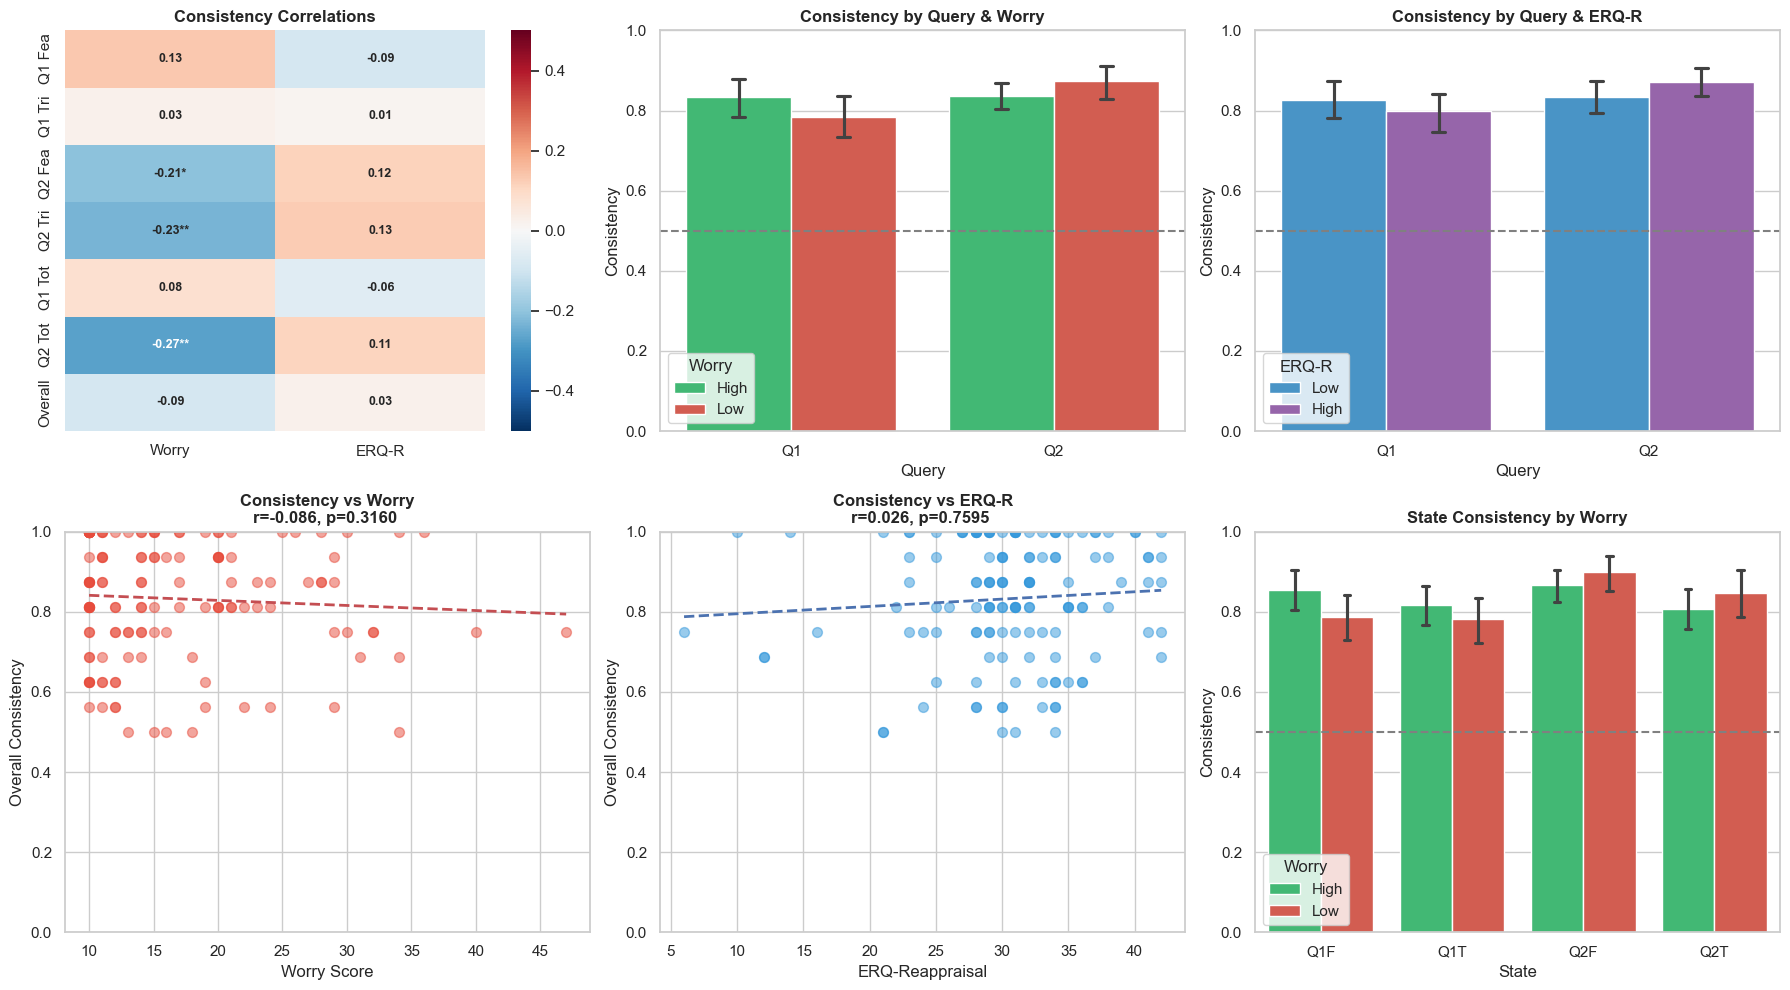

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, ttest_ind

print("="*80)
print("VALUE-CHOICE CONSISTENCY ANALYSIS")
print("="*80)

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['Anxiety_Group'] = df['Anxiety_Total'].apply(lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low')
df['ERQ_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low')

print(f"\nSample size: {len(df)}")

consistency_data = []
for idx, row in df.iterrows():
    subject_id = row['subject_id']
    counters = {k: {'consistent': 0, 'total': 0} for k in ['q1_feather', 'q1_triangle', 'q2_feather', 'q2_triangle']}
    
    q1_feather_rating = row['Rating_2_Feather_Val']
    q1_triangle_rating = row['Rating_2_Triangle_Val']
    q2_feather_rating = row['Rating_3_Feather_Val']
    q2_triangle_rating = row['Rating_3_Triangle_Val']
    
    for query_num, ratings in [(1, {'Feather': q1_feather_rating, 'Triangle': q1_triangle_rating}),
                               (2, {'Feather': q2_feather_rating, 'Triangle': q2_triangle_rating})]:
        for trial in range(1, 21):
            state_col = f'Query_{query_num}_T{trial}_State'
            offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
            choice_col = f'Query_{query_num}_T{trial}_Choice'
            
            if state_col not in row.index or pd.isna(row[state_col]):
                break
            state = row[state_col]
            offer = row[offer_col]
            choice = row[choice_col]
            if pd.isna(choice):
                break
            rating = ratings[state]
            expected_choice = 1 if rating > offer else (0 if rating < offer else choice)
            is_consistent = (choice == expected_choice)
            key = f'q{query_num}_{state.lower()}'
            counters[key]['consistent'] += is_consistent
            counters[key]['total'] += 1
    
    def calc_prop(key):
        return counters[key]['consistent'] / counters[key]['total'] if counters[key]['total'] > 0 else np.nan
    
    q1_total = (counters['q1_feather']['consistent'] + counters['q1_triangle']['consistent']) / (counters['q1_feather']['total'] + counters['q1_triangle']['total']) if (counters['q1_feather']['total'] + counters['q1_triangle']['total']) > 0 else np.nan
    q2_total = (counters['q2_feather']['consistent'] + counters['q2_triangle']['consistent']) / (counters['q2_feather']['total'] + counters['q2_triangle']['total']) if (counters['q2_feather']['total'] + counters['q2_triangle']['total']) > 0 else np.nan
    overall = sum(c['consistent'] for c in counters.values()) / sum(c['total'] for c in counters.values()) if sum(c['total'] for c in counters.values()) > 0 else np.nan
    
    consistency_data.append({
        'subject_id': subject_id, 'anxiety': row['Anxiety_Total'], 'anxiety_group': row['Anxiety_Group'],
        'erq_reappraisal': row['ERQ_Reappraisal'], 'erq_group': row['ERQ_Group'],
        'q1_feather': calc_prop('q1_feather'), 'q1_triangle': calc_prop('q1_triangle'),
        'q2_feather': calc_prop('q2_feather'), 'q2_triangle': calc_prop('q2_triangle'),
        'q1_total': q1_total, 'q2_total': q2_total, 'overall': overall
    })

consistency_df = pd.DataFrame(consistency_data)

measures = ['q1_feather', 'q1_triangle', 'q2_feather', 'q2_triangle', 'q1_total', 'q2_total', 'overall']

print("\nConsistency Scores (Mean +/- SEM):")
for var in measures:
    data = consistency_df[var].dropna()
    print(f"  {var}: {data.mean():.3f} +/- {stats.sem(data):.3f}")

corr_results = {'worry': {}, 'erq': {}}
group_results = {'worry': {}, 'erq': {}}

print("\n--- WORRY Correlations ---")
for m in measures:
    r, p = spearmanr(consistency_df[m].dropna(), consistency_df['anxiety'].dropna())
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    corr_results['worry'][m] = {'r': r, 'p': p, 'sig': sig}
    print(f"  {m}: r={r:.3f}, p={p:.4f} {sig}")

print("\n--- ERQ-REAPPRAISAL Correlations ---")
for m in measures:
    r, p = spearmanr(consistency_df[m].dropna(), consistency_df['erq_reappraisal'].dropna())
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    corr_results['erq'][m] = {'r': r, 'p': p, 'sig': sig}
    print(f"  {m}: r={r:.3f}, p={p:.4f} {sig}")

print("\n--- WORRY GROUPS ---")
for m in measures:
    low = consistency_df[consistency_df['anxiety_group']=='Low'][m].dropna()
    high = consistency_df[consistency_df['anxiety_group']=='High'][m].dropna()
    t, p = ttest_ind(low, high)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    group_results['worry'][m] = {'low': low.mean(), 'high': high.mean(), 't': t, 'p': p, 'sig': sig}
    print(f"  {m}: Low={low.mean():.3f}, High={high.mean():.3f}, p={p:.4f} {sig}")

print("\n--- ERQ-REAPPRAISAL GROUPS ---")
for m in measures:
    low = consistency_df[consistency_df['erq_group']=='Low'][m].dropna()
    high = consistency_df[consistency_df['erq_group']=='High'][m].dropna()
    t, p = ttest_ind(low, high)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    group_results['erq'][m] = {'low': low.mean(), 'high': high.mean(), 't': t, 'p': p, 'sig': sig}
    print(f"  {m}: Low={low.mean():.3f}, High={high.mean():.3f}, p={p:.4f} {sig}")

# VISUALIZATIONS
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel 1: Heatmap
ax = axes[0, 0]
corr_data = [[corr_results['worry'][m]['r'], corr_results['erq'][m]['r']] for m in measures]
corr_matrix = pd.DataFrame(corr_data, index=['Q1 Fea', 'Q1 Tri', 'Q2 Fea', 'Q2 Tri', 'Q1 Tot', 'Q2 Tot', 'Overall'], columns=['Worry', 'ERQ-R'])
annot = [[f"{corr_results['worry'][m]['r']:.2f}{corr_results['worry'][m]['sig']}", f"{corr_results['erq'][m]['r']:.2f}{corr_results['erq'][m]['sig']}"] for m in measures]
annot_df = pd.DataFrame(annot, index=corr_matrix.index, columns=corr_matrix.columns)
sns.heatmap(corr_matrix, annot=annot_df, fmt='', cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5, ax=ax, annot_kws={'fontsize': 9, 'fontweight': 'bold'})
ax.set_title('Consistency Correlations', fontweight='bold')

# Panel 2: Query by Worry
ax = axes[0, 1]
q_data = pd.DataFrame({'Query': ['Q1']*len(consistency_df) + ['Q2']*len(consistency_df), 'Worry': list(consistency_df['anxiety_group'])*2, 'Consistency': list(consistency_df['q1_total']) + list(consistency_df['q2_total'])})
sns.barplot(data=q_data, x='Query', y='Consistency', hue='Worry', ax=ax, palette=['#2ecc71', '#e74c3c'], capsize=0.1)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Consistency by Query & Worry', fontweight='bold')
ax.set_ylim([0, 1])
for i, q in enumerate(['q1_total', 'q2_total']):
    sig = group_results['worry'][q]['sig']
    if sig: ax.text(i, 0.92, f"p={group_results['worry'][q]['p']:.3f}{sig}", ha='center', fontsize=9, fontweight='bold')

# Panel 3: Query by ERQ
ax = axes[0, 2]
q_data = pd.DataFrame({'Query': ['Q1']*len(consistency_df) + ['Q2']*len(consistency_df), 'ERQ-R': list(consistency_df['erq_group'])*2, 'Consistency': list(consistency_df['q1_total']) + list(consistency_df['q2_total'])})
sns.barplot(data=q_data, x='Query', y='Consistency', hue='ERQ-R', ax=ax, palette=['#3498db', '#9b59b6'], capsize=0.1)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Consistency by Query & ERQ-R', fontweight='bold')
ax.set_ylim([0, 1])
for i, q in enumerate(['q1_total', 'q2_total']):
    sig = group_results['erq'][q]['sig']
    if sig: ax.text(i, 0.92, f"p={group_results['erq'][q]['p']:.3f}{sig}", ha='center', fontsize=9, fontweight='bold')

# Panel 4: Scatter Worry with trendline
ax = axes[1, 0]
x, y = consistency_df['anxiety'].dropna(), consistency_df['overall'].dropna()
ax.scatter(x, y, alpha=0.5, c='#e74c3c', s=50)
z = np.polyfit(x, y, 1)
ax.plot(np.linspace(x.min(), x.max(), 100), np.poly1d(z)(np.linspace(x.min(), x.max(), 100)), 'r--', linewidth=2)
r, p, sig = corr_results['worry']['overall']['r'], corr_results['worry']['overall']['p'], corr_results['worry']['overall']['sig']
ax.set_xlabel('Worry Score')
ax.set_ylabel('Overall Consistency')
ax.set_title(f'Consistency vs Worry\nr={r:.3f}, p={p:.4f} {sig}', fontweight='bold')
ax.set_ylim([0, 1])

# Panel 5: Scatter ERQ with trendline
ax = axes[1, 1]
x, y = consistency_df['erq_reappraisal'].dropna(), consistency_df['overall'].dropna()
ax.scatter(x, y, alpha=0.5, c='#3498db', s=50)
z = np.polyfit(x, y, 1)
ax.plot(np.linspace(x.min(), x.max(), 100), np.poly1d(z)(np.linspace(x.min(), x.max(), 100)), 'b--', linewidth=2)
r, p, sig = corr_results['erq']['overall']['r'], corr_results['erq']['overall']['p'], corr_results['erq']['overall']['sig']
ax.set_xlabel('ERQ-Reappraisal')
ax.set_ylabel('Overall Consistency')
ax.set_title(f'Consistency vs ERQ-R\nr={r:.3f}, p={p:.4f} {sig}', fontweight='bold')
ax.set_ylim([0, 1])

# Panel 6: State-specific
ax = axes[1, 2]
state_data = pd.DataFrame({'State': ['Q1F']*len(consistency_df) + ['Q1T']*len(consistency_df) + ['Q2F']*len(consistency_df) + ['Q2T']*len(consistency_df), 'Worry': list(consistency_df['anxiety_group'])*4, 'Consistency': list(consistency_df['q1_feather']) + list(consistency_df['q1_triangle']) + list(consistency_df['q2_feather']) + list(consistency_df['q2_triangle'])})
sns.barplot(data=state_data, x='State', y='Consistency', hue='Worry', ax=ax, palette=['#2ecc71', '#e74c3c'], capsize=0.1)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('State Consistency by Worry', fontweight='bold')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('consistency_analysis.png', dpi=150)
print("\nSaved: consistency_analysis.png")
plt.show()

consistency_df.to_csv('value_choice_consistency.csv', index=False)

---
# Section 9: Response Time Analysis

RESPONSE TIME ANALYSIS
Total RT observations: 2192

Descriptive Statistics:
  Q1_Feather: M=4361ms +/- 180ms
  Q1_Triangle: M=4308ms +/- 201ms
  Q2_Feather: M=3683ms +/- 226ms
  Q2_Triangle: M=3120ms +/- 154ms

--- WORRY Correlations ---
  Q1_Feather: r=0.104, p=0.2270 
  Q1_Triangle: r=0.096, p=0.2669 
  Q2_Feather: r=0.105, p=0.2229 
  Q2_Triangle: r=0.147, p=0.0859 

--- ERQ-R Correlations ---
  Q1_Feather: r=0.001, p=0.9909 
  Q1_Triangle: r=-0.062, p=0.4696 
  Q2_Feather: r=-0.139, p=0.1041 
  Q2_Triangle: r=-0.093, p=0.2816 

--- BY WORRY GROUP ---
  Q1_Feather: Low=4165ms, High=4522ms, p=0.3254 
  Q1_Triangle: Low=4021ms, High=4545ms, p=0.1943 
  Q2_Feather: Low=3324ms, High=3979ms, p=0.1489 
  Q2_Triangle: Low=2674ms, High=3489ms, p=0.0081 **

--- BY ERQ-R GROUP ---
  Q1_Feather: Low=4492ms, High=4236ms, p=0.4794 
  Q1_Triangle: Low=4687ms, High=3945ms, p=0.0644 
  Q2_Feather: Low=4199ms, High=3189ms, p=0.0247 *
  Q2_Triangle: Low=3374ms, High=2878ms, p=0.1085 

Saved: rt_analy

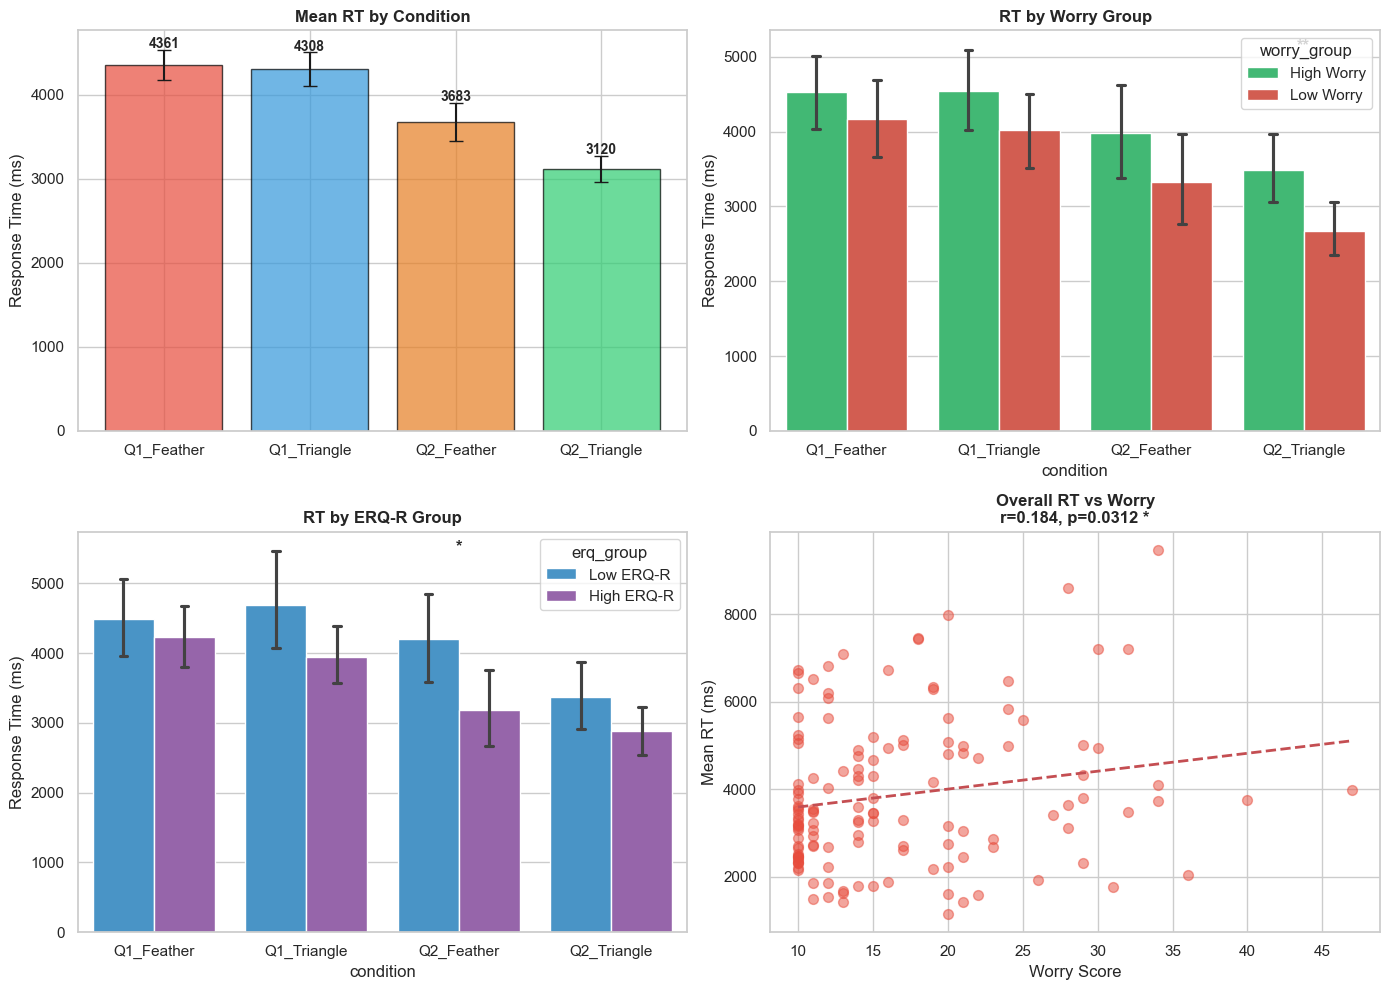

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['Worry_Group'] = df['Anxiety_Total'].apply(lambda x: 'High Worry' if x >= df['Anxiety_Total'].median() else 'Low Worry')
df['ERQ_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High ERQ-R' if x >= df['ERQ_Reappraisal'].median() else 'Low ERQ-R')

print("="*80)
print("RESPONSE TIME ANALYSIS")
print("="*80)

rt_data = []
for idx, row in df.iterrows():
    for query_num in [1, 2]:
        for trial in range(1, 9):
            state_col = f'Query_{query_num}_T{trial}_State'
            rt_col = f'Query_{query_num}_T{trial}_RT'
            if state_col in row.index and rt_col in row.index:
                state = row.get(state_col)
                rt = row.get(rt_col)
                if not pd.isna(state) and not pd.isna(rt) and rt > 0:
                    rt_data.append({'subject_id': row['subject_id'], 'anxiety': row['Anxiety_Total'], 'erq_reappraisal': row['ERQ_Reappraisal'], 'worry_group': row['Worry_Group'], 'erq_group': row['ERQ_Group'], 'condition': f'Q{query_num}_{state}', 'rt': rt, 'log_rt': np.log(rt)})

rt_df = pd.DataFrame(rt_data)
print(f"Total RT observations: {len(rt_df)}")

subject_rt = rt_df.groupby(['subject_id', 'condition']).agg({'rt': 'mean', 'log_rt': 'mean', 'anxiety': 'first', 'erq_reappraisal': 'first', 'worry_group': 'first', 'erq_group': 'first'}).reset_index()

condition_order = ['Q1_Feather', 'Q1_Triangle', 'Q2_Feather', 'Q2_Triangle']
condition_stats = {}
rt_corr = {'worry': {}, 'erq': {}}
rt_groups = {'worry': {}, 'erq': {}}

print("\nDescriptive Statistics:")
for cond in condition_order:
    subset = subject_rt[subject_rt['condition'] == cond]
    condition_stats[cond] = {'mean': subset['rt'].mean(), 'sem': stats.sem(subset['rt'])}
    print(f"  {cond}: M={subset['rt'].mean():.0f}ms +/- {stats.sem(subset['rt']):.0f}ms")

print("\n--- WORRY Correlations ---")
for cond in condition_order:
    subset = subject_rt[subject_rt['condition'] == cond]
    r, p = pearsonr(subset['log_rt'], subset['anxiety'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    rt_corr['worry'][cond] = {'r': r, 'p': p, 'sig': sig}
    print(f"  {cond}: r={r:.3f}, p={p:.4f} {sig}")

print("\n--- ERQ-R Correlations ---")
for cond in condition_order:
    subset = subject_rt[subject_rt['condition'] == cond]
    r, p = pearsonr(subset['log_rt'], subset['erq_reappraisal'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    rt_corr['erq'][cond] = {'r': r, 'p': p, 'sig': sig}
    print(f"  {cond}: r={r:.3f}, p={p:.4f} {sig}")

print("\n--- BY WORRY GROUP ---")
for cond in condition_order:
    low = subject_rt[(subject_rt['condition'] == cond) & (subject_rt['worry_group'] == 'Low Worry')]['rt']
    high = subject_rt[(subject_rt['condition'] == cond) & (subject_rt['worry_group'] == 'High Worry')]['rt']
    t, p = ttest_ind(low, high)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    rt_groups['worry'][cond] = {'low': low.mean(), 'high': high.mean(), 't': t, 'p': p, 'sig': sig}
    print(f"  {cond}: Low={low.mean():.0f}ms, High={high.mean():.0f}ms, p={p:.4f} {sig}")

print("\n--- BY ERQ-R GROUP ---")
for cond in condition_order:
    low = subject_rt[(subject_rt['condition'] == cond) & (subject_rt['erq_group'] == 'Low ERQ-R')]['rt']
    high = subject_rt[(subject_rt['condition'] == cond) & (subject_rt['erq_group'] == 'High ERQ-R')]['rt']
    t, p = ttest_ind(low, high)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    rt_groups['erq'][cond] = {'low': low.mean(), 'high': high.mean(), 't': t, 'p': p, 'sig': sig}
    print(f"  {cond}: Low={low.mean():.0f}ms, High={high.mean():.0f}ms, p={p:.4f} {sig}")

# VISUALIZATIONS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#e74c3c', '#3498db', '#e67e22', '#2ecc71']

# Panel 1: RT by condition with point values
ax = axes[0, 0]
means = [condition_stats[c]['mean'] for c in condition_order]
sems = [condition_stats[c]['sem'] for c in condition_order]
bars = ax.bar(condition_order, means, yerr=sems, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Response Time (ms)')
ax.set_title('Mean RT by Condition', fontweight='bold')
for bar, mean, sem in zip(bars, means, sems):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sem + 20, f'{mean:.0f}', ha='center', fontsize=10, fontweight='bold')

# Panel 2: RT by Worry Group
ax = axes[0, 1]
sns.barplot(data=subject_rt, x='condition', y='rt', hue='worry_group', order=condition_order, ax=ax, capsize=0.1, palette=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Response Time (ms)')
ax.set_title('RT by Worry Group', fontweight='bold')
for i, cond in enumerate(condition_order):
    sig = rt_groups['worry'][cond]['sig']
    if sig: ax.text(i, ax.get_ylim()[1]*0.95, sig, ha='center', fontsize=12, fontweight='bold')

# Panel 3: RT by ERQ-R Group
ax = axes[1, 0]
sns.barplot(data=subject_rt, x='condition', y='rt', hue='erq_group', order=condition_order, ax=ax, capsize=0.1, palette=['#3498db', '#9b59b6'])
ax.set_ylabel('Response Time (ms)')
ax.set_title('RT by ERQ-R Group', fontweight='bold')
for i, cond in enumerate(condition_order):
    sig = rt_groups['erq'][cond]['sig']
    if sig: ax.text(i, ax.get_ylim()[1]*0.95, sig, ha='center', fontsize=12, fontweight='bold')

# Panel 4: Scatter with trendline
ax = axes[1, 1]
overall_rt = subject_rt.groupby('subject_id')[['rt', 'anxiety']].mean().reset_index()
x, y = overall_rt['anxiety'], overall_rt['rt']
ax.scatter(x, y, alpha=0.5, c='#e74c3c', s=50)
z = np.polyfit(x, y, 1)
ax.plot(np.linspace(x.min(), x.max(), 100), np.poly1d(z)(np.linspace(x.min(), x.max(), 100)), 'r--', linewidth=2)
r, pval = pearsonr(x, y)
sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
ax.set_xlabel('Worry Score')
ax.set_ylabel('Mean RT (ms)')
ax.set_title(f'Overall RT vs Worry\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold')

plt.tight_layout()
plt.savefig('rt_analysis.png', dpi=150)
print("\nSaved: rt_analysis.png")
plt.show()

---
# Section 10: Value-Choice Consistency Visualizations (Extended)

EXTENDED CONSISTENCY VISUALIZATIONS
Saved: consistency_by_group_extended.png


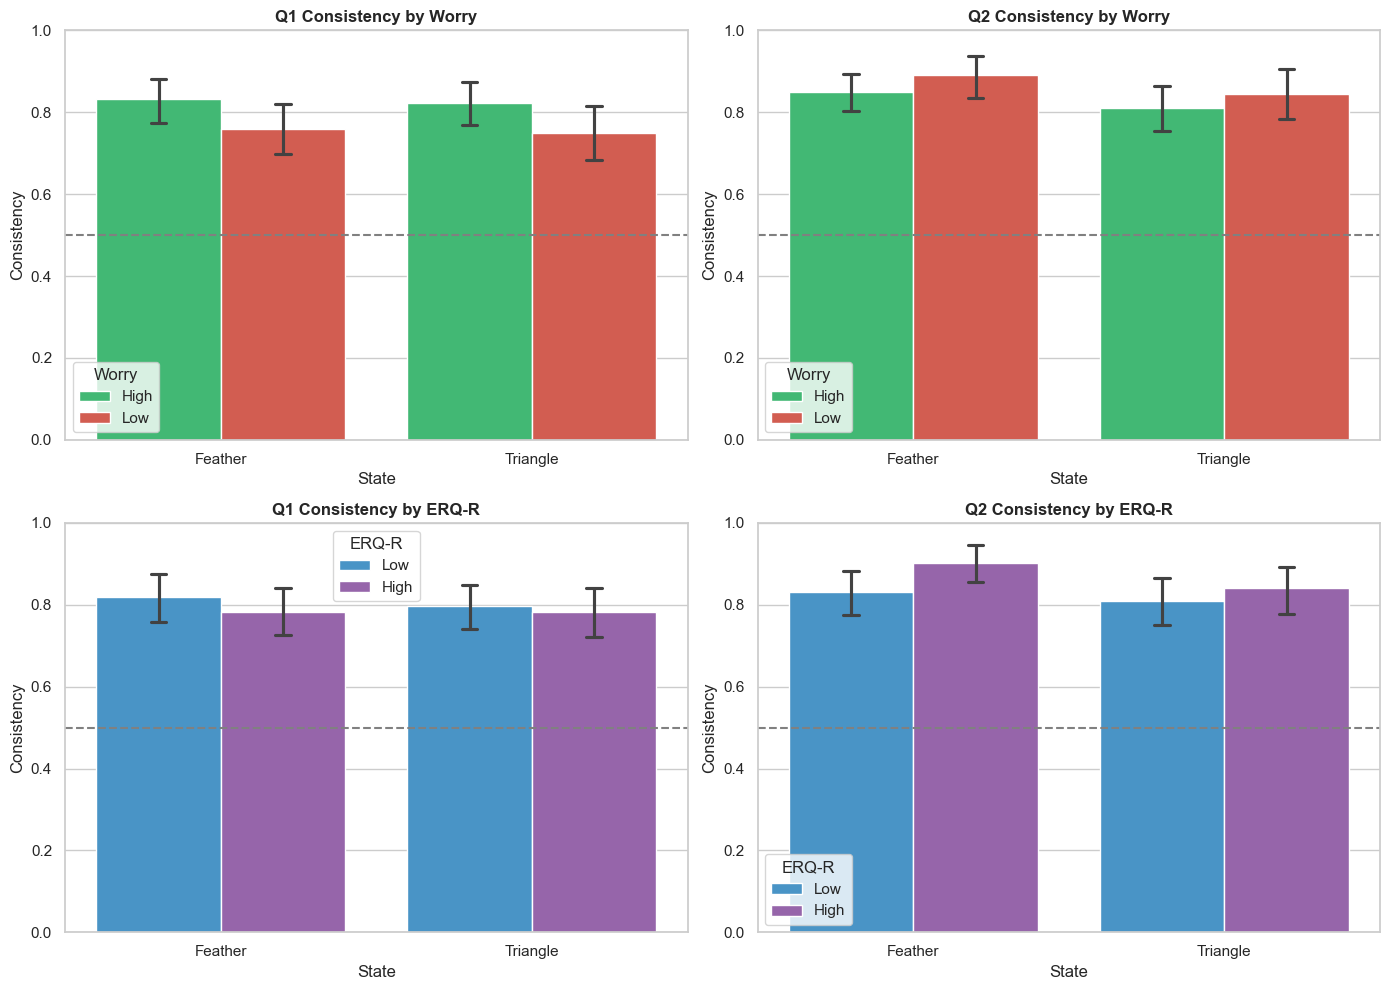

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

consistency_df = pd.read_csv('value_choice_consistency.csv')

print("="*80)
print("EXTENDED CONSISTENCY VISUALIZATIONS")
print("="*80)

# Figure: By Query and State for both groups
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By Worry - Q1
ax = axes[0, 0]
q1_worry = pd.DataFrame({'State': ['Feather']*len(consistency_df) + ['Triangle']*len(consistency_df), 'Worry': list(consistency_df['anxiety_group'])*2, 'Consistency': list(consistency_df['q1_feather']) + list(consistency_df['q1_triangle'])})
sns.barplot(data=q1_worry, x='State', y='Consistency', hue='Worry', ax=ax, palette=['#2ecc71', '#e74c3c'], capsize=0.1)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Q1 Consistency by Worry', fontweight='bold')
ax.set_ylim([0, 1])

# By Worry - Q2
ax = axes[0, 1]
q2_worry = pd.DataFrame({'State': ['Feather']*len(consistency_df) + ['Triangle']*len(consistency_df), 'Worry': list(consistency_df['anxiety_group'])*2, 'Consistency': list(consistency_df['q2_feather']) + list(consistency_df['q2_triangle'])})
sns.barplot(data=q2_worry, x='State', y='Consistency', hue='Worry', ax=ax, palette=['#2ecc71', '#e74c3c'], capsize=0.1)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Q2 Consistency by Worry', fontweight='bold')
ax.set_ylim([0, 1])

# By ERQ-R - Q1
ax = axes[1, 0]
q1_erq = pd.DataFrame({'State': ['Feather']*len(consistency_df) + ['Triangle']*len(consistency_df), 'ERQ-R': list(consistency_df['erq_group'])*2, 'Consistency': list(consistency_df['q1_feather']) + list(consistency_df['q1_triangle'])})
sns.barplot(data=q1_erq, x='State', y='Consistency', hue='ERQ-R', ax=ax, palette=['#3498db', '#9b59b6'], capsize=0.1)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Q1 Consistency by ERQ-R', fontweight='bold')
ax.set_ylim([0, 1])

# By ERQ-R - Q2
ax = axes[1, 1]
q2_erq = pd.DataFrame({'State': ['Feather']*len(consistency_df) + ['Triangle']*len(consistency_df), 'ERQ-R': list(consistency_df['erq_group'])*2, 'Consistency': list(consistency_df['q2_feather']) + list(consistency_df['q2_triangle'])})
sns.barplot(data=q2_erq, x='State', y='Consistency', hue='ERQ-R', ax=ax, palette=['#3498db', '#9b59b6'], capsize=0.1)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Q2 Consistency by ERQ-R', fontweight='bold')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('consistency_by_group_extended.png', dpi=150)
print("Saved: consistency_by_group_extended.png")
plt.show()

---
# Section 11: Cognitive Flexibility Analysis (Rating Trajectories)

COGNITIVE FLEXIBILITY ANALYSIS

Rating Flexibility:
  Period 1 (R1->R2): M=20.76, SD=19.71
  Period 2 (R2->R3): M=14.66, SD=19.33

--- WORRY Correlations ---
  Total_Flex_P1: r=-0.222, p=0.0151 *
  Total_Flex_P2: r=-0.061, p=0.5118 
  Total_Flex: r=-0.178, p=0.0533 

--- ERQ-R Correlations ---
  Total_Flex_P1: r=0.074, p=0.4261 
  Total_Flex_P2: r=0.053, p=0.5654 
  Total_Flex: r=0.079, p=0.3914 

Rating Trajectories:
  Feather: R1=5.50 -> R2=-1.64 -> R3=0.42
  Triangle: R1=-4.41 -> R2=1.30 -> R3=2.90

Saved: flexibility_rating_trajectories.png


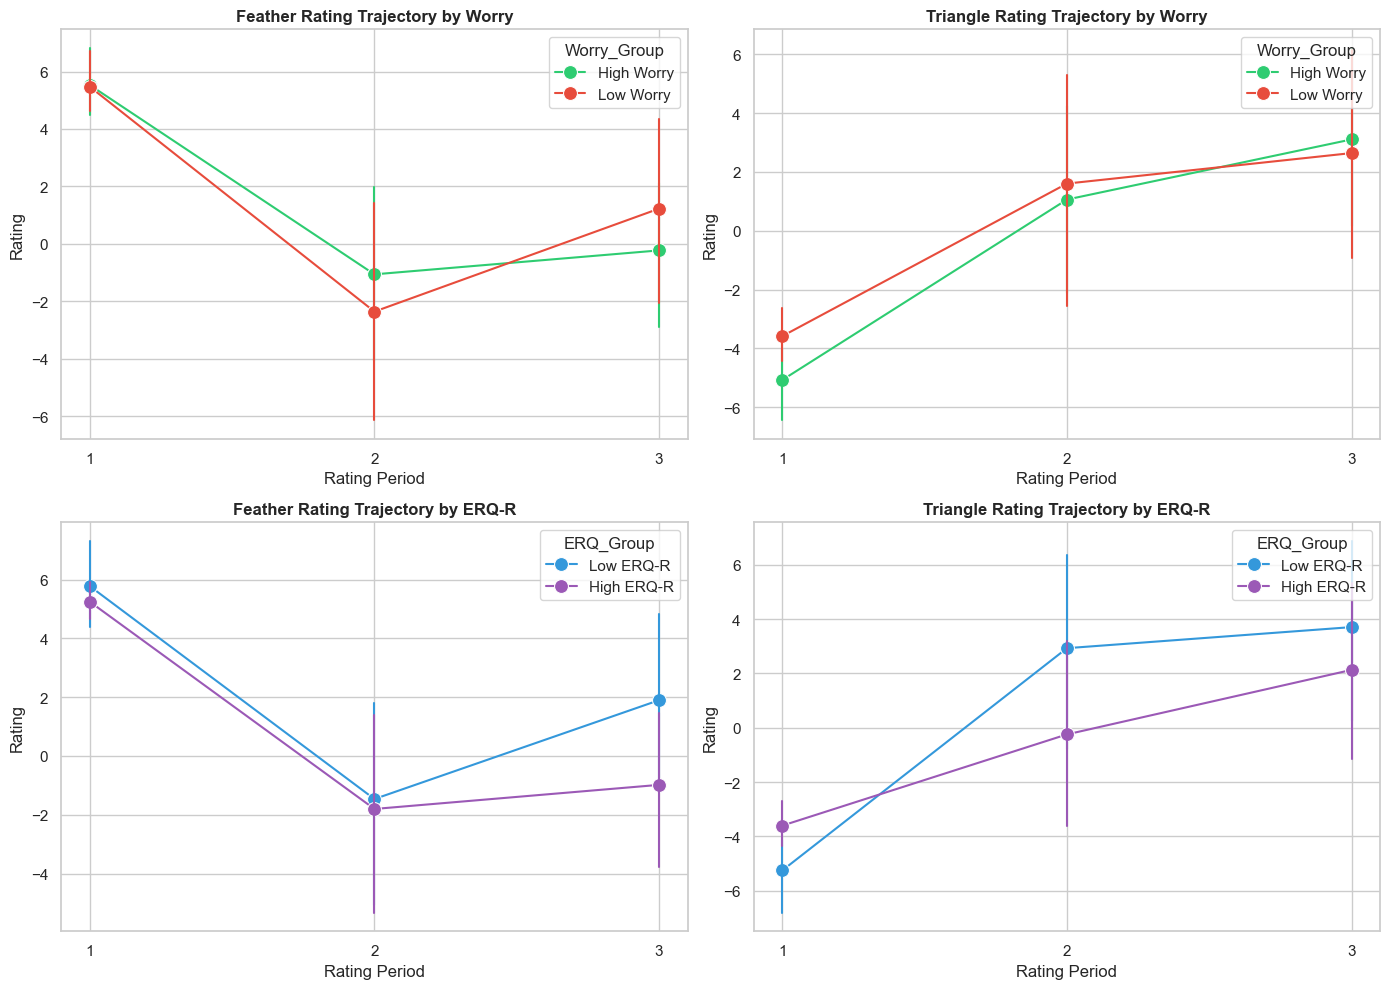

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_rel

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)

print("="*80)
print("COGNITIVE FLEXIBILITY ANALYSIS")
print("="*80)

df['Feather_Flex_P1'] = abs(df['Rating_2_Feather_Val'] - df['Rating_1_Feather_Val'])
df['Triangle_Flex_P1'] = abs(df['Rating_2_Triangle_Val'] - df['Rating_1_Triangle_Val'])
df['Feather_Flex_P2'] = abs(df['Rating_3_Feather_Val'] - df['Rating_2_Feather_Val'])
df['Triangle_Flex_P2'] = abs(df['Rating_3_Triangle_Val'] - df['Rating_2_Triangle_Val'])
df['Total_Flex_P1'] = df['Feather_Flex_P1'] + df['Triangle_Flex_P1']
df['Total_Flex_P2'] = df['Feather_Flex_P2'] + df['Triangle_Flex_P2']
df['Total_Flex'] = df['Total_Flex_P1'] + df['Total_Flex_P2']

print("\nRating Flexibility:")
print(f"  Period 1 (R1->R2): M={df['Total_Flex_P1'].mean():.2f}, SD={df['Total_Flex_P1'].std():.2f}")
print(f"  Period 2 (R2->R3): M={df['Total_Flex_P2'].mean():.2f}, SD={df['Total_Flex_P2'].std():.2f}")

print("\n--- WORRY Correlations ---")
for measure in ['Total_Flex_P1', 'Total_Flex_P2', 'Total_Flex']:
    r, p = pearsonr(df[measure].dropna(), df['Anxiety_Total'].dropna())
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"  {measure}: r={r:.3f}, p={p:.4f} {sig}")

print("\n--- ERQ-R Correlations ---")
for measure in ['Total_Flex_P1', 'Total_Flex_P2', 'Total_Flex']:
    r, p = pearsonr(df[measure].dropna(), df['ERQ_Reappraisal'].dropna())
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"  {measure}: r={r:.3f}, p={p:.4f} {sig}")

print("\nRating Trajectories:")
print(f"  Feather: R1={df['Rating_1_Feather_Val'].mean():.2f} -> R2={df['Rating_2_Feather_Val'].mean():.2f} -> R3={df['Rating_3_Feather_Val'].mean():.2f}")
print(f"  Triangle: R1={df['Rating_1_Triangle_Val'].mean():.2f} -> R2={df['Rating_2_Triangle_Val'].mean():.2f} -> R3={df['Rating_3_Triangle_Val'].mean():.2f}")

# Create long format for plotting
long_data = []
for idx, row in df.iterrows():
    for rating_num in [1, 2, 3]:
        for state in ['Feather', 'Triangle']:
            rating_val = row[f'Rating_{rating_num}_{state}_Val']
            if not pd.isna(rating_val):
                long_data.append({'subject_id': row['subject_id'], 'anxiety': row['Anxiety_Total'], 'erq_reappraisal': row['ERQ_Reappraisal'], 'rating_period': rating_num, 'state': state, 'rating': rating_val})

rating_df = pd.DataFrame(long_data)
rating_df['Worry_Group'] = rating_df['anxiety'].apply(lambda x: 'High Worry' if x >= df['Anxiety_Total'].median() else 'Low Worry')
rating_df['ERQ_Group'] = rating_df['erq_reappraisal'].apply(lambda x: 'High ERQ-R' if x >= df['ERQ_Reappraisal'].median() else 'Low ERQ-R')

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By Worry - Feather
ax = axes[0, 0]
feather_data = rating_df[rating_df['state'] == 'Feather']
sns.lineplot(data=feather_data, x='rating_period', y='rating', hue='Worry_Group', ax=ax, palette=['#2ecc71', '#e74c3c'], marker='o', markersize=10, err_style='bars')
ax.set_xlabel('Rating Period')
ax.set_ylabel('Rating')
ax.set_title('Feather Rating Trajectory by Worry', fontweight='bold')
ax.set_xticks([1, 2, 3])

# By Worry - Triangle
ax = axes[0, 1]
triangle_data = rating_df[rating_df['state'] == 'Triangle']
sns.lineplot(data=triangle_data, x='rating_period', y='rating', hue='Worry_Group', ax=ax, palette=['#2ecc71', '#e74c3c'], marker='o', markersize=10, err_style='bars')
ax.set_xlabel('Rating Period')
ax.set_ylabel('Rating')
ax.set_title('Triangle Rating Trajectory by Worry', fontweight='bold')
ax.set_xticks([1, 2, 3])

# By ERQ-R - Feather
ax = axes[1, 0]
sns.lineplot(data=feather_data, x='rating_period', y='rating', hue='ERQ_Group', ax=ax, palette=['#3498db', '#9b59b6'], marker='o', markersize=10, err_style='bars')
ax.set_xlabel('Rating Period')
ax.set_ylabel('Rating')
ax.set_title('Feather Rating Trajectory by ERQ-R', fontweight='bold')
ax.set_xticks([1, 2, 3])

# By ERQ-R - Triangle
ax = axes[1, 1]
sns.lineplot(data=triangle_data, x='rating_period', y='rating', hue='ERQ_Group', ax=ax, palette=['#3498db', '#9b59b6'], marker='o', markersize=10, err_style='bars')
ax.set_xlabel('Rating Period')
ax.set_ylabel('Rating')
ax.set_title('Triangle Rating Trajectory by ERQ-R', fontweight='bold')
ax.set_xticks([1, 2, 3])

plt.tight_layout()
plt.savefig('flexibility_rating_trajectories.png', dpi=150)
print("\nSaved: flexibility_rating_trajectories.png")
plt.show()

df.to_csv('filtered_data.csv', index=False)
rating_df.to_csv('rating_trajectories_long.csv', index=False)

DOUBLE DISSOCIATION ANALYSIS: Anxiety vs. Cognitive Reappraisal

Sample size: N = 139
Anxiety: M = 16.63, SD = 7.60, Median = 14.0
ERQ Reappraisal: M = 30.52, SD = 6.27, Median = 31.0

PART 1: RELATIONSHIP BETWEEN ANXIETY AND ERQ REAPPRAISAL

Anxiety × ERQ Reappraisal: r = -0.168, p = 0.0477 *
→ They are correlated but we will show DISSOCIABLE effects

PART 2: BASELINE TRIANGLE RATING (R1) - OPPOSITE BIASES

>>> ANXIETY <<<
Low Anxiety (n=64):  M = -3.28, SD = 3.80
High Anxiety (n=75): M = -5.40, SD = 5.44
t = 2.618, p = 0.0098 **
→ High Anxiety rated Triangle MORE NEGATIVELY

>>> ERQ REAPPRAISAL <<<
Low ERQ (n=68):  M = -5.44, SD = 5.78
High ERQ (n=71): M = -3.45, SD = 3.54
t = -2.460, p = 0.0152 *
→ High ERQ rated Triangle LESS NEGATIVELY

*** DISSOCIATION: Opposite directions on the SAME outcome ***

PART 3: CALCULATING PERFORMANCE METRICS

Calculating accuracy and RT metrics...
Done!

PART 4: SELECTIVE EFFECTS - ANXIETY vs ERQ

>>> ANXIETY CORRELATIONS <<<
-------------------------

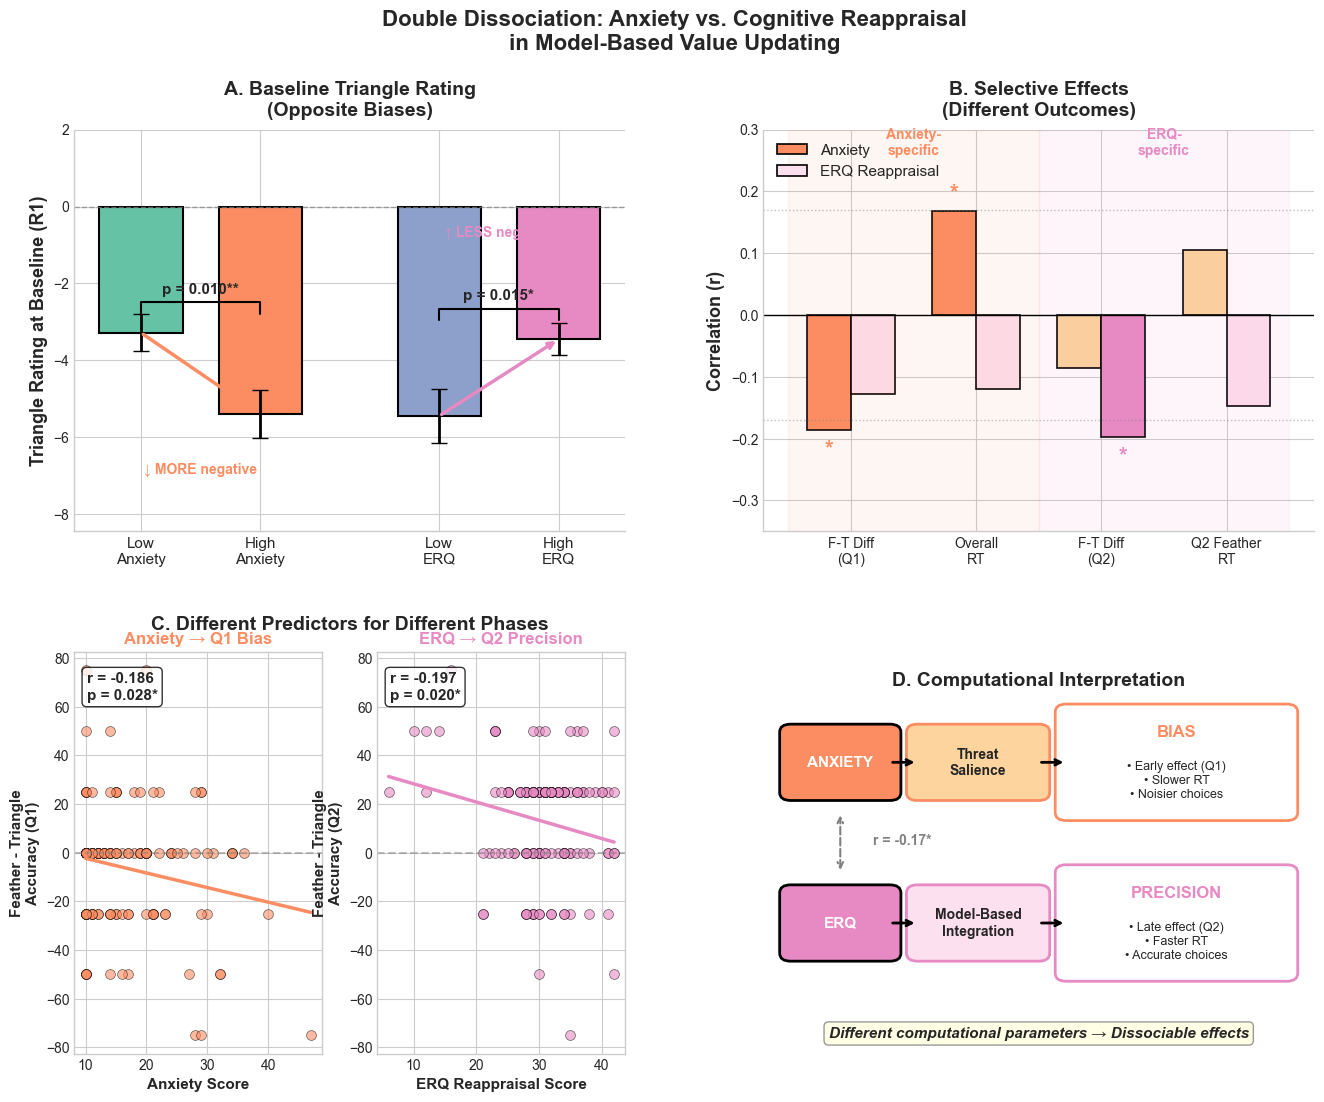


PART 7: SUMMARY STATISTICS FOR ABSTRACT

╔══════════════════════════════════════════════════════════════════════════════╗
║                      DOUBLE DISSOCIATION EVIDENCE                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  SAMPLE: N = 139                                                            ║
║  Anxiety × ERQ correlation: r = -0.168, p = 0.0477 *                       ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  BASELINE TRIANGLE RATING (R1) - OPPOSITE DIRECTIONS:                        ║
║    Anxiety:  High = -5.40, Low = -3.28  │  t = 2.62, p = 0.010 **        ║
║    ERQ:      High = -3.45, Low = -5.44  │  t = -2.46, p = 0.015 *         ║
║                                                                            

In [1]:
# =============================================================================
# DOUBLE DISSOCIATION ANALYSIS: Anxiety vs. Cognitive Reappraisal
# =============================================================================
# 
# This code block performs the full double dissociation analysis and creates
# publication-ready figures. Add this to your Jupyter notebook.
#
# Requirements: pandas, numpy, scipy, matplotlib, seaborn
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, ttest_rel, ttest_1samp
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# =============================================================================
# LOAD AND PREPARE DATA
# =============================================================================

print("="*80)
print("DOUBLE DISSOCIATION ANALYSIS: Anxiety vs. Cognitive Reappraisal")
print("="*80)

# Load filtered data
df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

# Score Anxiety
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
median_anxiety = df['Anxiety_Total'].median()
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= median_anxiety else 'Low'
)

# Score ERQ Reappraisal
erq_cols = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
            'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']
if all(col in df.columns for col in erq_cols):
    df['ERQ_Reappraisal'] = df[erq_cols].sum(axis=1)
else:
    df['ERQ_Reappraisal'] = df.get('Survey_ERQ_Reappraisal_Score', np.nan)

median_erq = df['ERQ_Reappraisal'].median()
df['ERQ_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= median_erq else 'Low'
)

# Extract ratings
df['R1_Feather'] = df['Rating_1_Feather_Val']
df['R1_Triangle'] = df['Rating_1_Triangle_Val']
df['R2_Feather'] = df['Rating_2_Feather_Val']
df['R2_Triangle'] = df['Rating_2_Triangle_Val']
df['R3_Feather'] = df['Rating_3_Feather_Val']
df['R3_Triangle'] = df['Rating_3_Triangle_Val']

print(f"\nSample size: N = {len(df)}")
print(f"Anxiety: M = {df['Anxiety_Total'].mean():.2f}, SD = {df['Anxiety_Total'].std():.2f}, Median = {median_anxiety}")
print(f"ERQ Reappraisal: M = {df['ERQ_Reappraisal'].mean():.2f}, SD = {df['ERQ_Reappraisal'].std():.2f}, Median = {median_erq}")

# =============================================================================
# PART 1: CORRELATION BETWEEN ANXIETY AND ERQ
# =============================================================================

print("\n" + "="*80)
print("PART 1: RELATIONSHIP BETWEEN ANXIETY AND ERQ REAPPRAISAL")
print("="*80)

r_anx_erq, p_anx_erq = pearsonr(df['Anxiety_Total'].dropna(), df['ERQ_Reappraisal'].dropna())
print(f"\nAnxiety × ERQ Reappraisal: r = {r_anx_erq:.3f}, p = {p_anx_erq:.4f} {'*' if p_anx_erq < .05 else ''}")
print("→ They are correlated but we will show DISSOCIABLE effects")

# =============================================================================
# PART 2: BASELINE TRIANGLE RATING - THE KEY DISSOCIATION
# =============================================================================

print("\n" + "="*80)
print("PART 2: BASELINE TRIANGLE RATING (R1) - OPPOSITE BIASES")
print("="*80)

# By Anxiety Group
low_anx_triangle = df[df['Anxiety_Group'] == 'Low']['R1_Triangle']
high_anx_triangle = df[df['Anxiety_Group'] == 'High']['R1_Triangle']
t_anx, p_anx = ttest_ind(low_anx_triangle, high_anx_triangle)

print(f"\n>>> ANXIETY <<<")
print(f"Low Anxiety (n={len(low_anx_triangle)}):  M = {low_anx_triangle.mean():.2f}, SD = {low_anx_triangle.std():.2f}")
print(f"High Anxiety (n={len(high_anx_triangle)}): M = {high_anx_triangle.mean():.2f}, SD = {high_anx_triangle.std():.2f}")
print(f"t = {t_anx:.3f}, p = {p_anx:.4f} {'**' if p_anx < .01 else '*' if p_anx < .05 else ''}")
print(f"→ High Anxiety rated Triangle MORE NEGATIVELY")

# By ERQ Group
low_erq_triangle = df[df['ERQ_Group'] == 'Low']['R1_Triangle']
high_erq_triangle = df[df['ERQ_Group'] == 'High']['R1_Triangle']
t_erq, p_erq = ttest_ind(low_erq_triangle, high_erq_triangle)

print(f"\n>>> ERQ REAPPRAISAL <<<")
print(f"Low ERQ (n={len(low_erq_triangle)}):  M = {low_erq_triangle.mean():.2f}, SD = {low_erq_triangle.std():.2f}")
print(f"High ERQ (n={len(high_erq_triangle)}): M = {high_erq_triangle.mean():.2f}, SD = {high_erq_triangle.std():.2f}")
print(f"t = {t_erq:.3f}, p = {p_erq:.4f} {'**' if p_erq < .01 else '*' if p_erq < .05 else ''}")
print(f"→ High ERQ rated Triangle LESS NEGATIVELY")

print(f"\n*** DISSOCIATION: Opposite directions on the SAME outcome ***")

# Store for plotting
baseline_results = {
    'anxiety': {
        'low_m': low_anx_triangle.mean(),
        'low_se': low_anx_triangle.sem(),
        'high_m': high_anx_triangle.mean(),
        'high_se': high_anx_triangle.sem(),
        't': t_anx,
        'p': p_anx
    },
    'erq': {
        'low_m': low_erq_triangle.mean(),
        'low_se': low_erq_triangle.sem(),
        'high_m': high_erq_triangle.mean(),
        'high_se': high_erq_triangle.sem(),
        't': t_erq,
        'p': p_erq
    }
}

# =============================================================================
# PART 3: CALCULATE PERFORMANCE METRICS
# =============================================================================

print("\n" + "="*80)
print("PART 3: CALCULATING PERFORMANCE METRICS")
print("="*80)

# Define expected values
q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

def calculate_accuracy(row, query_num, ev_map):
    """Calculate accuracy for a given query"""
    correct = 0
    total = 0
    feather_correct = 0
    feather_total = 0
    triangle_correct = 0
    triangle_total = 0
    
    for trial in range(1, 21):
        state_col = f'Query_{query_num}_T{trial}_State'
        offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
        choice_col = f'Query_{query_num}_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
            
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        state_ev = ev_map.get(state, 0)
        optimal = 1 if state_ev > offer else 0
        is_correct = (choice == optimal)
        
        correct += is_correct
        total += 1
        
        if state == 'Feather':
            feather_correct += is_correct
            feather_total += 1
        else:
            triangle_correct += is_correct
            triangle_total += 1
    
    return {
        'accuracy': (correct / total * 100) if total > 0 else np.nan,
        'feather_acc': (feather_correct / feather_total * 100) if feather_total > 0 else np.nan,
        'triangle_acc': (triangle_correct / triangle_total * 100) if triangle_total > 0 else np.nan
    }

def calculate_mean_rt(row, query_num):
    """Calculate mean RT for a given query by state"""
    feather_rts = []
    triangle_rts = []
    
    for trial in range(1, 21):
        state_col = f'Query_{query_num}_T{trial}_State'
        rt_col = f'Query_{query_num}_T{trial}_RT'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        if rt_col not in row.index:
            break
            
        state = row[state_col]
        rt = row[rt_col]
        
        if pd.isna(rt):
            continue
        
        if state == 'Feather':
            feather_rts.append(rt)
        else:
            triangle_rts.append(rt)
    
    return {
        'feather_rt': np.mean(feather_rts) if feather_rts else np.nan,
        'triangle_rt': np.mean(triangle_rts) if triangle_rts else np.nan,
        'mean_rt': np.mean(feather_rts + triangle_rts) if (feather_rts + triangle_rts) else np.nan
    }

# Calculate metrics for each subject
print("\nCalculating accuracy and RT metrics...")

for idx, row in df.iterrows():
    # Query 1
    q1_results = calculate_accuracy(row, 1, q1_ev_map)
    df.loc[idx, 'Q1_Accuracy'] = q1_results['accuracy']
    df.loc[idx, 'Q1_Feather_Acc'] = q1_results['feather_acc']
    df.loc[idx, 'Q1_Triangle_Acc'] = q1_results['triangle_acc']
    
    # Query 2
    q2_results = calculate_accuracy(row, 2, q2_ev_map)
    df.loc[idx, 'Q2_Accuracy'] = q2_results['accuracy']
    df.loc[idx, 'Q2_Feather_Acc'] = q2_results['feather_acc']
    df.loc[idx, 'Q2_Triangle_Acc'] = q2_results['triangle_acc']
    
    # RTs
    q1_rt = calculate_mean_rt(row, 1)
    df.loc[idx, 'Q1_Feather_RT'] = q1_rt['feather_rt']
    df.loc[idx, 'Q1_Triangle_RT'] = q1_rt['triangle_rt']
    df.loc[idx, 'Q1_Mean_RT'] = q1_rt['mean_rt']
    
    q2_rt = calculate_mean_rt(row, 2)
    df.loc[idx, 'Q2_Feather_RT'] = q2_rt['feather_rt']
    df.loc[idx, 'Q2_Triangle_RT'] = q2_rt['triangle_rt']
    df.loc[idx, 'Q2_Mean_RT'] = q2_rt['mean_rt']

# Calculate difference scores
df['Q1_FT_Diff'] = df['Q1_Feather_Acc'] - df['Q1_Triangle_Acc']
df['Q2_FT_Diff'] = df['Q2_Feather_Acc'] - df['Q2_Triangle_Acc']
df['Overall_Mean_RT'] = (df['Q1_Mean_RT'] + df['Q2_Mean_RT']) / 2

# Log-transform RTs
df['Q2_Feather_logRT'] = np.log(df['Q2_Feather_RT'] + 1)
df['Q2_Triangle_logRT'] = np.log(df['Q2_Triangle_RT'] + 1)

print("Done!")

# =============================================================================
# PART 4: SELECTIVE EFFECTS ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("PART 4: SELECTIVE EFFECTS - ANXIETY vs ERQ")
print("="*80)

# Define outcomes to test
outcomes = {
    'Q1_FT_Diff': 'Feather-Triangle Diff (Q1)',
    'Q2_FT_Diff': 'Feather-Triangle Diff (Q2)',
    'Q1_Accuracy': 'Q1 Overall Accuracy',
    'Q2_Accuracy': 'Q2 Overall Accuracy',
    'Q1_Feather_Acc': 'Q1 Feather Accuracy',
    'Q1_Triangle_Acc': 'Q1 Triangle Accuracy',
    'Q2_Feather_Acc': 'Q2 Feather Accuracy',
    'Q2_Triangle_Acc': 'Q2 Triangle Accuracy',
    'Overall_Mean_RT': 'Overall Mean RT',
    'Q2_Feather_logRT': 'Q2 Feather log(RT)',
    'Q2_Triangle_logRT': 'Q2 Triangle log(RT)',
}

print("\n>>> ANXIETY CORRELATIONS <<<")
print("-" * 70)
anxiety_correlations = {}
for var, label in outcomes.items():
    valid = df[[var, 'Anxiety_Total']].dropna()
    if len(valid) > 10:
        r, p = pearsonr(valid[var], valid['Anxiety_Total'])
        sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        print(f"  {label:<30}: r = {r:>6.3f}, p = {p:.4f} {sig}")
        anxiety_correlations[var] = {'r': r, 'p': p, 'sig': p < .05}

print("\n>>> ERQ REAPPRAISAL CORRELATIONS <<<")
print("-" * 70)
erq_correlations = {}
for var, label in outcomes.items():
    valid = df[[var, 'ERQ_Reappraisal']].dropna()
    if len(valid) > 10:
        r, p = pearsonr(valid[var], valid['ERQ_Reappraisal'])
        sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        print(f"  {label:<30}: r = {r:>6.3f}, p = {p:.4f} {sig}")
        erq_correlations[var] = {'r': r, 'p': p, 'sig': p < .05}

# =============================================================================
# PART 5: DISSOCIATION SUMMARY
# =============================================================================

print("\n" + "="*80)
print("PART 5: DISSOCIATION SUMMARY")
print("="*80)

print("\n*** ANXIETY-SPECIFIC EFFECTS (ERQ shows no effect) ***")
anxiety_specific = []
for var in outcomes.keys():
    if var in anxiety_correlations and var in erq_correlations:
        if anxiety_correlations[var]['sig'] and not erq_correlations[var]['sig']:
            print(f"  {outcomes[var]}: Anxiety r = {anxiety_correlations[var]['r']:.3f}, p = {anxiety_correlations[var]['p']:.4f} *")
            print(f"  {' '*len(outcomes[var])}  ERQ r = {erq_correlations[var]['r']:.3f}, p = {erq_correlations[var]['p']:.4f}")
            anxiety_specific.append(var)

print("\n*** ERQ-SPECIFIC EFFECTS (Anxiety shows no effect) ***")
erq_specific = []
for var in outcomes.keys():
    if var in anxiety_correlations and var in erq_correlations:
        if erq_correlations[var]['sig'] and not anxiety_correlations[var]['sig']:
            print(f"  {outcomes[var]}: ERQ r = {erq_correlations[var]['r']:.3f}, p = {erq_correlations[var]['p']:.4f} *")
            print(f"  {' '*len(outcomes[var])}  Anxiety r = {anxiety_correlations[var]['r']:.3f}, p = {anxiety_correlations[var]['p']:.4f}")
            erq_specific.append(var)

# =============================================================================
# PART 6: CREATE PUBLICATION FIGURE
# =============================================================================

print("\n" + "="*80)
print("PART 6: CREATING PUBLICATION FIGURE")
print("="*80)

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.25)

# -----------------------------------------------------------------------------
# PANEL A: Baseline Triangle Rating
# -----------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

groups = ['Low\nAnxiety', 'High\nAnxiety', 'Low\nERQ', 'High\nERQ']
means = [baseline_results['anxiety']['low_m'], baseline_results['anxiety']['high_m'],
         baseline_results['erq']['low_m'], baseline_results['erq']['high_m']]
sems = [baseline_results['anxiety']['low_se'], baseline_results['anxiety']['high_se'],
        baseline_results['erq']['low_se'], baseline_results['erq']['high_se']]

colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
x_pos = [0, 1, 2.5, 3.5]

bars = ax1.bar(x_pos, means, yerr=sems, capsize=6, color=colors,
               edgecolor='black', linewidth=1.5, width=0.7, error_kw={'linewidth': 2})

ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_ylabel('Triangle Rating at Baseline (R1)', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(groups, fontsize=11)
ax1.set_ylim(min(means) - 3, 2)

# Add significance brackets
def add_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], 'k-', linewidth=1.5)
    ax.text((x1+x2)/2, y+h+0.15, text, ha='center', va='bottom', fontsize=11, fontweight='bold')

p_anx_text = f'p = {baseline_results["anxiety"]["p"]:.3f}{"**" if baseline_results["anxiety"]["p"] < .01 else "*" if baseline_results["anxiety"]["p"] < .05 else ""}'
p_erq_text = f'p = {baseline_results["erq"]["p"]:.3f}{"**" if baseline_results["erq"]["p"] < .01 else "*" if baseline_results["erq"]["p"] < .05 else ""}'

add_bracket(ax1, 0, 1, max(means[0:2]) + 0.5, 0.3, p_anx_text)
add_bracket(ax1, 2.5, 3.5, max(means[2:4]) + 0.5, 0.3, p_erq_text)

# Direction annotations
ax1.annotate('', xy=(1, means[1]), xytext=(0, means[0]),
            arrowprops=dict(arrowstyle='->', color='#fc8d62', lw=2.5))
ax1.annotate('', xy=(3.5, means[3]), xytext=(2.5, means[2]),
            arrowprops=dict(arrowstyle='->', color='#e78ac3', lw=2.5))

ax1.text(0.5, min(means) - 1.5, '↓ MORE negative', ha='center', fontsize=10, 
         color='#fc8d62', fontweight='bold')
ax1.text(3, max(means) + 2.5, '↑ LESS negative', ha='center', fontsize=10, 
         color='#e78ac3', fontweight='bold')

ax1.set_title('A. Baseline Triangle Rating\n(Opposite Biases)', fontsize=14, fontweight='bold', pad=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# -----------------------------------------------------------------------------
# PANEL B: Selective Effects Bar Chart
# -----------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

# Select key outcomes for visualization
key_outcomes = ['Q1_FT_Diff', 'Overall_Mean_RT', 'Q2_FT_Diff', 'Q2_Feather_logRT']
key_labels = ['F-T Diff\n(Q1)', 'Overall\nRT', 'F-T Diff\n(Q2)', 'Q2 Feather\nRT']

anx_rs = [anxiety_correlations.get(k, {'r': 0})['r'] for k in key_outcomes]
anx_sigs = [anxiety_correlations.get(k, {'sig': False})['sig'] for k in key_outcomes]
erq_rs = [erq_correlations.get(k, {'r': 0})['r'] for k in key_outcomes]
erq_sigs = [erq_correlations.get(k, {'sig': False})['sig'] for k in key_outcomes]

x = np.arange(len(key_outcomes))
width = 0.35

bars1 = ax2.bar(x - width/2, anx_rs, width, label='Anxiety',
                color=['#fc8d62' if s else '#fdd49e' for s in anx_sigs],
                edgecolor='black', linewidth=1.2)
bars2 = ax2.bar(x + width/2, erq_rs, width, label='ERQ Reappraisal',
                color=['#e78ac3' if s else '#fde0ef' for s in erq_sigs],
                edgecolor='black', linewidth=1.2)

ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.axhline(0.17, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax2.axhline(-0.17, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax2.set_ylabel('Correlation (r)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(key_labels, fontsize=10)
ax2.set_ylim(-0.35, 0.30)
ax2.legend(loc='upper left', fontsize=11, framealpha=0.9)

# Add significance stars
for i, (a_sig, e_sig) in enumerate(zip(anx_sigs, erq_sigs)):
    if a_sig:
        y_pos = anx_rs[i] + 0.02 if anx_rs[i] > 0 else anx_rs[i] - 0.04
        ax2.text(i - width/2, y_pos, '*', ha='center', fontsize=16, 
                fontweight='bold', color='#fc8d62')
    if e_sig:
        y_pos = erq_rs[i] + 0.02 if erq_rs[i] > 0 else erq_rs[i] - 0.04
        ax2.text(i + width/2, y_pos, '*', ha='center', fontsize=16, 
                fontweight='bold', color='#e78ac3')

# Highlight regions
ax2.axvspan(-0.5, 1.5, alpha=0.08, color='#fc8d62')
ax2.axvspan(1.5, 3.5, alpha=0.08, color='#e78ac3')
ax2.text(0.5, 0.26, 'Anxiety-\nspecific', fontsize=10, ha='center', 
         color='#fc8d62', fontweight='bold')
ax2.text(2.5, 0.26, 'ERQ-\nspecific', fontsize=10, ha='center', 
         color='#e78ac3', fontweight='bold')

ax2.set_title('B. Selective Effects\n(Different Outcomes)', fontsize=14, fontweight='bold', pad=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# -----------------------------------------------------------------------------
# PANEL C: Scatterplots showing opposite effects
# -----------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

# Create side-by-side scatterplots
ax3_left = ax3.inset_axes([0, 0, 0.45, 1])
ax3_right = ax3.inset_axes([0.55, 0, 0.45, 1])
ax3.axis('off')

# Left: Anxiety vs Q1 F-T Diff
valid = df[['Anxiety_Total', 'Q1_FT_Diff']].dropna()
ax3_left.scatter(valid['Anxiety_Total'], valid['Q1_FT_Diff'], 
                 alpha=0.6, s=50, color='#fc8d62', edgecolor='black', linewidth=0.5)
z = np.polyfit(valid['Anxiety_Total'], valid['Q1_FT_Diff'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['Anxiety_Total'].min(), valid['Anxiety_Total'].max(), 100)
ax3_left.plot(x_line, p(x_line), color='#fc8d62', linewidth=2.5, linestyle='-')

r, pval = pearsonr(valid['Anxiety_Total'], valid['Q1_FT_Diff'])
ax3_left.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.3f}*', transform=ax3_left.transAxes,
              fontsize=11, fontweight='bold', va='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3_left.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax3_left.set_xlabel('Anxiety Score', fontsize=11, fontweight='bold')
ax3_left.set_ylabel('Feather - Triangle\nAccuracy (Q1)', fontsize=11, fontweight='bold')
ax3_left.set_title('Anxiety → Q1 Bias', fontsize=12, fontweight='bold', color='#fc8d62')

# Right: ERQ vs Q2 F-T Diff
valid = df[['ERQ_Reappraisal', 'Q2_FT_Diff']].dropna()
ax3_right.scatter(valid['ERQ_Reappraisal'], valid['Q2_FT_Diff'], 
                  alpha=0.6, s=50, color='#e78ac3', edgecolor='black', linewidth=0.5)
z = np.polyfit(valid['ERQ_Reappraisal'], valid['Q2_FT_Diff'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['ERQ_Reappraisal'].min(), valid['ERQ_Reappraisal'].max(), 100)
ax3_right.plot(x_line, p(x_line), color='#e78ac3', linewidth=2.5, linestyle='-')

r, pval = pearsonr(valid['ERQ_Reappraisal'], valid['Q2_FT_Diff'])
ax3_right.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.3f}*', transform=ax3_right.transAxes,
               fontsize=11, fontweight='bold', va='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3_right.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax3_right.set_xlabel('ERQ Reappraisal Score', fontsize=11, fontweight='bold')
ax3_right.set_ylabel('Feather - Triangle\nAccuracy (Q2)', fontsize=11, fontweight='bold')
ax3_right.set_title('ERQ → Q2 Precision', fontsize=12, fontweight='bold', color='#e78ac3')

ax3.set_title('C. Different Predictors for Different Phases', fontsize=14, fontweight='bold', 
              pad=10, y=1.02)

# -----------------------------------------------------------------------------
# PANEL D: Conceptual Model
# -----------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# Create conceptual diagram
# Title
ax4.text(0.5, 0.95, 'D. Computational Interpretation', fontsize=14, fontweight='bold',
         ha='center', va='top', transform=ax4.transAxes)

# ANXIETY pathway
ax4.add_patch(mpatches.FancyBboxPatch((0.05, 0.65), 0.18, 0.15,
              boxstyle="round,pad=0.02", facecolor='#fc8d62', edgecolor='black', linewidth=2,
              transform=ax4.transAxes))
ax4.text(0.14, 0.725, 'ANXIETY', ha='center', va='center', fontsize=11, fontweight='bold',
         color='white', transform=ax4.transAxes)

ax4.annotate('', xy=(0.28, 0.725), xytext=(0.23, 0.725),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            xycoords='axes fraction', textcoords='axes fraction')

ax4.add_patch(mpatches.FancyBboxPatch((0.28, 0.65), 0.22, 0.15,
              boxstyle="round,pad=0.02", facecolor='#fdd49e', edgecolor='#fc8d62', linewidth=2,
              transform=ax4.transAxes))
ax4.text(0.39, 0.725, 'Threat\nSalience', ha='center', va='center', fontsize=10, fontweight='bold',
         transform=ax4.transAxes)

ax4.annotate('', xy=(0.55, 0.725), xytext=(0.50, 0.725),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            xycoords='axes fraction', textcoords='axes fraction')

ax4.add_patch(mpatches.FancyBboxPatch((0.55, 0.60), 0.40, 0.25,
              boxstyle="round,pad=0.02", facecolor='white', edgecolor='#fc8d62', linewidth=2,
              transform=ax4.transAxes))
ax4.text(0.75, 0.80, 'BIAS', ha='center', va='center', fontsize=12, fontweight='bold',
         color='#fc8d62', transform=ax4.transAxes)
ax4.text(0.75, 0.68, '• Early effect (Q1)\n• Slower RT\n• Noisier choices', 
         ha='center', va='center', fontsize=9, transform=ax4.transAxes)

# ERQ pathway
ax4.add_patch(mpatches.FancyBboxPatch((0.05, 0.25), 0.18, 0.15,
              boxstyle="round,pad=0.02", facecolor='#e78ac3', edgecolor='black', linewidth=2,
              transform=ax4.transAxes))
ax4.text(0.14, 0.325, 'ERQ', ha='center', va='center', fontsize=11, fontweight='bold',
         color='white', transform=ax4.transAxes)

ax4.annotate('', xy=(0.28, 0.325), xytext=(0.23, 0.325),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            xycoords='axes fraction', textcoords='axes fraction')

ax4.add_patch(mpatches.FancyBboxPatch((0.28, 0.25), 0.22, 0.15,
              boxstyle="round,pad=0.02", facecolor='#fde0ef', edgecolor='#e78ac3', linewidth=2,
              transform=ax4.transAxes))
ax4.text(0.39, 0.325, 'Model-Based\nIntegration', ha='center', va='center', fontsize=10, 
         fontweight='bold', transform=ax4.transAxes)

ax4.annotate('', xy=(0.55, 0.325), xytext=(0.50, 0.325),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            xycoords='axes fraction', textcoords='axes fraction')

ax4.add_patch(mpatches.FancyBboxPatch((0.55, 0.20), 0.40, 0.25,
              boxstyle="round,pad=0.02", facecolor='white', edgecolor='#e78ac3', linewidth=2,
              transform=ax4.transAxes))
ax4.text(0.75, 0.40, 'PRECISION', ha='center', va='center', fontsize=12, fontweight='bold',
         color='#e78ac3', transform=ax4.transAxes)
ax4.text(0.75, 0.28, '• Late effect (Q2)\n• Faster RT\n• Accurate choices', 
         ha='center', va='center', fontsize=9, transform=ax4.transAxes)

# Correlation between constructs
ax4.annotate('', xy=(0.14, 0.60), xytext=(0.14, 0.45),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5, ls='--'),
            xycoords='axes fraction', textcoords='axes fraction')
ax4.text(0.20, 0.52, f'r = {r_anx_erq:.2f}*', fontsize=10, color='gray', fontweight='bold',
         transform=ax4.transAxes)

# Key message
ax4.text(0.5, 0.05, 'Different computational parameters → Dissociable effects',
         ha='center', va='center', fontsize=11, fontweight='bold', fontstyle='italic',
         transform=ax4.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

# Main title
fig.suptitle('Double Dissociation: Anxiety vs. Cognitive Reappraisal\nin Model-Based Value Updating',
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('double_dissociation_figure.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.savefig('double_dissociation_figure.pdf', bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("\nFigure saved: double_dissociation_figure.png / .pdf")
plt.show()

# =============================================================================
# PART 7: SUMMARY STATISTICS TABLE
# =============================================================================

print("\n" + "="*80)
print("PART 7: SUMMARY STATISTICS FOR ABSTRACT")
print("="*80)

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                      DOUBLE DISSOCIATION EVIDENCE                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  SAMPLE: N = {len(df)}                                                            ║
║  Anxiety × ERQ correlation: r = {r_anx_erq:.3f}, p = {p_anx_erq:.4f} *                       ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  BASELINE TRIANGLE RATING (R1) - OPPOSITE DIRECTIONS:                        ║
║    Anxiety:  High = {baseline_results['anxiety']['high_m']:.2f}, Low = {baseline_results['anxiety']['low_m']:.2f}  │  t = {baseline_results['anxiety']['t']:.2f}, p = {baseline_results['anxiety']['p']:.3f} **        ║
║    ERQ:      High = {baseline_results['erq']['high_m']:.2f}, Low = {baseline_results['erq']['low_m']:.2f}  │  t = {baseline_results['erq']['t']:.2f}, p = {baseline_results['erq']['p']:.3f} *         ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  ANXIETY-SPECIFIC EFFECTS:                                                   ║
║    • F-T Diff Q1:     r = {anxiety_correlations.get('Q1_FT_Diff', {'r': 0})['r']:.3f}, p = {anxiety_correlations.get('Q1_FT_Diff', {'p': 1})['p']:.4f} *                              ║
║    • Overall RT:      r = {anxiety_correlations.get('Overall_Mean_RT', {'r': 0})['r']:.3f}, p = {anxiety_correlations.get('Overall_Mean_RT', {'p': 1})['p']:.4f} *                              ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  ERQ-SPECIFIC EFFECTS:                                                       ║
║    • F-T Diff Q2:     r = {erq_correlations.get('Q2_FT_Diff', {'r': 0})['r']:.3f}, p = {erq_correlations.get('Q2_FT_Diff', {'p': 1})['p']:.4f} *                              ║
║    • Q2 Feather RT:   r = {erq_correlations.get('Q2_Feather_logRT', {'r': 0})['r']:.3f}, p = {erq_correlations.get('Q2_Feather_logRT', {'p': 1})['p']:.4f} *                              ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Save processed data
df.to_csv('double_dissociation_analysis_data.csv', index=False)
print("\nData saved: double_dissociation_analysis_data.csv")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

We predict that high-worry individuals will too easily reevaluate positive states to negative due to an over-sensitivity to threat and will take longer to reevaluate negative states to positive.

HYPOTHESIS TEST: ANXIETY & ASYMMETRIC PROCESSING
Prediction: High Anxiety = Fast/Easy Drop (Feather) vs. Slow/Hard Rise (Triangle)

----------------------------------------
ANALYSIS SCOPE: COMBINED (Q1 + Q2)
----------------------------------------
1. RATINGS: 'Too Easily' Devalue Feather?
   High Anx Mean Drop: 5.27 | Low Anx Mean Drop: 2.58
   t=1.419, p=0.1583

2. CHOICE: 'Over Sensitivity' (Triangle - Feather Gap)?
   High Anx Gap: -0.15 | Low Anx Gap: -0.21
   t=0.740, p=0.4605

3. CORRELATION: Feather vs Triangle P(Gamble)
   High Anxiety: r=-0.430, p=0.0001
   Low Anxiety: r=-0.612, p=0.0000

4. SPEED: 'Take Longer' on Triangle? (Triangle RT - Feather RT)
   High Anx Diff: -263ms | Low Anx Diff: -425ms
   t=0.864, p=0.3888

----------------------------------------
ANALYSIS SCOPE: Query 1
----------------------------------------
1. RATINGS: 'Too Easily' Devalue Feather?
   High Anx Mean Drop: 5.27 | Low Anx Mean Drop: 2.58
   t=1.419, p=0.1583

2. CHOICE: 'Over Sensitivity' (Tria

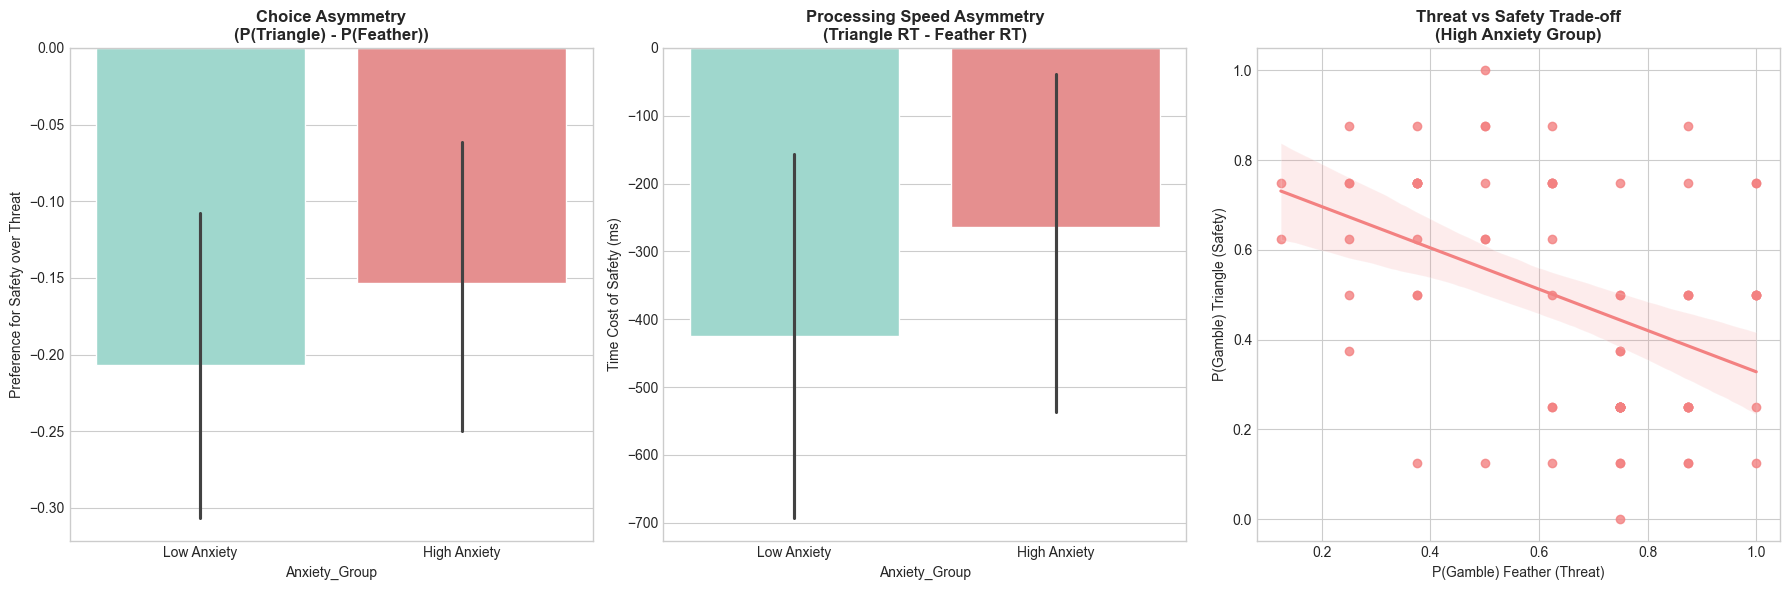

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set Plot Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

print("="*80)
print("HYPOTHESIS TEST: ANXIETY & ASYMMETRIC PROCESSING")
print("Prediction: High Anxiety = Fast/Easy Drop (Feather) vs. Slow/Hard Rise (Triangle)")
print("="*80)

# 1. LOAD & PREP DATA
# ----------------------------------------------------------------------------
df = pd.read_csv('filtered_data.csv')
rating_df = pd.read_csv('rating_trajectories_long.csv')

# Define Anxiety Groups (Median Split)
if 'Survey_ANXIETY_2_Total_Score' in df.columns:
    df['Anxiety_Score'] = df['Survey_ANXIETY_2_Total_Score']
elif 'Score_Anxiety_Total' in df.columns:
    df['Anxiety_Score'] = df['Score_Anxiety_Total']

median_anx = df['Anxiety_Score'].median()
df['Anxiety_Group'] = df['Anxiety_Score'].apply(lambda x: 'High Anxiety' if x >= median_anx else 'Low Anxiety')

# Map groups to rating dataframe
group_map = dict(zip(df['subject_id'], df['Anxiety_Group']))
rating_df['Anxiety_Group'] = rating_df['subject_id'].map(group_map)

# 2. ANALYSIS FUNCTION (Runs for Q1, Q2, and Combined)
# ----------------------------------------------------------------------------
def analyze_asymmetry(scope_df, rating_scope_df, scope_name):
    print(f"\n{'-'*40}")
    print(f"ANALYSIS SCOPE: {scope_name}")
    print(f"{'-'*40}")
    
    # --- PART A: RATINGS ("Too Easily" Revalue) ---
    # Pivot to get T1 and T3
    r_wide = rating_scope_df.pivot_table(index=['subject_id', 'Anxiety_Group', 'state'], 
                                         columns='time_point', values='rating').reset_index()
    
    # FIXED: Rename integer columns to string names T1, T2, T3
    r_wide.rename(columns={1: 'T1', 2: 'T2', 3: 'T3'}, inplace=True)
    
    # Calculate Magnitude of Change (Absolute value to compare magnitude)
    r_wide['Change_Mag'] = 0.0
    r_wide.loc[r_wide['state']=='Feather', 'Change_Mag'] = r_wide['T1'] - r_wide['T3'] # Drop magnitude
    r_wide.loc[r_wide['state']=='Triangle', 'Change_Mag'] = r_wide['T3'] - r_wide['T1'] # Rise magnitude
    
    # Compare High vs Low Anxiety on Feather Drop
    f_high = r_wide[(r_wide['state']=='Feather') & (r_wide['Anxiety_Group']=='High Anxiety')]['Change_Mag']
    f_low = r_wide[(r_wide['state']=='Feather') & (r_wide['Anxiety_Group']=='Low Anxiety')]['Change_Mag']
    
    if len(f_high) > 0 and len(f_low) > 0:
        t_f, p_f = stats.ttest_ind(f_high.dropna(), f_low.dropna())
        print(f"1. RATINGS: 'Too Easily' Devalue Feather?")
        print(f"   High Anx Mean Drop: {f_high.mean():.2f} | Low Anx Mean Drop: {f_low.mean():.2f}")
        print(f"   t={t_f:.3f}, p={p_f:.4f}")
    else:
        print("1. RATINGS: Not enough data for Feather comparison.")
    
    # --- PART B: CHOICE AVOIDANCE ("Over Sensitivity") ---
    if scope_name == "Query 1":
        q_filter = [1]
    elif scope_name == "Query 2":
        q_filter = [2]
    else:
        q_filter = [1, 2] # Combined

    # Extract choices
    choices = []
    for _, row in scope_df.iterrows():
        subj = row['subject_id']
        grp = row['Anxiety_Group']
        for q in q_filter:
            for t in range(1, 9):
                state = row.get(f'Query_{q}_T{t}_State')
                choice = row.get(f'Query_{q}_T{t}_Choice')
                if pd.notna(state) and pd.notna(choice):
                    choices.append({'subject_id': subj, 'Anxiety_Group': grp, 'state': state, 'choice': int(choice)})
    
    choice_df = pd.DataFrame(choices)
    
    if not choice_df.empty:
        p_gamble = choice_df.groupby(['subject_id', 'Anxiety_Group', 'state'])['choice'].mean().unstack()
        
        # Metric: Avoidance Gap (P_Triangle - P_Feather)
        if 'Triangle' in p_gamble.columns and 'Feather' in p_gamble.columns:
            p_gamble['Avoidance_Gap'] = p_gamble['Triangle'] - p_gamble['Feather']
            
            g_high = p_gamble[p_gamble.index.get_level_values('Anxiety_Group') == 'High Anxiety']['Avoidance_Gap']
            g_low = p_gamble[p_gamble.index.get_level_values('Anxiety_Group') == 'Low Anxiety']['Avoidance_Gap']
            
            if len(g_high) > 0 and len(g_low) > 0:
                t_g, p_g = stats.ttest_ind(g_high.dropna(), g_low.dropna())
                print(f"\n2. CHOICE: 'Over Sensitivity' (Triangle - Feather Gap)?")
                print(f"   High Anx Gap: {g_high.mean():.2f} | Low Anx Gap: {g_low.mean():.2f}")
                print(f"   t={t_g:.3f}, p={p_g:.4f}")
            
            # Correlation Check
            print(f"\n3. CORRELATION: Feather vs Triangle P(Gamble)")
            for grp in ['High Anxiety', 'Low Anxiety']:
                subset = p_gamble[p_gamble.index.get_level_values('Anxiety_Group') == grp]
                if len(subset) > 2:
                    r, p = stats.pearsonr(subset['Feather'], subset['Triangle'])
                    print(f"   {grp}: r={r:.3f}, p={p:.4f}")
    else:
        print("2. CHOICE: No choice data found.")
        p_gamble = pd.DataFrame() # Empty DF

    # --- PART C: REACTION TIME ("Take Longer") ---
    rts = []
    for _, row in scope_df.iterrows():
        subj = row['subject_id']
        grp = row['Anxiety_Group']
        for q in q_filter:
            for t in range(1, 9):
                state = row.get(f'Query_{q}_T{t}_State')
                rt = row.get(f'Query_{q}_T{t}_RT')
                if pd.notna(state) and pd.notna(rt) and rt > 0:
                    rts.append({'subject_id': subj, 'Anxiety_Group': grp, 'state': state, 'rt': rt})
    
    rt_df_long = pd.DataFrame(rts)
    
    if not rt_df_long.empty:
        subj_rt = rt_df_long.groupby(['subject_id', 'Anxiety_Group', 'state'])['rt'].median().unstack()
        
        if 'Triangle' in subj_rt.columns and 'Feather' in subj_rt.columns:
            subj_rt['RT_Diff'] = subj_rt['Triangle'] - subj_rt['Feather']
            
            rt_high = subj_rt[subj_rt.index.get_level_values('Anxiety_Group') == 'High Anxiety']['RT_Diff']
            rt_low = subj_rt[subj_rt.index.get_level_values('Anxiety_Group') == 'Low Anxiety']['RT_Diff']
            
            if len(rt_high) > 0 and len(rt_low) > 0:
                t_rt, p_rt = stats.ttest_ind(rt_high.dropna(), rt_low.dropna())
                print(f"\n4. SPEED: 'Take Longer' on Triangle? (Triangle RT - Feather RT)")
                print(f"   High Anx Diff: {rt_high.mean():.0f}ms | Low Anx Diff: {rt_low.mean():.0f}ms")
                print(f"   t={t_rt:.3f}, p={p_rt:.4f}")
    else:
        print("4. SPEED: No RT data found.")
        subj_rt = pd.DataFrame()

    return p_gamble, subj_rt

# 3. RUN ANALYSIS LOOP
# ----------------------------------------------------------------------------
p_comb, rt_comb = analyze_asymmetry(df, rating_df, "COMBINED (Q1 + Q2)")
analyze_asymmetry(df, rating_df, "Query 1")
analyze_asymmetry(df, rating_df, "Query 2")

# 4. VISUALIZATION (Combined)
# ----------------------------------------------------------------------------
if not p_comb.empty and not rt_comb.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot 1: Avoidance Gap
    p_comb_reset = p_comb.reset_index()
    sns.barplot(data=p_comb_reset, x='Anxiety_Group', y='Avoidance_Gap', ax=axes[0], 
                palette=['#95E1D3', '#F38181'], order=['Low Anxiety', 'High Anxiety'])
    axes[0].set_title("Choice Asymmetry\n(P(Triangle) - P(Feather))", fontweight='bold')
    axes[0].set_ylabel("Preference for Safety over Threat")

    # Plot 2: RT Asymmetry
    rt_comb_reset = rt_comb.reset_index()
    sns.barplot(data=rt_comb_reset, x='Anxiety_Group', y='RT_Diff', ax=axes[1], 
                palette=['#95E1D3', '#F38181'], order=['Low Anxiety', 'High Anxiety'])
    axes[1].set_title("Processing Speed Asymmetry\n(Triangle RT - Feather RT)", fontweight='bold')
    axes[1].set_ylabel("Time Cost of Safety (ms)")

    # Plot 3: Scatter of P(Feather) vs P(Triangle) for High Anxiety
    high_anx_data = p_comb_reset[p_comb_reset['Anxiety_Group']=='High Anxiety']
    sns.regplot(data=high_anx_data, x='Feather', y='Triangle', ax=axes[2], color='#F38181')
    axes[2].set_title("Threat vs Safety Trade-off\n(High Anxiety Group)", fontweight='bold')
    axes[2].set_xlabel("P(Gamble) Feather (Threat)")
    axes[2].set_ylabel("P(Gamble) Triangle (Safety)")

    plt.tight_layout()
    plt.savefig('anxiety_asymmetry_hypothesis.png')
    print("\nSaved visualization: anxiety_asymmetry_hypothesis.png")
    plt.show()

are all Anxious people also Low Reappraisers?

GROUP OVERLAP ANALYSIS: ANXIETY vs. ERQ REAPPRAISAL

Number of Subjects in Each Combination:
----------------------------------------
ERQ_Group      High  Low
Anxiety_Group           
High             36   39
Low              35   29

Independence Test:
Chi-square = 0.38, p = 0.5379
SUCCESS: The groups are independent. You have a good mix of subjects.


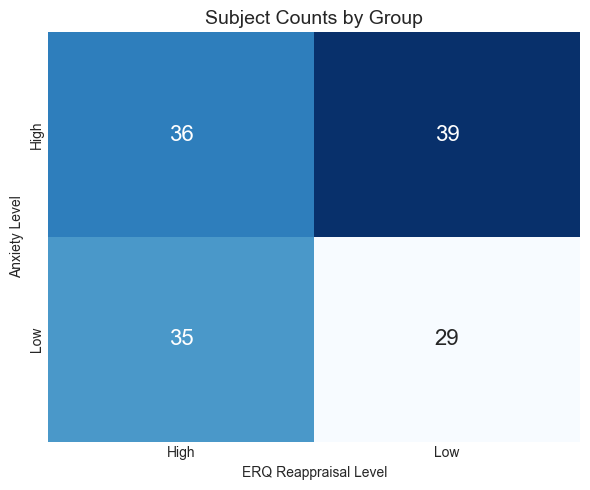

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

print("="*80)
print("GROUP OVERLAP ANALYSIS: ANXIETY vs. ERQ REAPPRAISAL")
print("="*80)

# 1. Prepare Data (Ensure one row per subject)
# We use the flexibility dataframe since it's already subject-level
subject_df = pd.read_csv('flexibility_analysis.csv')

# 2. Define Groups (Median Split)
med_anx = subject_df['anxiety'].median()
med_erq = subject_df['erq_reappraisal'].median()

subject_df['Anxiety_Group'] = subject_df['anxiety'].apply(lambda x: 'High' if x >= med_anx else 'Low')
subject_df['ERQ_Group'] = subject_df['erq_reappraisal'].apply(lambda x: 'High' if x >= med_erq else 'Low')

# 3. Create Crosstab (The Count)
crosstab = pd.crosstab(subject_df['Anxiety_Group'], subject_df['ERQ_Group'])

print("\nNumber of Subjects in Each Combination:")
print("-" * 40)
print(crosstab)

# 4. Statistical Check (Chi-Square)
# Tests if Anxiety and ERQ are independent (p > 0.05 means they are independent/good)
chi2, p, dof, expected = chi2_contingency(crosstab)

print(f"\nIndependence Test:")
print(f"Chi-square = {chi2:.2f}, p = {p:.4f}")
if p < 0.05:
    print("WARNING: The groups are NOT independent. (e.g., High Anxiety tends to be Low ERQ).")
else:
    print("SUCCESS: The groups are independent. You have a good mix of subjects.")

# 5. Visual Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 16})
plt.title('Subject Counts by Group', fontsize=14)
plt.ylabel('Anxiety Level')
plt.xlabel('ERQ Reappraisal Level')
plt.tight_layout()
plt.show()

EXTREME GROUP ANALYSIS: VULNERABLE vs. RESILIENT
Comparing: [High Anx + Low ERQ] vs. [Low Anx + High ERQ]

Sample Size Breakdown:
Profile
Vulnerable (High Anx/Low ERQ)    39
Resilient (Low Anx/High ERQ)     35
Name: count, dtype: int64

------------------------------------------------------------
STATISTICAL COMPARISONS (Independent t-tests)
------------------------------------------------------------

1. Safety Bias (P_Triangle - P_Feather):
   Vulnerable Mean: -0.08
   Resilient Mean:  -0.27
   t=1.779, p=0.0795

2. Processing Speed (Median RT):
   Vulnerable Mean: 3364 ms
   Resilient Mean:  2687 ms
   t=2.084, p=0.0407

3. Triangle Revaluation Magnitude (T3 - T1):
   Vulnerable Mean: 9.74
   Resilient Mean:  3.71
   t=1.747, p=0.0849

Saved plot: extreme_groups_analysis.png


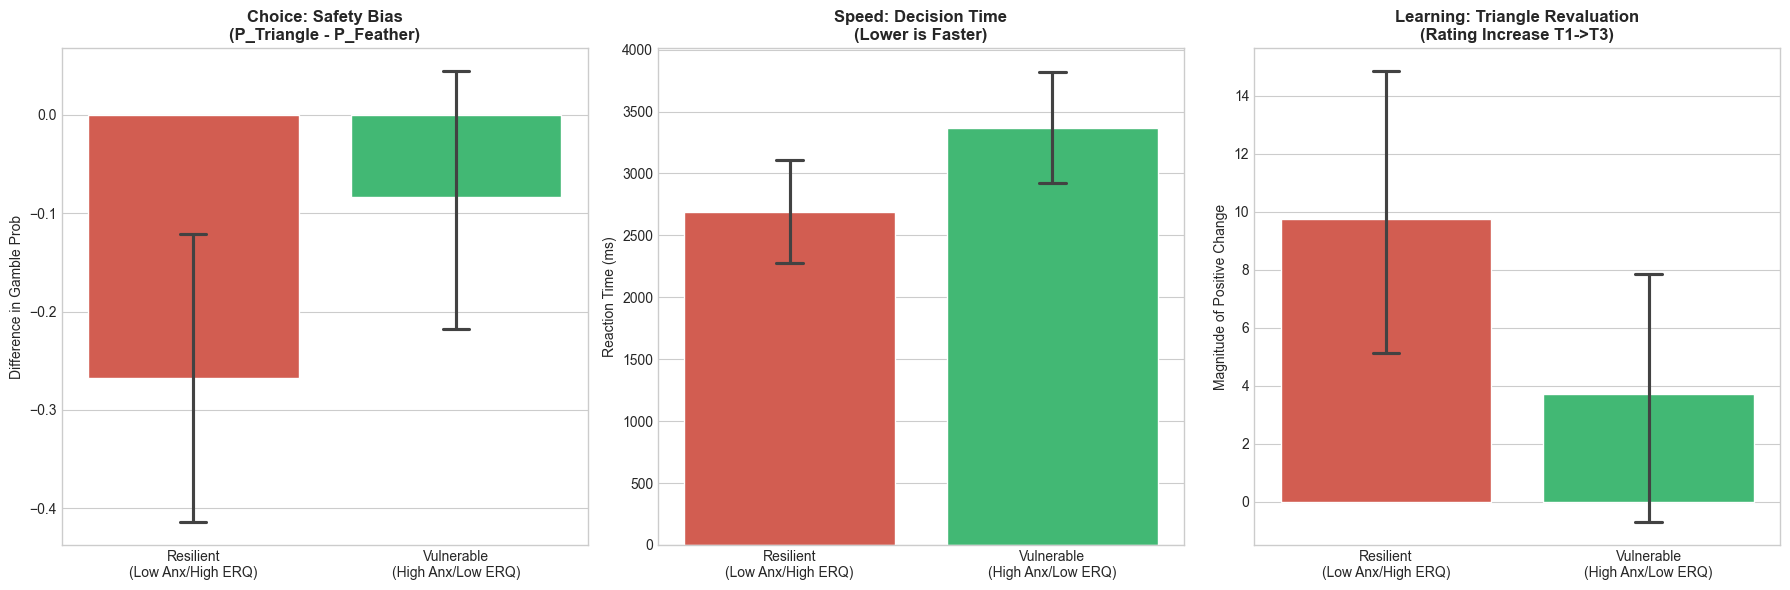

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set Plot Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("EXTREME GROUP ANALYSIS: VULNERABLE vs. RESILIENT")
print("Comparing: [High Anx + Low ERQ] vs. [Low Anx + High ERQ]")
print("="*80)

# 1. LOAD DATA
# ----------------------------------------------------------------------------
df = pd.read_csv('filtered_data.csv')
rating_df = pd.read_csv('rating_trajectories_long.csv')
flex_df = pd.read_csv('flexibility_analysis.csv') # Needed for subject-level scores

# 2. DEFINE GROUPS
# ----------------------------------------------------------------------------
# Calculate Medians
med_anx = flex_df['anxiety'].median()
med_erq = flex_df['erq_reappraisal'].median()

def classify_subject(row):
    anx_high = row['anxiety'] >= med_anx
    erq_high = row['erq_reappraisal'] >= med_erq
    
    if anx_high and not erq_high:
        return 'Vulnerable (High Anx/Low ERQ)'
    elif not anx_high and erq_high:
        return 'Resilient (Low Anx/High ERQ)'
    else:
        return 'Other' # Mixed groups (High/High or Low/Low)

flex_df['Profile'] = flex_df.apply(classify_subject, axis=1)

# Filter for only the two target groups
target_subs = flex_df[flex_df['Profile'] != 'Other']
print(f"\nSample Size Breakdown:")
print(target_subs['Profile'].value_counts())

# Create Mapping
profile_map = dict(zip(target_subs['subject_id'], target_subs['Profile']))

# Filter Main Dataframes
df_target = df[df['subject_id'].isin(target_subs['subject_id'])].copy()
df_target['Profile'] = df_target['subject_id'].map(profile_map)

rating_target = rating_df[rating_df['subject_id'].isin(target_subs['subject_id'])].copy()
rating_target['Profile'] = rating_target['subject_id'].map(profile_map)

# 3. RUN ANALYSES
# ----------------------------------------------------------------------------

# --- A. CHOICE BEHAVIOR (Triangle vs Feather) ---
# Calculate P(Gamble) for Triangle and Feather
choice_stats = []
for subj in target_subs['subject_id']:
    grp = profile_map[subj]
    # Get all trials
    subj_data = df_target[df_target['subject_id'] == subj]
    
    # Feather P(Gamble)
    f_trials = subj_data[subj_data.filter(like='State').eq('Feather').any(axis=1)]
    # Note: This crude filter needs refinement for the specific column structure
    # Better to iterate:
    p_feather = []
    p_triangle = []
    
    for q in [1, 2]:
        for t in range(1, 9):
            st = subj_data[f'Query_{q}_T{t}_State'].values[0]
            ch = subj_data[f'Query_{q}_T{t}_Choice'].values[0]
            if st == 'Feather' and pd.notna(ch): p_feather.append(ch)
            if st == 'Triangle' and pd.notna(ch): p_triangle.append(ch)
            
    if p_feather and p_triangle:
        choice_stats.append({
            'subject_id': subj,
            'Profile': grp,
            'P_Feather': np.mean(p_feather),
            'P_Triangle': np.mean(p_triangle),
            'Safety_Bias': np.mean(p_triangle) - np.mean(p_feather)
        })

choice_df = pd.DataFrame(choice_stats)

# --- B. REACTION TIME (Speed) ---
rt_stats = []
for subj in target_subs['subject_id']:
    grp = profile_map[subj]
    subj_data = df_target[df_target['subject_id'] == subj]
    
    rts = []
    for q in [1, 2]:
        for t in range(1, 9):
            rt = subj_data[f'Query_{q}_T{t}_RT'].values[0]
            if pd.notna(rt) and rt > 0: rts.append(rt)
    
    if rts:
        rt_stats.append({
            'subject_id': subj,
            'Profile': grp,
            'Mean_RT': np.median(rts) # Median per subject
        })

rt_df = pd.DataFrame(rt_stats)

# --- C. RATING REVALUATION (Triangle Rise) ---
# Pivot rating data
r_wide = rating_target.pivot_table(index=['subject_id', 'Profile', 'state'], 
                                   columns='time_point', values='rating').reset_index()
r_wide.rename(columns={1:'T1', 3:'T3'}, inplace=True)
r_wide['Total_Change'] = r_wide['T3'] - r_wide['T1']

# Filter for Triangle only (Safety Learning)
triangle_change = r_wide[r_wide['state'] == 'Triangle']

# 4. STATISTICAL TESTS
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("STATISTICAL COMPARISONS (Independent t-tests)")
print("-" * 60)

# Test 1: Safety Bias (Choice)
vuln_bias = choice_df[choice_df['Profile'].str.contains('Vulnerable')]['Safety_Bias']
res_bias = choice_df[choice_df['Profile'].str.contains('Resilient')]['Safety_Bias']
t1, p1 = stats.ttest_ind(vuln_bias, res_bias)
print(f"\n1. Safety Bias (P_Triangle - P_Feather):")
print(f"   Vulnerable Mean: {vuln_bias.mean():.2f}")
print(f"   Resilient Mean:  {res_bias.mean():.2f}")
print(f"   t={t1:.3f}, p={p1:.4f}")

# Test 2: Processing Speed (RT)
vuln_rt = rt_df[rt_df['Profile'].str.contains('Vulnerable')]['Mean_RT']
res_rt = rt_df[rt_df['Profile'].str.contains('Resilient')]['Mean_RT']
t2, p2 = stats.ttest_ind(vuln_rt, res_rt)
print(f"\n2. Processing Speed (Median RT):")
print(f"   Vulnerable Mean: {vuln_rt.mean():.0f} ms")
print(f"   Resilient Mean:  {res_rt.mean():.0f} ms")
print(f"   t={t2:.3f}, p={p2:.4f}")

# Test 3: Triangle Revaluation (Ratings)
vuln_rev = triangle_change[triangle_change['Profile'].str.contains('Vulnerable')]['Total_Change']
res_rev = triangle_change[triangle_change['Profile'].str.contains('Resilient')]['Total_Change']
t3, p3 = stats.ttest_ind(vuln_rev, res_rev)
print(f"\n3. Triangle Revaluation Magnitude (T3 - T1):")
print(f"   Vulnerable Mean: {vuln_rev.mean():.2f}")
print(f"   Resilient Mean:  {res_rev.mean():.2f}")
print(f"   t={t3:.3f}, p={p3:.4f}")

# 5. VISUALIZATION
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = ['#E74C3C', '#2ECC71'] # Red for Vulnerable, Green for Resilient

# Plot 1: Safety Bias
sns.barplot(data=choice_df, x='Profile', y='Safety_Bias', ax=axes[0], palette=palette, capsize=0.1)
axes[0].set_title('Choice: Safety Bias\n(P_Triangle - P_Feather)', fontweight='bold')
axes[0].set_ylabel('Difference in Gamble Prob')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Resilient\n(Low Anx/High ERQ)', 'Vulnerable\n(High Anx/Low ERQ)'])

# Plot 2: RT
sns.barplot(data=rt_df, x='Profile', y='Mean_RT', ax=axes[1], palette=palette, capsize=0.1)
axes[1].set_title('Speed: Decision Time\n(Lower is Faster)', fontweight='bold')
axes[1].set_ylabel('Reaction Time (ms)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Resilient\n(Low Anx/High ERQ)', 'Vulnerable\n(High Anx/Low ERQ)'])

# Plot 3: Triangle Revaluation
sns.barplot(data=triangle_change, x='Profile', y='Total_Change', ax=axes[2], palette=palette, capsize=0.1)
axes[2].set_title('Learning: Triangle Revaluation\n(Rating Increase T1->T3)', fontweight='bold')
axes[2].set_ylabel('Magnitude of Positive Change')
axes[2].set_xlabel('')
axes[2].set_xticklabels(['Resilient\n(Low Anx/High ERQ)', 'Vulnerable\n(High Anx/Low ERQ)'])

plt.tight_layout()
plt.savefig('extreme_groups_analysis.png')
print("\nSaved plot: extreme_groups_analysis.png")
plt.show()

FOCUSED ANALYSIS: ERQ REAPPRAISAL vs. Q2 FEATHER PERFORMANCE
Target: Does Reappraisal help/hurt accuracy on the 'Neutral' Feather?

1. CORRELATION: ERQ Reappraisal vs. Q2 Feather Accuracy
   r = -0.138, p = 0.1046
   -> No significant linear relationship.

2. RT-ACCURACY RELATIONSHIP (Strategy Check)
   Low ERQ: r = -0.230, p = 0.0594
     -> No speed-accuracy trade-off found.
   High ERQ: r = -0.190, p = 0.1132
     -> No speed-accuracy trade-off found.

3. GROUP COMPARISON: Q2 Feather Accuracy
   High ERQ Mean: 84.86%
   Low ERQ Mean:  84.93%
   t = -0.021, p = 0.9832


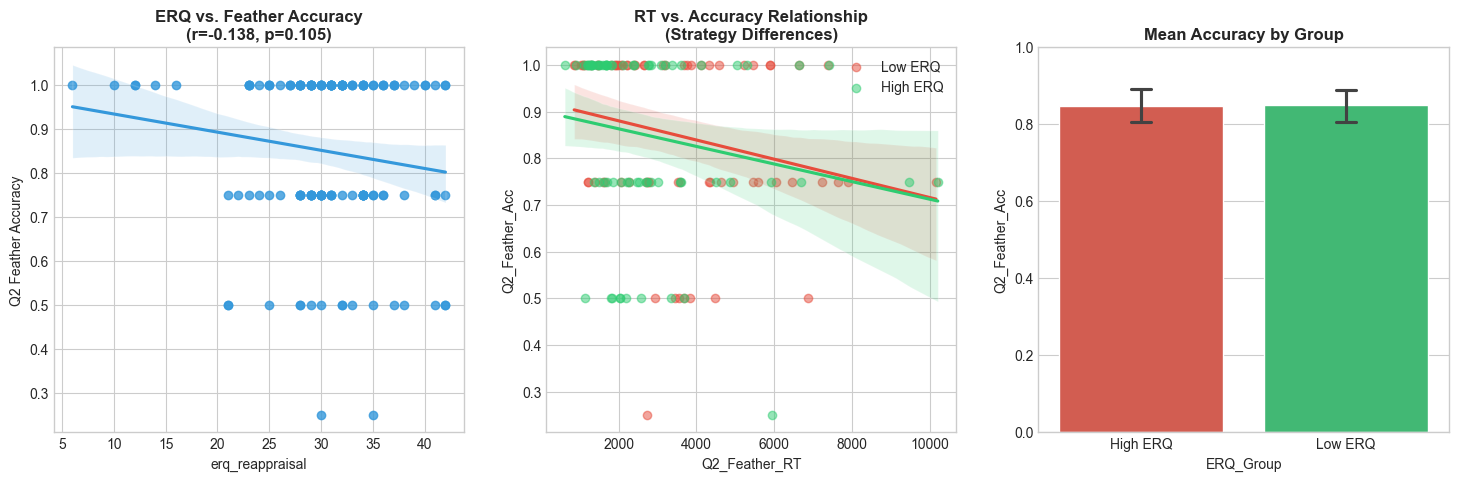

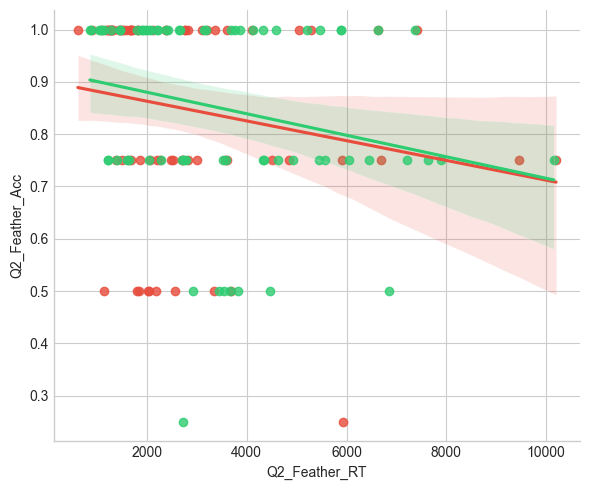

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set Plot Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("FOCUSED ANALYSIS: ERQ REAPPRAISAL vs. Q2 FEATHER PERFORMANCE")
print("Target: Does Reappraisal help/hurt accuracy on the 'Neutral' Feather?")
print("="*80)

# 1. LOAD DATA & PREP
# ----------------------------------------------------------------------------
df = pd.read_csv('filtered_data.csv')
flex_df = pd.read_csv('flexibility_analysis.csv') 

# Define EV for Query 2 Feather (Fixed Offer vs Feather=0)
# Feather EV is 0. Fixed Offer varies.
# Correct Choice: 
#   If Offer > 0 -> Choose Fixed (0).
#   If Offer < 0 -> Choose Gamble (1). (Though offers are usually > 0 in Q2?)
#   Let's use the explicit logic: Feather EV = 0.

q2_feather_data = []

for subj_id in df['subject_id'].unique():
    subj_data = df[df['subject_id'] == subj_id]
    
    correct = 0
    total = 0
    rts = []
    
    for t in range(1, 9):
        # Specific Columns for Q2 Feather
        state = subj_data.iloc[0].get(f'Query_2_T{t}_State')
        offer = subj_data.iloc[0].get(f'Query_2_T{t}_FixedOffer')
        choice = subj_data.iloc[0].get(f'Query_2_T{t}_Choice')
        rt = subj_data.iloc[0].get(f'Query_2_T{t}_RT')
        
        if state == 'Feather' and pd.notna(offer) and pd.notna(choice):
            # Feather EV = 0
            # If Offer > 0, Correct = Safe (0)
            # If Offer < 0, Correct = Gamble (1)
            # If Offer == 0, Indifferent
            
            is_correct = False
            scorable = False
            
            if offer > 0:
                scorable = True
                if choice == 0: is_correct = True
            elif offer < 0:
                scorable = True
                if choice == 1: is_correct = True
                
            if scorable:
                total += 1
                if is_correct: correct += 1
                if pd.notna(rt) and rt > 0: rts.append(rt)

    acc = correct / total if total > 0 else np.nan
    mean_rt = np.median(rts) if rts else np.nan
    
    q2_feather_data.append({
        'subject_id': subj_id,
        'Q2_Feather_Acc': acc,
        'Q2_Feather_RT': mean_rt
    })

# Merge with ERQ scores
q2_df = pd.DataFrame(q2_feather_data)
scores = flex_df[['subject_id', 'erq_reappraisal']]
df_final = q2_df.merge(scores, on='subject_id').dropna()

# Define Groups
med_erq = df_final['erq_reappraisal'].median()
df_final['ERQ_Group'] = df_final['erq_reappraisal'].apply(lambda x: 'High ERQ' if x >= med_erq else 'Low ERQ')

# 2. RUN STATISTICAL TESTS
# ----------------------------------------------------------------------------

# A. Overall Correlation: ERQ vs Accuracy
r, p = stats.pearsonr(df_final['erq_reappraisal'], df_final['Q2_Feather_Acc'])
print(f"\n1. CORRELATION: ERQ Reappraisal vs. Q2 Feather Accuracy")
print(f"   r = {r:.3f}, p = {p:.4f}")
if p < 0.05:
    dir_ = "BETTER" if r > 0 else "WORSE"
    print(f"   -> SIGNIFICANT: High ERQ is associated with {dir_} accuracy.")
else:
    print("   -> No significant linear relationship.")

# B. RT-Accuracy Relationship (Within Groups)
print(f"\n2. RT-ACCURACY RELATIONSHIP (Strategy Check)")
groups = ['Low ERQ', 'High ERQ']
corrs = {}

for grp in groups:
    subset = df_final[df_final['ERQ_Group'] == grp]
    if len(subset) > 2:
        r_sub, p_sub = stats.pearsonr(subset['Q2_Feather_RT'], subset['Q2_Feather_Acc'])
        corrs[grp] = (r_sub, p_sub)
        print(f"   {grp}: r = {r_sub:.3f}, p = {p_sub:.4f}")
        # Interpretation
        if r_sub < 0 and p_sub < 0.05:
            print(f"     -> Faster RTs linked to Better Accuracy (Efficiency)")
        elif r_sub > 0 and p_sub < 0.05:
            print(f"     -> Slower RTs linked to Better Accuracy (Deliberation)")
        else:
            print(f"     -> No speed-accuracy trade-off found.")

# C. Group Comparison: High vs Low ERQ on Accuracy
high_acc = df_final[df_final['ERQ_Group'] == 'High ERQ']['Q2_Feather_Acc']
low_acc = df_final[df_final['ERQ_Group'] == 'Low ERQ']['Q2_Feather_Acc']
t_val, p_val = stats.ttest_ind(high_acc, low_acc)

print(f"\n3. GROUP COMPARISON: Q2 Feather Accuracy")
print(f"   High ERQ Mean: {high_acc.mean():.2%}")
print(f"   Low ERQ Mean:  {low_acc.mean():.2%}")
print(f"   t = {t_val:.3f}, p = {p_val:.4f}")

# 3. VISUALIZATION
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Overall Correlation
sns.regplot(data=df_final, x='erq_reappraisal', y='Q2_Feather_Acc', ax=axes[0], color='#3498DB')
axes[0].set_title(f"ERQ vs. Feather Accuracy\n(r={r:.3f}, p={p:.3f})", fontweight='bold')
axes[0].set_ylabel("Q2 Feather Accuracy")

# Plot 2: RT-Accuracy by Group
sns.lmplot(data=df_final, x='Q2_Feather_RT', y='Q2_Feather_Acc', hue='ERQ_Group', 
           palette=['#E74C3C', '#2ECC71'], height=5, aspect=1.2, legend=False)
# Note: lmplot creates its own figure, so we can't easily put it in subplot 2 without tricks.
# Instead, let's use scatterplot + manual lines on the existing axes[1]
for grp, color in zip(groups, ['#E74C3C', '#2ECC71']):
    subset = df_final[df_final['ERQ_Group'] == grp]
    sns.regplot(data=subset, x='Q2_Feather_RT', y='Q2_Feather_Acc', ax=axes[1], 
                color=color, label=grp, scatter_kws={'alpha':0.5})
axes[1].legend()
axes[1].set_title("RT vs. Accuracy Relationship\n(Strategy Differences)", fontweight='bold')

# Plot 3: Group Comparison
sns.barplot(data=df_final, x='ERQ_Group', y='Q2_Feather_Acc', ax=axes[2], 
            palette=['#E74C3C', '#2ECC71'], capsize=0.1)
axes[2].set_title("Mean Accuracy by Group", fontweight='bold')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

CORRELATION ANALYSIS: EMOTION REGULATION vs. ANXIETY

ERQ Reappraisal vs. Anxiety:
   Pearson r = -0.168
   p-value   = 0.0477
   -> SIGNIFICANT relationship.

ERQ Suppression vs. Anxiety:
   Pearson r = -0.026
   p-value   = 0.7606
   -> No significant relationship.

Saved plot: erq_anxiety_correlations.png


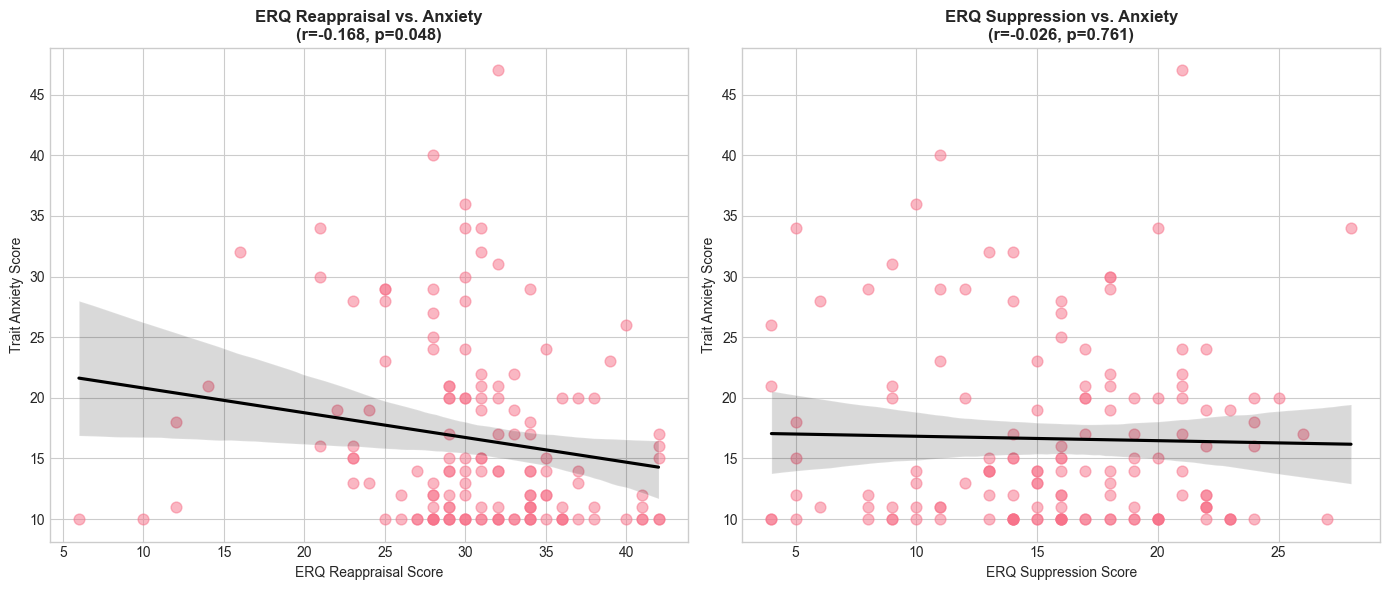

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Set plot style
sns.set_style("whitegrid")

# 1. Load Data
df = pd.read_csv('flexibility_analysis.csv')

print("="*80)
print("CORRELATION ANALYSIS: EMOTION REGULATION vs. ANXIETY")
print("="*80)

# Define the pairs to analyze
correlations = [
    ('erq_reappraisal', 'anxiety', 'ERQ Reappraisal'),
    ('erq_suppression', 'anxiety', 'ERQ Suppression')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (x_col, y_col, label) in enumerate(correlations):
    # Calculate Stats
    r, p = stats.pearsonr(df[x_col], df[y_col])
    
    # Print Results
    print(f"\n{label} vs. Anxiety:")
    print(f"   Pearson r = {r:.3f}")
    print(f"   p-value   = {p:.4f}")
    if p < 0.05:
        print(f"   -> SIGNIFICANT relationship.")
    else:
        print(f"   -> No significant relationship.")

    # Visualize
    sns.regplot(data=df, x=x_col, y=y_col, ax=axes[i],
                scatter_kws={'alpha':0.5, 's':60}, 
                line_kws={'color':'black'})
    
    axes[i].set_title(f'{label} vs. Anxiety\n(r={r:.3f}, p={p:.3f})', fontweight='bold')
    axes[i].set_xlabel(f'{label} Score')
    axes[i].set_ylabel('Trait Anxiety Score')

plt.tight_layout()
plt.savefig('erq_anxiety_correlations.png')
print("\nSaved plot: erq_anxiety_correlations.png")
plt.show()

In [1]:
import pandas as pd
import numpy as np

def calculate_cronbach_alpha(df, prefix):
    """Calculates Cronbach's Alpha for columns starting with a prefix."""
    # Find columns
    cols = [c for c in df.columns if c.startswith(prefix)]
    
    if len(cols) < 2:
        return np.nan, 0
    
    # Select data and ensure numeric
    item_data = df[cols].apply(pd.to_numeric, errors='coerce').dropna()
    
    # Calculate variances
    item_variances = item_data.var(axis=0, ddof=1)
    total_variance = item_data.sum(axis=1).var(ddof=1)
    n_items = len(cols)
    
    # Cronbach's Alpha Formula
    alpha = (n_items / (n_items - 1)) * (1 - (item_variances.sum() / total_variance))
    return alpha, n_items

# 1. Load Data
try:
    df = pd.read_csv('experiment_results_v3_export.csv')
    print("Data loaded successfully.\n")
except FileNotFoundError:
    print("Error: 'experiment_results_v3_export.csv' not found. Please check file path.")
    df = pd.DataFrame() # Empty DF to prevent further errors

if not df.empty:
    print(f"{'Questionnaire':<30} | {'Items':<5} | {'Cronbach\'s Alpha':<15}")
    print("-" * 60)

    # 2. Define Questionnaires
    # We define the likely prefixes based on standard formats
    scales = {
        'Anxiety (Total)': 'Survey_ANXIETY', # Likely GAD-7 or STAI
        'ERQ (Total)': 'Survey_ERQ',
        'Worry (PSWQ?)': 'Survey_PSWQ',      # Penn State Worry Questionnaire
        'Depression (PHQ?)': 'Survey_PHQ'    # Patient Health Questionnaire (if present)
    }
    
    # 3. Calculate Scale Alphas
    for name, prefix in scales.items():
        alpha, n = calculate_cronbach_alpha(df, prefix)
        if n > 0:
            print(f"{name:<30} | {n:<5} | {alpha:.3f}")
            
    # 4. Calculate ERQ Subscales Specifically (Standard Items)
    # Reappraisal: Items 1, 3, 5, 7, 8, 10
    # Suppression: Items 2, 4, 6, 9
    erq_cols = [c for c in df.columns if 'Survey_ERQ' in c]
    
    if len(erq_cols) >= 10:
        # Sort to ensure order (ERQ_1, ERQ_10, etc.)
        # Note: 'ERQ_1' vs 'ERQ_10' sorting might need care, usually direct mapping is safer
        # Let's try to map indices if the columns are well-named like 'Survey_ERQ_1'
        
        reapp_indices = [1, 3, 5, 7, 8, 10]
        supp_indices = [2, 4, 6, 9]
        
        reapp_cols = [c for c in erq_cols if any(str(i) in c.split('_')[-1] for i in reapp_indices)]
        supp_cols = [c for c in erq_cols if any(str(i) in c.split('_')[-1] for i in supp_indices)]

        # Calculate Reappraisal Alpha
        reapp_items = df[reapp_cols].apply(pd.to_numeric, errors='coerce').dropna()
        if not reapp_items.empty:
            k = len(reapp_cols)
            var_sum = reapp_items.var(axis=0, ddof=1).sum()
            total_var = reapp_items.sum(axis=1).var(ddof=1)
            alpha_reapp = (k / (k-1)) * (1 - (var_sum / total_var))
            print(f"{'ERQ Reappraisal':<30} | {k:<5} | {alpha_reapp:.3f}")

        # Calculate Suppression Alpha
        supp_items = df[supp_cols].apply(pd.to_numeric, errors='coerce').dropna()
        if not supp_items.empty:
            k = len(supp_cols)
            var_sum = supp_items.var(axis=0, ddof=1).sum()
            total_var = supp_items.sum(axis=1).var(ddof=1)
            alpha_supp = (k / (k-1)) * (1 - (var_sum / total_var))
            print(f"{'ERQ Suppression':<30} | {k:<5} | {alpha_supp:.3f}")

print("-" * 60)
print("Interpretation Guide:")
print(" > 0.9: Excellent")
print(" > 0.8: Good")
print(" > 0.7: Acceptable")
print(" < 0.6: Questionable/Poor")

Data loaded successfully.

Questionnaire                  | Items | Cronbach's Alpha
------------------------------------------------------------
Anxiety (Total)                | 20    | 0.840
ERQ (Total)                    | 11    | 0.737
------------------------------------------------------------
Interpretation Guide:
 > 0.9: Excellent
 > 0.8: Good
 > 0.7: Acceptable
 < 0.6: Questionable/Poor
